In [354]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.ticker as mticker
!pip install scikit-learn --break-system-packages


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Analysis Part 1

In [355]:
df = pd.read_csv("data/Dataset 1 UVA .csv", sep=";")

In [356]:
df.head()


,id,geslacht,geboortedatum,postcode,woonplaats,mailings,opens,clicks,interesses
0,5cb9a38136dd1336b9c528d1,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"energie,loterij,kranten,entertainment,winactie..."
1,5cb9a38336dd1336b9c537f3,v,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"auto,loterij,cx80,kranten,mkb,verzekering,ente..."
2,5cb9a38236dd1336b9c52f07,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"auto,kranten,Auto inruilen,Windows,bladen,goed..."
3,5cb9a38236dd1336b9c53694,v,0-0-0,NaN,NaN,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"cx60,auto,loterij,cx80,kranten,mkb,verzekering..."
4,5cb9a38636dd1336b9c54e48,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"auto,kranten,verzekering,winactie,Auto inruile..."


In [357]:
df['geboortedatum'] = df['geboortedatum'].replace(
    ['0', '0-0-0', '0000-00-00'],
    pd.NA
)

In [358]:
df['geboortedatum'].isna().mean() * 100

np.float64(39.96)

In [359]:
df.head()

,id,geslacht,geboortedatum,postcode,woonplaats,mailings,opens,clicks,interesses
0,5cb9a38136dd1336b9c528d1,m,NaN,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"energie,loterij,kranten,entertainment,winactie..."
1,5cb9a38336dd1336b9c537f3,v,NaN,NaN,NaN,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"auto,loterij,cx80,kranten,mkb,verzekering,ente..."
2,5cb9a38236dd1336b9c52f07,m,NaN,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"auto,kranten,Auto inruilen,Windows,bladen,goed..."
3,5cb9a38236dd1336b9c53694,v,NaN,NaN,NaN,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"cx60,auto,loterij,cx80,kranten,mkb,verzekering..."
4,5cb9a38636dd1336b9c54e48,m,NaN,NaN,NaN,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"auto,kranten,verzekering,winactie,Auto inruile..."


In [360]:
df = df.rename(columns={
    'geslacht': 'gender',
    'geboortedatum': 'birth_date',
    'postcode': 'postcode',
    'woonplaats': 'city',
    'interesses': 'interests'
})

Gender analysis

In [361]:
df['gender'].value_counts(dropna=False)

gender
v          11018
m           8493
o            409
Mevrouw       57
De Heer       23
Name: count, dtype: int64

In [362]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'v': 'female',
    'mevrouw': 'female',
    'm': 'male',
    'de heer': 'male',
    'o': 'other'
})

In [363]:
df['gender'].value_counts(dropna=False)

gender
female    11075
male       8516
other       409
Name: count, dtype: int64

In [364]:
df['gender'].value_counts(normalize=True)

gender
female    0.55375
male      0.42580
other     0.02045
Name: proportion, dtype: float64

In [365]:
from datetime import datetime

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
today = pd.to_datetime('today')

df['age'] = (today - df['birth_date']).dt.days // 365

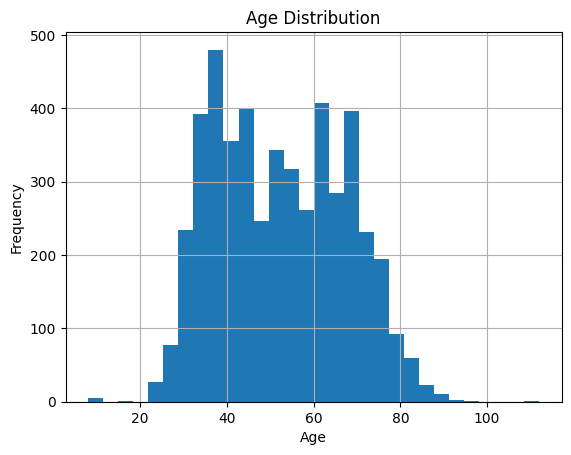

In [366]:
import matplotlib.pyplot as plt

df['age'].dropna().hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [367]:
df_interests = df.copy()

df_interests['interests'] = df_interests['interests'].str.split(',')
df_interests = df_interests.explode('interests')

In [368]:
df_interests['interests'] = (
    df_interests['interests']
    .str.strip()
    .str.lower()
)

Unique interests

In [369]:
df_interests['interests'].nunique()

60

In [370]:
df_interests['interests'].unique()

<StringArray>
[         'energie',          'loterij',          'kranten',
    'entertainment',         'winactie',           'cadeau',
           'bladen',       'kansspelen',      'goededoelen',
           'acties',          'unknown',        'kortingen',
        'onderzoek',             'auto',             'cx80',
              'mkb',      'verzekering',    'auto inruilen',
            'mazda',       'elektrisch',  'zakelijk rijden',
             'audi',          'mazda6e',      'ondernemers',
            'dacia',         'bigevent',           'hybrid',
         'mercedes',           'toyota',            'lease',
          'windows',             'bank',         'beleggen',
          'finance',             'cx60',               'hr',
              'cx5',        'bedrijven',               'it',
           'telcom',        'hypotheek',  'centraal beheer',
             'mx30',             'cx30',              'ios',
          'android',          'hyundai',            'linux',
          

In [371]:
df_interests['interests'].value_counts()

interests
bladen              19382
acties              18990
kranten             18536
winactie            17859
cadeau              17491
kortingen           17436
energie             16884
goededoelen         15515
onderzoek           15224
auto                12766
mazda               12091
unknown             12074
lease               12066
zakelijk rijden     12012
elektrisch          11821
auto inruilen       10336
kansspelen          10224
toyota               9783
audi                 9715
dacia                8440
bigevent             8440
entertainment        8375
finance              8102
bank                 7626
beleggen             7519
verzekering          6966
cx60                 6876
loterij              6827
mkb                  6698
ondernemers          6008
cx80                 5558
hybrid               4867
mazda6e              4601
cx30                 3138
mercedes             2868
bedrijven            2644
cx5                  2609
mx30                 2609
wi

In [372]:
df['postcode'] = (
    df['postcode']
    .astype(str)
    .str.upper()
    .str.replace(' ', '', regex=False)
    .str.extract(r'(\d{4}[A-Z]{0,2})')
)

In [373]:
df['postcode'].sample(50)

9417     3281KW
4780       1091
15900    4142XG
11948    2512EH
5709     6441ST
8739     7576EC
9536     5045JN
8880     5056PK
4951       6461
2464        NaN
8003     6431MH
11582    3355AB
7099     2586VP
13191    7983LE
9371     7679XA
17812       NaN
7584     2121WB
5279       1012
15904    3083KD
11008    3841KA
1423        NaN
8127     6844DP
11084    3961ER
13109    2645JB
17618       NaN
4038        NaN
12078    3607HS
2155        NaN
13631    7523VE
17760       NaN
7664     2636DB
6441       8430
2439        NaN
13160    6462GV
13954    5473SR
6955       8370
6942     1483CR
17174    8031XB
7432     1051HP
11540    1705HJ
16672    6414ED
19949    5021AH
12555    1852TV
16696       NaN
19963    7414ED
8891     3911EC
11212    7951HE
17127       NaN
12787      9400
1569        NaN
Name: postcode, dtype: str

In [374]:
df['city'] = (
    df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('null', pd.NA)
)

In [375]:
df['city'] = df['city'].replace('nan', pd.NA)

In [376]:
df['interests'] = df['interests'].str.split(',')

In [377]:
type(df['interests'].iloc[0])

list

In [378]:
df['interests'] = df['interests'].apply(
    lambda x: [i.strip().lower() for i in x] if isinstance(x, list) else []
)

In [379]:
df['n_interests'] = df['interests'].apply(len)

In [380]:
df.head()

,id,gender,birth_date,postcode,city,mailings,opens,clicks,interests,age,n_interests
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13
1,5cb9a38336dd1336b9c537f3,female,NaT,NaN,NaN,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"[auto, loterij, cx80, kranten, mkb, verzekerin...",NaN,30
2,5cb9a38236dd1336b9c52f07,male,NaT,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"[auto, kranten, auto inruilen, windows, bladen...",NaN,13
3,5cb9a38236dd1336b9c53694,female,NaT,NaN,NaN,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"[cx60, auto, loterij, cx80, kranten, mkb, verz...",NaN,35
4,5cb9a38636dd1336b9c54e48,male,NaT,NaN,NaN,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"[auto, kranten, verzekering, winactie, auto in...",NaN,25


# Campaign Analysis 

### Data prep

In [381]:
# inspect (in)valid values in opens and clicks
import re

def classify_value(x):
    if pd.isna(x) or str(x).strip() == '':
        return 'missing'
    
    x = str(x).strip()

    # valid id
    if re.search(r'\b1:\d{3,4}\b', x):
        return 'id_format'
    
    return 'non_id_format'

In [382]:
df['open_type'] = df['opens'].apply(classify_value)
df['click_type'] = df['clicks'].apply(classify_value)

print(df['open_type'].value_counts())
print(df['click_type'].value_counts())

open_type
id_format        17793
non_id_format     2037
missing            170
Name: count, dtype: int64
click_type
missing          19019
non_id_format      787
id_format          194
Name: count, dtype: int64


In [383]:
print(df['mailings'].iloc[0])

# function to extract id from mailings, opens, clicks
def extract_ids(text):
    if pd.isna(text):
        return []
    items = text.split(',')
    ids = []

    for item in items:
        item = item.strip()
        if ':' in item:
            ids.append(int(item.split(':')[1]))
    
    return ids

1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:825,1:846,1:859,1:866,1:873,1:876,1:879,1:892,1:891,1:899,1:874,1:920,1:906,1:913,1:930,1:935,1:958,1:996,1:1031,1:1007,1:1013,1:1040,1:1057,1:1084,1:1093,1:1122,1:1146,1:1159,1:1177,1:1178,1:1231,1:1237,1:1245,1:1281,1:1297,1:1314,1:1340,1:1346,1:1334,1:1362,1:1382,1:1390,1:1398,1:1417


In [384]:
# parse mailings, open, clicks
df['mailing_ids'] = df['mailings'].apply(extract_ids)
df['open_ids'] = df.apply(
    lambda row: extract_ids(row['opens']) if row['open_type'] == 'id_format' else [],
    axis = 1)
df['click_ids'] = df.apply(
    lambda row: extract_ids(row['clicks']) if row['click_type'] == 'id_format' else [],
    axis = 1)

In [385]:
df[['opens', 'open_type', 'open_ids', 'clicks', 'click_type', 'click_ids']].head(26)

,opens,open_type,open_ids,clicks,click_type,click_ids
0,"1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",id_format,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",NaN,missing,[]
1,"1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",id_format,"[668, 692, 714, 733, 753, 777, 770, 758, 760, ...",NaN,missing,[]
2,"1:876,1:961,1:1159",id_format,"[876, 961, 1159]",NaN,missing,[]
3,"1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",id_format,"[654, 706, 733, 831, 866, 876, 891, 913, 961, ...",NaN,missing,[]
4,"1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",id_format,"[668, 692, 714, 760, 785, 804, 825, 846, 873, ...",NaN,missing,[]
5,"1:876,1:882,1:892,1:874,1:920,1:906,1:961,1:97...",id_format,"[876, 882, 892, 874, 920, 906, 961, 970, 1003,...",NaN,missing,[]
6,"1:714,1:733,1:777,1:770,1:758,1:785,1:803,1:85...",id_format,"[714, 733, 777, 770, 758, 785, 803, 859, 876, ...",NaN,missing,[]
7,"1:876,1:879,1:892,1:891,1:874,1:920,1:906,1:91...",id_format,"[876, 879, 892, 891, 874, 920, 906, 913, 932, ...",NaN,missing,[]
8,"1:668,1:692,1:714,1:760,1:785,1:824,1:846,1:85...",id_format,"[668, 692, 714, 760, 785, 824, 846, 859, 866, ...",NaN,missing,[]
9,"1:761,1:913,1:1381,1:1391",id_format,"[761, 913, 1381, 1391]",NaN,missing,[]


In [386]:
# rename column id
df = df.rename(columns = {'id': 'user_id'})

In [387]:
# explode dataset
df_exploded = df.explode('mailing_ids')
df_exploded = df_exploded.rename(columns = {'mailing_ids': 'mailing_id'})

df_exploded[['user_id', 'mailing_id']].head()

,user_id,mailing_id
0,5cb9a38136dd1336b9c528d1,668
0,5cb9a38136dd1336b9c528d1,692
0,5cb9a38136dd1336b9c528d1,714
0,5cb9a38136dd1336b9c528d1,733
0,5cb9a38136dd1336b9c528d1,761


In [388]:
import numpy as np

In [389]:
# create three state open column: 1 if mailing_id was opened, 0 if not opened, NaN if invalid
def check_open(row):
    if row['open_type'] == 'missing':
        return 0
    
    if row['open_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['open_ids']:
        return 1
    else:
        return 0
    
df_exploded['open'] = df_exploded.apply(check_open, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'open_ids']].head()

,user_id,mailing_id,open,open_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,692,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,714,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,733,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,761,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."


In [390]:
# create three state click column
def check_click(row):
    if row['click_type'] == 'missing':
        return 0
    
    if row['click_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['click_ids']:
        return 1
    else:
        return 0
    
df_exploded['click'] = df_exploded.apply(check_click, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'click', 'open_ids', 'click_ids']].head()

,user_id,mailing_id,open,click,open_ids,click_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]


In [391]:
df_exploded[['user_id', 'mailing_id', 'open', 'click']].head()

,user_id,mailing_id,open,click
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0


In [392]:
print(df_exploded['open'].value_counts(dropna = False))
print(df_exploded['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [393]:
# load dataset 2
df2 = pd.read_excel('data/DATSET 2 UVA lijst mailings.xlsx')

In [394]:
# rename columns
df2 = df2.rename(columns = {
    'ID': 'mailing_id',
    'Mailing': 'mailing_info',
    'Subjectline': 'subject_line',
    'Preheader': 'preheader'
})

In [395]:
# merge dataset 1 and dataset 2
df_final = df_exploded.merge(
    df2,
    on = 'mailing_id',
    how = 'left'
)

In [715]:
print(df_final[['open', 'click']].isna().sum())
print(df_final[['open', 'click']].dtypes)

open     98760
click    52062
dtype: int64
open     float64
click    float64
dtype: object


In [396]:
df_final[['user_id', 'mailing_id', 'open', 'click', 'subject_line']].head()

,user_id,mailing_id,open,click,subject_line
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"Lezen, puzzelen, genieten: 4 edities cadeau"
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,4 weken jouw favoriete krant digitaal voor maa...
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Profiteer nu: €300 bonus én vaste energietarieven
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Jouw mening is geld waard – start vandaag nog
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Speel mee met de ENGIE woordlegger!


In [397]:
# drop unnecessary columns
df_final = df_final.drop(columns = [
    'mailings',
    'opens',
    'clicks',
    'open_ids',
    'click_ids'
])

In [398]:
print(df_final.columns)
df_final.head()

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='str')


,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen."
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v..."
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95."


### Overall engagement rates

In [399]:
# subjecline effectiveness (known cases only)
print('Open rate:', df_final['open'].mean())

# content effectiveness (known cases only)
print('Click rate:', df_final['click'].mean())

Open rate: 0.5361800549197008
Click rate: 0.001082190316977619


In [400]:
print('Open unknown %:', df_final['open'].isna().mean())
print('Click unknown %:', df_final['click'].isna().mean())

Open unknown %: 0.08541006517317246
Click unknown %: 0.045024491829138355


In [401]:
# subjectline

result = df_final.groupby(['subject_line', 'preheader']).agg(
    open_mean = ('open', 'mean'),
    click_mean = ('click', 'mean'),
    count_valid = ('open', 'count'),    #excludes NaN
    count_total = ('open', 'size')      #includes everything
)

# top subjectline being sent
result.sort_values('count_valid', ascending = False)[
    ['count_valid', 'count_total', 'open_mean', 'click_mean']
].head(10)

,,count_valid,count_total,open_mean,click_mean
subject_line,preheader,,,,
MAX Magazine én een HEMA verrassing voor jou!,Een jaar lang MAX Magazine én een HEMA giftcard t.w.v. €10.-.,32118,35396,0.496793,0.000383
Ontvang 4 nummers van MAX Magazine cadeau!,Maak kennis met het grootste lifestyle magazine van Nederland.,24601,26489,0.687655,0.000508
Krijg VROUW Glossy of Privé bij De Telegraaf,"Kies uw extraatje en lees De Telegraaf vanaf 5,19 euro per week.",19171,21351,0.644776,0.000778
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,18304,20372,0.000000,0.000000
Meer weten over de impact van Hulphond Nederland?,"Ontvang inspirerende verhalen én maak kans op een cadeaubon van €25,-.",17562,18729,0.638936,0.000337
Welke deal past bij jou deze week?,"Van 4 weken gratis lezen tot een proefabonnement voor 8,-.",17493,19360,0.513405,0.000753
Laatste kans: 4 weken jouw krant voor 1 euro p/w,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet.",17210,19195,0.476351,0.000163
Kies en lees: 4 weken de krant voor 1 euro p/w,Gratis toegang tot digitale artikelen inbegrepen.,16982,18808,0.517195,0.000387
Jouw huidige auto is meer waard dan je denkt,Ontdek het met het Mazda Taxatie Festival.,16534,16974,0.554857,0.003699


#### Top subject lines by open rate

In [402]:
# top subjectline by open rate
result.sort_values('open_mean', ascending = False)[
    ['open_mean', 'click_mean', 'count_valid', 'count_total']
].head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Past de Mazda6e bij jouw zakelijke stijl?,Boek een proefrit en ontdek het comfort van elektrisch rijden.,0.778993,0.004263,1828,1840
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352


#### Top subject lines by click rate

In [403]:
# top subjectline by click rate
result.sort_values('click_mean', ascending = False)[
    ['click_mean', 'open_mean', 'count_valid', 'count_total']
].head(10)

,,click_mean,open_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.136000,0.746479,213,290
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.040929,0.700815,859,1005
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.015927,0.787234,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.013603,0.530153,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.008900,0.716370,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.008871,0.715441,2474,2742
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.007692,0.291667,144,167


### Subject line vs Engagement segmentation

In [404]:
print(result['open_mean'].describe())
print(result['click_mean'].describe())

count    189.000000
mean       0.520890
std        0.181064
min        0.000000
25%        0.460076
50%        0.554857
75%        0.638344
max        0.833285
Name: open_mean, dtype: float64
count    189.000000
mean       0.002467
std        0.011163
min        0.000000
25%        0.000000
50%        0.000498
75%        0.001227
max        0.136000
Name: click_mean, dtype: float64


In [405]:
# threshold for engagement rates
open_threshold = result['open_mean'].mean()
click_threshold = result['click_mean'].mean()

In [406]:
# classify subject lines into groups

result['open_group'] = result['open_mean'].apply(
    lambda x: 'high' if x > open_threshold else 'low')

result['click_group'] = result['click_mean'].apply(
    lambda x: 'high' if x > click_threshold else 'low')

In [407]:
# size check
result.groupby(['open_group', 'click_group']).size()

open_group  click_group
high        high           21
            low            91
low         high            5
            low            72
dtype: int64

In [408]:
# extract groups
high_open_high_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'high')]

high_open_low_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'low')]

low_open_high_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'high')]

low_open_low_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'low')]


#### High open + High click group

In [409]:
high_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.746479,0.136000,213,290
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.700815,0.040929,859,1005
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.700815,0.040929,859,1005
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.700815,0.040929,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.530153,0.013603,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.716370,0.008900,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.715441,0.008871,2474,2742
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168


##### Insights
High open, high click group
- Subject lines and preheaders use broadly appealing and simple languages (discover, get to know)
- Explicit incentives (gift cards, financial benefits)
- Subject lines attracts attention
- Preheader communicate reward/next step
- Low effort, clear reward for audience
- Some high performing subject lines (top 10) are associated with smaller campaign sizes (may indicate more targeted audience)
- External factors beyond subject lines and preheaders may play a significant role

In [410]:
high_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352
Probeer nu MAX Magazine vrijblijvend,Vraag nu jou 4 proefnummers aan.,0.753238,0.000239,8494,8613
De volledig nieuwe Mazda CX-6e in het echt bewonderen?,Kom langs tijdens de preview en ervaar het design en comfort zelf.,0.751258,0.000578,3578,3581
Nespresso zonder kosten uitproberen?,Altijd moeiteloos kwaliteitskoffie op de werkvloer.,0.744581,0.000000,1061,1088


#### High open + Low click group

##### Insights
High open, low click group
- Subject lines and preheaders use strong hooks (financial benefits, high value products) (tax advantage, discounts, cars)
- Offers require higher commitment (large purchases, test drives) that not immediately relevant to all

In [411]:
low_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.291667,0.007692,144,167
Internationaal groeien in een onzekere wereld?,Plan een gratis adviesgesprek en ontdek de kansen & risico’s.,0.319277,0.006579,166,177
Pensioen regelen voor je werknemers: 10 dingen die je moet weten,Je kostbare personeel behouden en nieuw talent aantrekken in deze krappe arbeidsmarkt?,0.452951,0.003241,627,705
Neem meer dan 25 tijdschriften makkelijk mee op reis!,Probeer Mijn Magazines nu voor maar 1 euro per week.,0.472034,0.002616,1180,1282
Een wereld zonder lepra in 2040?,Ontdek hoe jij daaraan kunt bijdragen via onze nieuwsbrief.,0.012391,0.002567,12832,13933


#### Low open + High click group

##### Insights 
Low open, high click group
- Subject lines focus on specific, niche topics (security, finance)
- May not attract broad attention (low open rate)
- Generate stronger engagement among a small, relevant group of audience (high click rate)

In [412]:
low_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = True).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Deze goede doelen verdienen jouw aandacht,"Schrijf je in voor de nieuwsbrief en maak kans op €25,- bij Bol.com.",0.000000,0.0,431,453
Heb je deze deals al gezien?,Direct-Doen is terug met nieuwe aanbiedingen en extra’s.,0.000000,0.0,1907,2205
Laatste kans: 4 weken jouw krant voor 1 euro per week,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet!",0.000000,0.0,1229,1417
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,0.000000,0.0,18304,20372
Hoe reist jouw zorgpersoneel straks naar het werk?,Ontdek hoe NS Zakelijk mobiliteit in de zorg toekomstbestendig maakt.,0.033094,0.0,6678,7562
Succesvol zakendoen in het buitenland?,Plan een gratis adviesgesprek en ontdek wat RVO voor jou kan betekenen.,0.051643,0.0,213,282
Wil jij ook je bedrijf internationaal laten groeien?,"RVO helpt; met kennis, contacten & financieringen.",0.051643,0.0,213,282
"{$voornaam|default=Beste}, Mis het niet: het Empoyer Brandonderzoek 2025",Zo wordt je aantrekkelijke werkgevers binnen {{ contact.branche }}.,0.078512,0.0,242,311
Frequent verzuim op de werkvloer?,Meld je aan voor het webinar of start direct met praktische tools.,0.117647,0.0,51,65


#### Low open + Low click group

##### Insights
Low open, low click group
- Subjectlines and preheaders tend to be vague
- Not communicate a specific benefit, urgency or incentive
- Campaign size does not explain poor performance here

# User Engagement Analysis

Explore how user characteristics (gender, age, and interests) relate to engagement metrics

### Overview

#### Data preparation

In [413]:
# open and click rates per user
df_user = df_final.groupby('user_id').agg(
    open_rate = ('open', 'mean'),
    click_rate = ('click', 'mean'),
    total_emails = ('open', 'count')
).reset_index()

# add user info back
df_user = df_user.merge(
    df_final[['user_id', 'gender', 'age', 'interests']].drop_duplicates(subset = 'user_id'),
    on = 'user_id',
    how = 'left'
)

In [414]:
print(df_user['open_rate'].describe())
print(df_user['click_rate'].describe())

count    17963.000000
mean         0.536929
std          0.283799
min          0.000000
25%          0.285714
50%          0.576923
75%          0.789474
max          0.987342
Name: open_rate, dtype: float64
count    19213.000000
mean         0.001209
std          0.016720
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


In [415]:
df_user.isna().sum()

user_id             0
open_rate        2037
click_rate        787
total_emails        0
gender              0
age             15153
interests           0
dtype: int64

In [416]:
print(df_final.groupby('user_id')['open'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

print(df_final.groupby('user_id')['click'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

open
{0.0, 1.0}    17793
{}             2037
{0.0}           170
Name: count, dtype: int64
click
{0.0}         19019
{}              787
{0.0, 1.0}      194
Name: count, dtype: int64


##### Insights
- 2037 users (10.19%) have unsuable open data
- 787 users (3.94%) have unsuable click data

In [417]:
# drop users with unsuable engagement data
df_user_clean = df_user.dropna(subset = ['open_rate', 'click_rate'])
df_user_clean.shape

(17286, 7)

In [418]:
print(df_user[df_user['open_rate'].isna() & df_user['click_rate'].notna()].shape)
print(df_user[df_user['click_rate'].isna() & df_user['open_rate'].notna()].shape)

(1927, 7)
(677, 7)


In [419]:
print(df_user_clean['open_rate'].describe())
print(df_user_clean['click_rate'].describe())

count    17286.000000
mean         0.542700
std          0.281576
min          0.000000
25%          0.294118
50%          0.585961
75%          0.791667
max          0.987342
Name: open_rate, dtype: float64
count    17286.000000
mean         0.001187
std          0.015772
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


array([[<Axes: title={'center': 'open_rate'}>,
        <Axes: title={'center': 'click_rate'}>]], dtype=object)

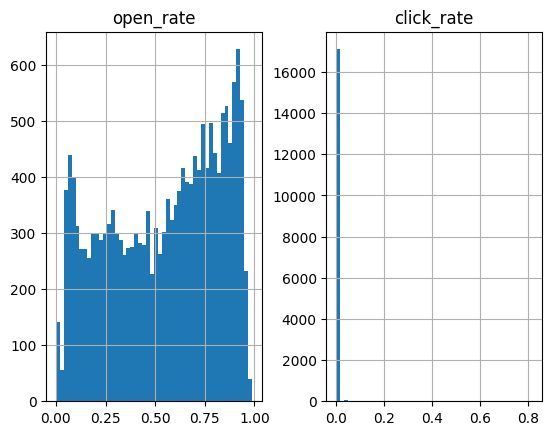

In [420]:
df_user_clean[['open_rate', 'click_rate']].hist(bins=50)

In [421]:
# click rate quantile check
df_user_clean['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500    0.000000
0.750    0.000000
0.900    0.000000
0.950    0.000000
0.990    0.036145
0.999    0.281250
Name: click_rate, dtype: float64

##### Insights
- 95% of users NEVER click
- Top 1% is small clickers (3.61% click rate)
- Top 0.1% is heavy clickers (28.13% click rate)

In [422]:
# click rate quantile check for users who DO click
df_user_clean[df_user_clean['click_rate'] > 0]['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99])

0.50    0.065217
0.75    0.156076
0.90    0.280903
0.95    0.321452
0.99    0.369069
Name: click_rate, dtype: float64

##### Insights
- Higher click rates mmong people who DO click
- Clickers are quite engaged once they exist
- Click is a rare but strong signal

In [423]:
print('% of users who ever click:', (df_user_clean['click_rate'] > 0).mean())

% of users who ever click: 0.010528751590882795


#### Classify users into engagment segmentation

In [424]:
# threshold for high and low open
open_threshold = df_user_clean['open_rate'].median()        #median because open rate is reasonably spread, but not symmetric

In [425]:
df_user_clean = df_user.dropna(subset=['open_rate', 'click_rate']).copy()

In [426]:
# create user segment

# open segment
df_user_clean['open_segment'] = np.where(
    df_user_clean['open_rate'] >= open_threshold,
    'high_open',
    'low_open')

# click segment
def classify_click(x):
    if x == 0:
        return 'no_click'
    else:
        return 'click'
    
df_user_clean['click_segment'] = df_user_clean['click_rate'].apply(classify_click)

In [427]:
# segment size
df_user_clean.groupby(['open_segment', 'click_segment']).size()

open_segment  click_segment
high_open     click              42
              no_click         8601
low_open      click             140
              no_click         8503
dtype: int64

##### Insights
- Most users frequently open emails
- Only a very small porportion proceed to click
- Users with lower open rates have higher click rates -> selective engagement may indicate stronger intent

### Gender Analysis

In [428]:
df_user_clean.groupby(
    ['open_segment', 'click_segment'])['gender'].value_counts(normalize = True)

open_segment  click_segment  gender
high_open     click          male      0.761905
                             female    0.214286
                             other     0.023810
              no_click       female    0.560865
                             male      0.417393
                             other     0.021742
low_open      click          male      0.514286
                             female    0.485714
              no_click       female    0.559214
                             male      0.420440
                             other     0.020346
Name: proportion, dtype: float64

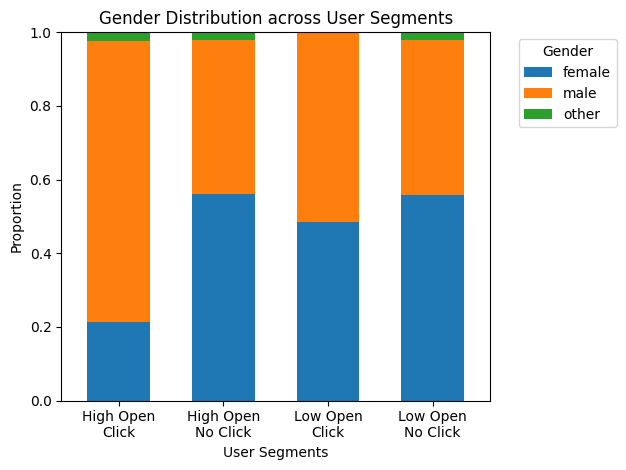

In [429]:
# bar chart

# data prep
gender_distribution = df_user_clean.groupby(
    ['open_segment','click_segment','gender']).size().unstack(fill_value = 0)

# convert to proportions
gender_distribution = gender_distribution.div(gender_distribution.sum(axis = 1), axis = 0)

# plot
gender_distribution.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(gender_distribution.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Gender Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Gender', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

##### Insights
- Male users are more likely to click (strongest in high open high click, with 76% male)
- Female users are more common in non clicking segment
- Conclusion: male users are more likely to convert from opening to clicking

### Age Analysis

In [430]:
df_user_clean.columns

Index(['user_id', 'open_rate', 'click_rate', 'total_emails', 'gender', 'age',
       'interests', 'open_segment', 'click_segment'],
      dtype='str')

In [431]:
# remove unrealistic age
df_user_clean['age_clean'] = df_user_clean['age'].where(
    (df_user_clean['age'] >= 18) &
    (df_user_clean['age'] <= 90))

##### Remark
Unrealistic age values (outside the range 18-90) were removed to ensure data quality

In [432]:
# create age group
df_user_clean['age_group'] = pd.cut(
    df_user_clean['age_clean'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

# count users per age group
df_user_clean['age_group'].value_counts(normalize = True)

age_group
35-50    0.339234
50-65    0.289767
65+      0.207081
18-35    0.163919
Name: proportion, dtype: float64

#### Engagement rate for age groups

In [433]:
# engagement rate for age groups
df_user_clean.groupby('age_group', observed = True)[['open_rate', 'click_rate']].mean()

,open_rate,click_rate
age_group,,
18-35,0.615476,0.000000
35-50,0.568138,0.000107
50-65,0.465412,0.001635
65+,0.430552,0.003300


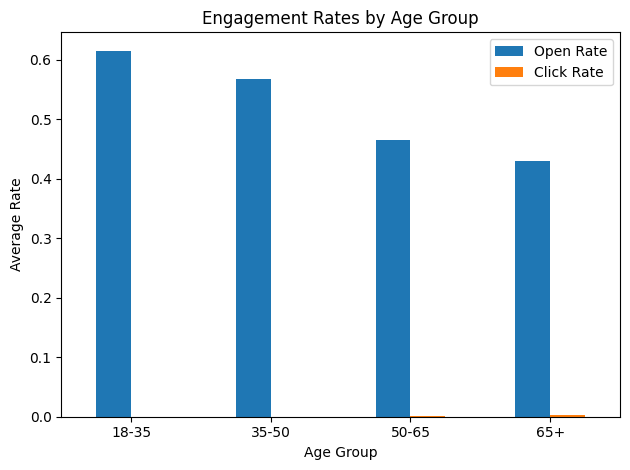

In [434]:
# bar chart

# data prep
age_rates = df_user_clean.groupby('age_group', observed=True)[['open_rate', 'click_rate']].mean()

#plot
age_rates.plot(kind='bar')

plt.title('Engagement Rates by Age Group')
plt.ylabel('Average Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(['Open Rate', 'Click Rate'])
plt.tight_layout()
plt.show()

##### Insights
- Younger users (18-35) have the highest open rate, but rarely click
- Older users (50+) have lower open rate, but more likely to click after opening
- Open rate decrease with age
- Click rate increases with age

#### Age groups vs Engagement segmentation

In [435]:
# age segment size
age_segment = pd.crosstab(
    df_user_clean['age_group'],
    [df_user_clean['open_segment'], df_user_clean['click_segment']],
    normalize = 'index')

age_segment

open_segment  high_open            low_open          
click_segment     click  no_click     click  no_click
age_group                                            
18-35          0.000000  0.624260  0.000000  0.375740
35-50          0.000715  0.519657  0.002144  0.477484
50-65          0.001674  0.380753  0.012552  0.605021
65+            0.008197  0.325527  0.028103  0.638173

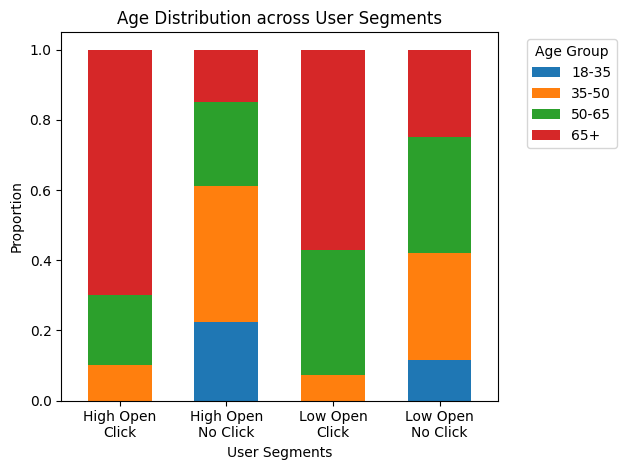

In [436]:
df_user_clean['combined_segment'] = (
    df_user_clean['open_segment'] + ' & ' + df_user_clean['click_segment'])

age_by_segment = pd.crosstab(
    df_user_clean['combined_segment'],
    df_user_clean['age_group'],
    normalize = 'index')

# plot
age_by_segment.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(age_by_segment.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Age Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##### Insights
- Older users (50+) are more likely to click than younger users
- Younger users (18-35) almost never click (regardless of open level)

### Interest Analysis

#### Explore top interests among users

In [437]:
# explode data with interests
df_interests = df_user_clean.copy()
df_interests = df_interests.explode('interests')

In [438]:
# top user interests
top_interests = df_interests['interests'].value_counts().head(10)
print(top_interests)

interests
bladen         17115
acties         16890
kranten        16738
winactie       16167
cadeau         16060
kortingen      16056
energie        15522
goededoelen    14345
onderzoek      14124
auto           11837
Name: count, dtype: int64


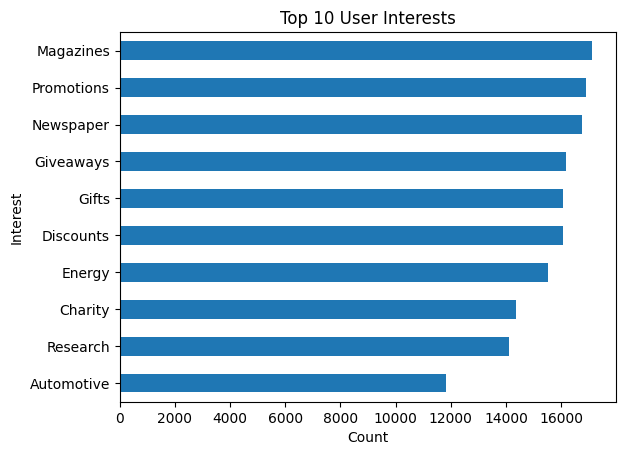

In [439]:
# bar chart

# english translation
interest_map = {
    'bladen': 'Magazines',
    'acties': 'Promotions',
    'kranten': 'Newspaper',
    'winactie': 'Giveaways',
    'cadeau': 'Gifts',
    'kortingen': 'Discounts',
    'energie': 'Energy',
    'goededoelen': 'Charity',
    'onderzoek': 'Research',
    'auto': 'Automotive'}

top_interests_en = top_interests.rename(index = interest_map)

#plot
top_interests_en.plot(kind='barh')
plt.title('Top 10 User Interests')
plt.xlabel('Count')
plt.ylabel('Interest')
plt.gca().invert_yaxis()
plt.show()

##### Insights
- Promotional interests dominate user preferences (promotions, giveaways, gifts, discounts)
- Users show strong interests in informational content (magazines, newspaper, research)
- Commercial topics are also significant (energy and automotive)

#### Explore interests with high engagment rates

In [440]:
# aggregate engagement per interest
interest_engagement = df_interests.groupby('interests').agg(
    open_mean=('open_rate', 'mean'),
    click_mean=('click_rate', 'mean'),
    count=('user_id', 'count'))

interest_engagement.head()

,open_mean,click_mean,count
interests,,,
acties,0.551747,0.001207,16890
android,0.289489,0.001972,1328
audi,0.631697,0.000649,9299
auto,0.574323,0.000851,11837
auto inruilen,0.614763,0.000875,9740


In [441]:
interest_counts = df_interests['interests'].value_counts()
interest_counts.describe()

count       60.000000
mean      6146.933333
std       5542.869329
min          1.000000
25%        723.500000
50%       5429.500000
75%      10089.000000
max      17115.000000
Name: count, dtype: float64

In [442]:
# remove small counts

#threshold for counts
count_threshold = threshold = df_interests['interests'].value_counts().quantile(0.25)
interest_filtered = interest_engagement[
    interest_engagement['count'] >= count_threshold]

##### Remark
Interests with low counts (bottom 25%) to avoid unreliable estimates

In [443]:
# sort interests by open rates
interest_filtered.sort_values('open_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
bezorgmaaltijden,0.753736,0.000156,1806
mazda6e,0.674259,0.001288,4399
finance,0.661999,0.000579,7736
verzekering,0.660851,0.000921,6583
beleggen,0.659138,0.000777,7154
bank,0.648134,0.000579,7270
mercedes,0.648010,0.001059,2704
hypotheek,0.642729,0.000072,1516
bedrijfswagen,0.637129,0.000845,1459


In [444]:
# sort interests by click rates
interest_filtered.sort_values('click_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
windows,0.342804,0.002584,2009
android,0.289489,0.001972,1328
mazda6e,0.674259,0.001288,4399
goededoelen,0.566153,0.001282,14345
acties,0.551747,0.001207,16890
bladen,0.547079,0.001195,17115
ondernemers,0.626589,0.001139,5659
mercedes,0.648010,0.001059,2704
bedrijven,0.571938,0.001017,2413


Some overlap between popular and interests with high engagement, but the relationship is not strong or consistent

# Analysis Part 2

## Gender x Campaign Cross Analysis

In [445]:
# get the campaign group per mailing
df_final_with_groups = df_final.merge(
    result[['open_group', 'click_group']].reset_index(), 
    on=['subject_line', 'preheader'],
    how='left')

# gender distribution within each campaign group
gender_campaign_group = df_final_with_groups.groupby(
    ['open_group', 'click_group', 'gender']
).agg(
    open_rate=('open', 'mean'),
    click_rate=('click', 'mean'),
    count=('open', 'count')
).reset_index()

print(gender_campaign_group)

   open_group click_group  gender  open_rate  click_rate   count
0        high        high  female   0.614244    0.005240   52961
1        high        high    male   0.612138    0.005530   44454
2        high        high   other   0.633645    0.001855    1605
3        high         low  female   0.634167    0.000393  286333
4        high         low    male   0.632093    0.001172  221703
5        high         low   other   0.637684    0.000000   10328
6         low        high  female   0.080934    0.003341    8439
7         low        high    male   0.063905    0.001897    6228
8         low        high   other   0.049645    0.000000     282
9         low         low  female   0.423462    0.000285  219382
10        low         low    male   0.417381    0.000824  166723
11        low         low   other   0.443191    0.000000    7446


Open rate by campaign group Ã— gender:
gender                    female      male     other
open_group click_group                              
high       high         0.614244  0.612138  0.633645
           low          0.634167  0.632093  0.637684
low        high         0.080934  0.063905  0.049645
           low          0.423462  0.417381  0.443191


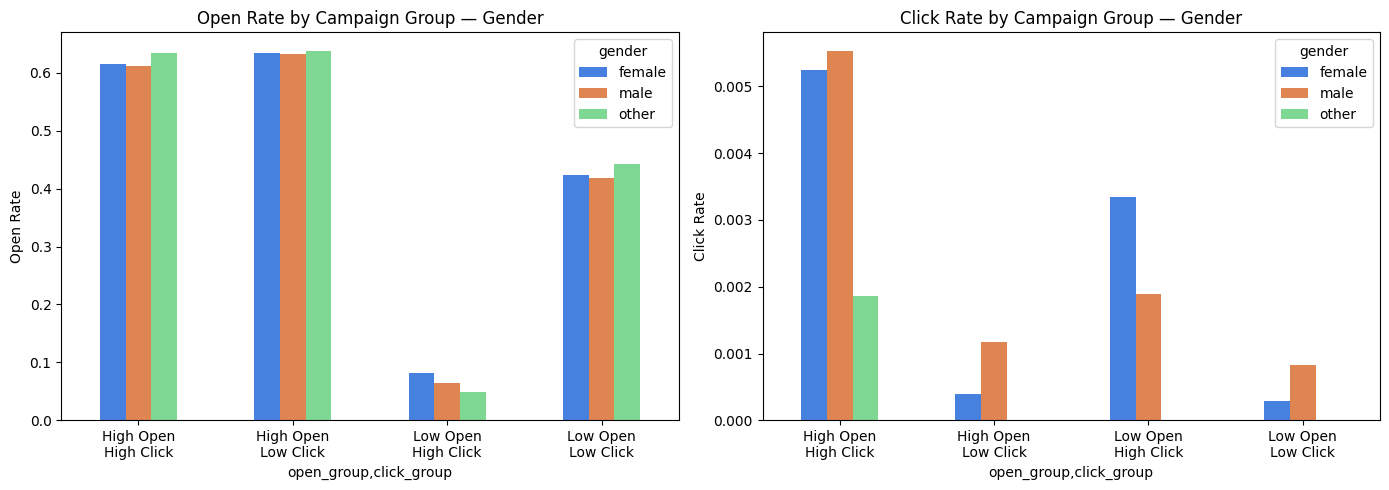

In [446]:
# Pivot: open rate per gender per campaign group
pivot_gender_campaign = df_final_with_groups.groupby(
    ['open_group', 'click_group', 'gender']
)['open'].mean().unstack('gender')

print("Open rate by campaign group Ã— gender:")
print(pivot_gender_campaign)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open rate
pivot_open = df_final_with_groups.groupby(
    ['open_group', 'click_group', 'gender']
)['open'].mean().unstack('gender')

pivot_open.plot(kind='bar', ax=axes[0], color=['#4681E0', '#DE8551', '#7ED893'])
axes[0].set_title('Open Rate by Campaign Group — Gender')
axes[0].set_ylabel('Open Rate')
axes[0].set_xticklabels([
    'High Open\nHigh Click', 'High Open\nLow Click',
    'Low Open\nHigh Click', 'Low Open\nLow Click'],
    rotation=0)

# Click rate
pivot_click = df_final_with_groups.groupby(
    ['open_group', 'click_group', 'gender']
)['click'].mean().unstack('gender')

pivot_click.plot(kind='bar', ax=axes[1], color=['#4681E0', '#DE8551', '#7ED893'])
axes[1].set_title('Click Rate by Campaign Group — Gender')
axes[1].set_ylabel('Click Rate')
axes[1].set_xticklabels([
    'High Open\nHigh Click', 'High Open\nLow Click',
    'Low Open\nHigh Click', 'Low Open\nLow Click'],
    rotation=0)

plt.tight_layout()
plt.show()

Open rate barely differs by gender within any campaign group (bars are nearly equal height), but click rate shows more variation, particularly in the "Low Open / High Click" group where females click noticeably more. The dominant driver of both rates is clearly the campaign group (high vs low open), not gender.

## Age Group x Campaign Cross Analysis

In [447]:
# Merge age group into df_final
df_final_enriched = df_final_with_groups.merge(
    df_user_clean[['user_id', 'age_group', 'age_clean']].drop_duplicates(),
    on='user_id',
    how='left'
)

# Open and click rate by age group — campaign group
age_campaign = df_final_enriched.groupby(
    ['age_group', 'open_group', 'click_group'],
    observed=True
).agg(
    open_rate=('open', 'mean'),
    click_rate=('click', 'mean'),
    count=('open', 'count')
).reset_index()

print(age_campaign)

   age_group open_group click_group  open_rate  click_rate  count
0      18-35       high        high   0.730980    0.000000   2918
1      18-35       high         low   0.734510    0.000000  18980
2      18-35        low        high   0.061810    0.000000    453
3      18-35        low         low   0.493561    0.000000  14132
4      35-50       high        high   0.657760    0.000405   7410
5      35-50       high         low   0.679698    0.000168  41670
6      35-50        low        high   0.065603    0.000000   1128
7      35-50        low         low   0.442831    0.000064  31328
8      50-65       high        high   0.554516    0.008328   7805
9      50-65       high         low   0.566781    0.000645  37196
10     50-65        low        high   0.082553    0.003404   1175
11     50-65        low         low   0.347755    0.000578  29400
12       65+       high        high   0.521117    0.012929   5801
13       65+       high         low   0.519017    0.001365  27107
14       6

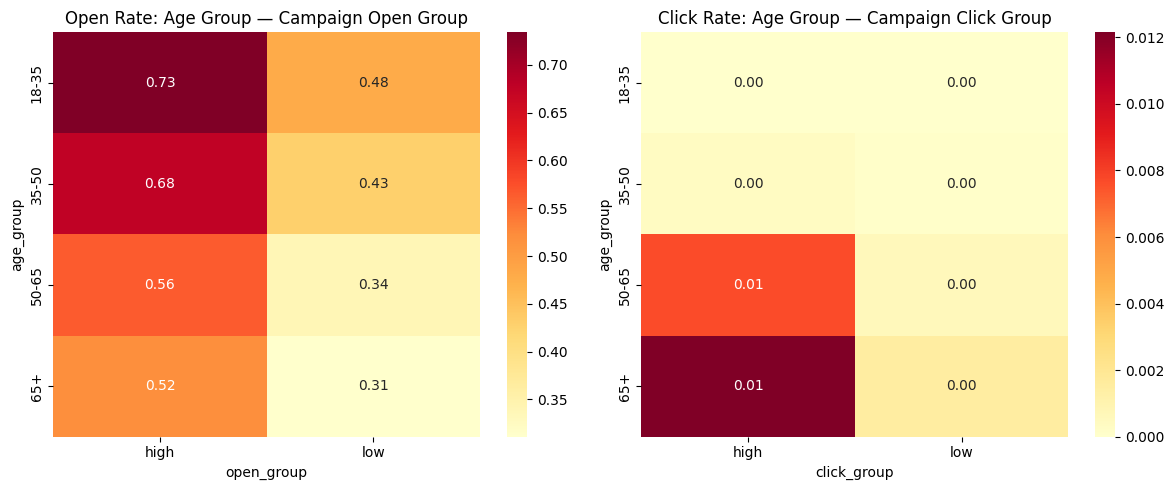

In [448]:
# Heatmap: open rate age group — campaign group
pivot_age_open = df_final_enriched.groupby(
    ['age_group', 'open_group'],
    observed=True
)['open'].mean().unstack('open_group')

pivot_age_click = df_final_enriched.groupby(
    ['age_group', 'click_group'],
    observed=True
)['click'].mean().unstack('click_group')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    pivot_age_open, annot=True, fmt='.2f',
    cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Open Rate: Age Group — Campaign Open Group')

sns.heatmap(
    pivot_age_click, annot=True, fmt='.2f',
    cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Click Rate: Age Group — Campaign Click Group')

plt.tight_layout()
plt.show()

Open Rate: Age Group — Campaign Open Group shows a clear pattern: younger age groups open more (18-35 at 0.73 in the high group), and open rates decline steadily with age. The "high" campaign group consistently outperforms "low" across all ages.

Click Rate: Age Group — Campaign Click Group reveals something interesting: click rates are essentially zero for 18-35 and 35-50, but 50-65 and 65+ show actual clicking behavior (0.01) — only in the high click group. This suggests older users who do click are the ones driving click engagement.

## Interest x Campaign Cross Analysis

In [449]:
top_n_interests = df_interests['interests'].value_counts().head(15).index.tolist()

# Explode interests in enriched dataset
df_exploded_interests = df_final_enriched.copy()
df_exploded_interests['interests'] = df_exploded_interests['interests'].apply(
    lambda x: x if isinstance(x, list) else []
)
df_exploded_interests = df_exploded_interests.explode('interests')
df_exploded_interests = df_exploded_interests[
    df_exploded_interests['interests'].isin(top_n_interests)
]

# Open and click rate by interest — campaign group
interest_campaign = df_exploded_interests.groupby(
    ['interests', 'open_group', 'click_group']
).agg(
    open_rate=('open', 'mean'),
    click_rate=('click', 'mean'),
    count=('open', 'count')
).reset_index()

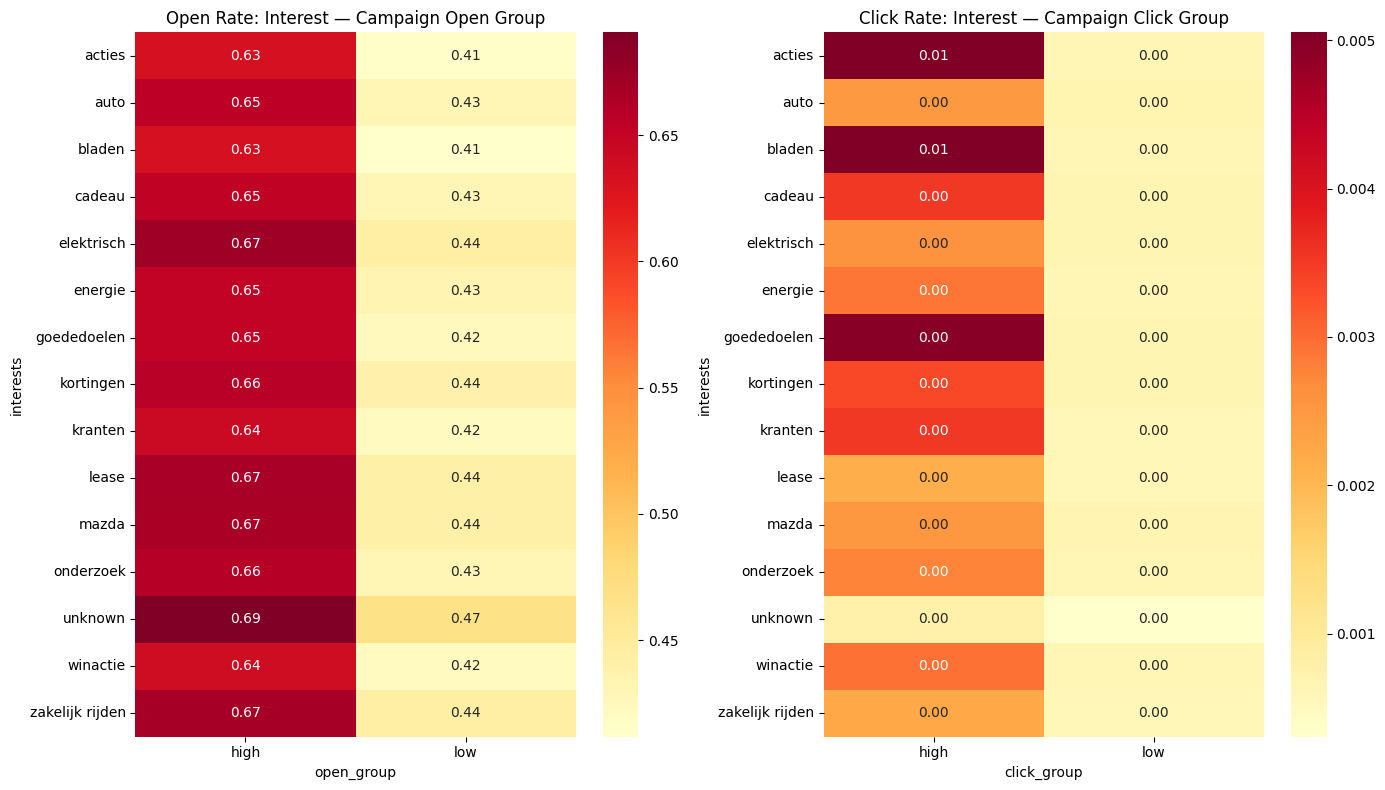

In [450]:
# Heatmap: interest — campaign group open rate
pivot_interest_open = df_exploded_interests.groupby(
    ['interests', 'open_group']
)['open'].mean().unstack('open_group')

pivot_interest_click = df_exploded_interests.groupby(
    ['interests', 'click_group']
)['click'].mean().unstack('click_group')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(
    pivot_interest_open, annot=True, fmt='.2f',
    cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Open Rate: Interest — Campaign Open Group')

sns.heatmap(
    pivot_interest_click, annot=True, fmt='.2f',
    cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Click Rate: Interest — Campaign Click Group')

plt.tight_layout()
plt.show()

The heatmaps confirm what was seen with age: open rate is driven by campaign group, not interest (all interests score ~0.63-0.69 in high group). Click rates are near zero for most interests except acties and bladen (0.01).

In [451]:
# Which interests are overrepresented in high open/click campaigns?
high_perf = df_exploded_interests[
    (df_exploded_interests['open_group'] == 'high') &
    (df_exploded_interests['click_group'] == 'high')
]
low_perf = df_exploded_interests[
    (df_exploded_interests['open_group'] == 'low') &
    (df_exploded_interests['click_group'] == 'low')
]

interest_lift = pd.DataFrame({
    'high_perf_rate': high_perf['interests'].value_counts(normalize=True),
    'low_perf_rate': low_perf['interests'].value_counts(normalize=True)
}).dropna()

interest_lift['lift'] = (
    interest_lift['high_perf_rate'] / interest_lift['low_perf_rate']
)

print("\nInterest lift  high vs low performing campaigns:")
print(interest_lift.sort_values('lift', ascending=False))


Interest lift  high vs low performing campaigns:
                 high_perf_rate  low_perf_rate      lift
interests                                               
elektrisch             0.060700       0.054396  1.115889
mazda                  0.062030       0.055728  1.113087
lease                  0.061656       0.055469  1.111545
zakelijk rijden        0.061267       0.055394  1.106037
auto                   0.063767       0.058810  1.084272
unknown                0.054472       0.052767  1.032322
goededoelen            0.069440       0.068395  1.015284
onderzoek              0.067122       0.066615  1.007617
energie                0.069097       0.071932  0.960593
cadeau                 0.069809       0.073343  0.951814
kortingen              0.068697       0.072273  0.950515
winactie               0.071916       0.076153  0.944359
kranten                0.071535       0.077119  0.927600
acties                 0.074130       0.080276  0.923444
bladen                 0.074361       

The lift scores ranked from highest to lowest show that elektrisch (1.116), mazda (1.113), lease (1.112), and zakelijk rijden (1.106) are most overrepresented in high-performing campaigns — these are all car/mobility-related interests, which makes sense given this appears to be a Mazda/automotive marketing dataset. bladen and acties have lift < 1, meaning they're actually more common in low-performing campaigns.

## Interest x Gender - Engagement Analysis

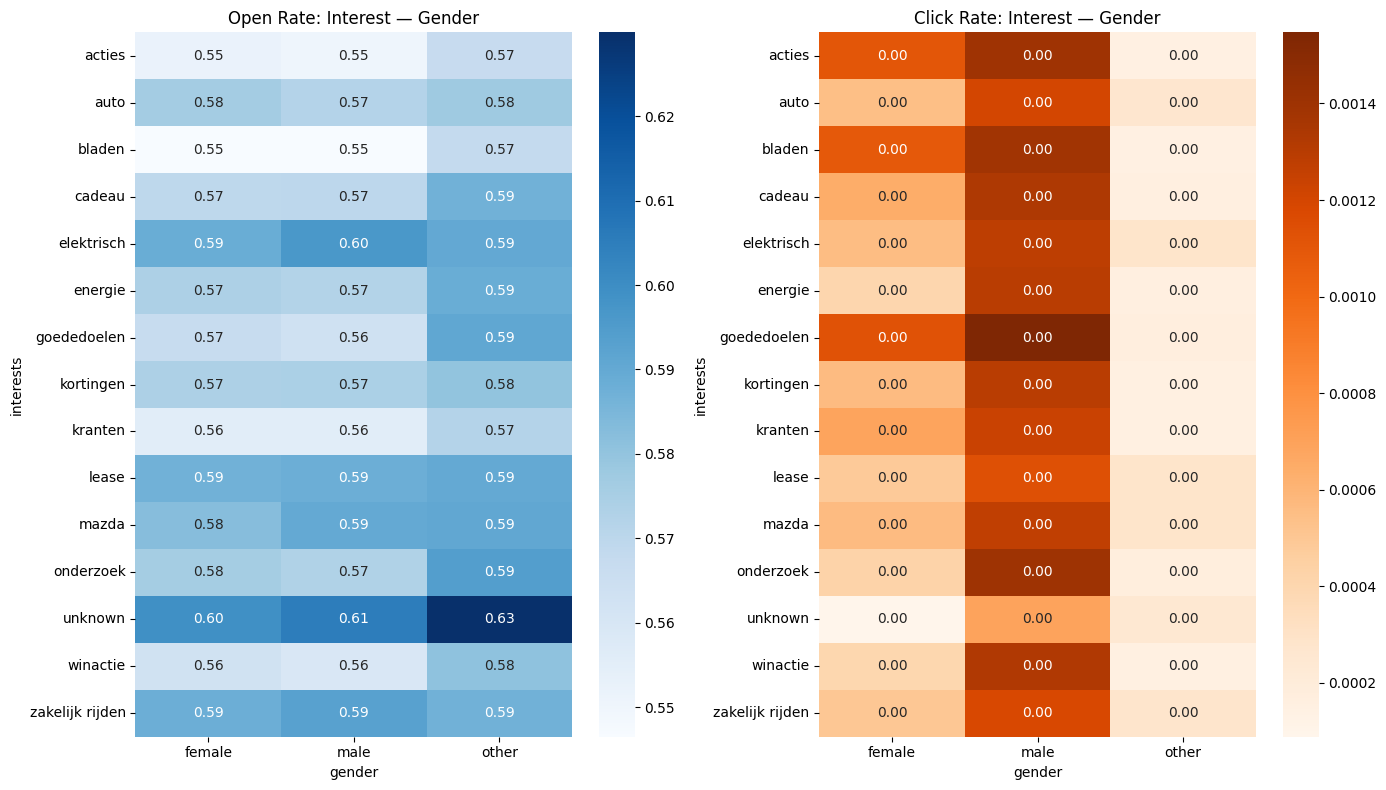

In [452]:
df_interest_user = df_user_clean.copy()
df_interest_user = df_interest_user.explode('interests')
df_interest_user = df_interest_user[
    df_interest_user['interests'].isin(top_n_interests)
]

# Open rate by interest Ã— gender
pivot_interest_gender_open = df_interest_user.groupby(
    ['interests', 'gender']
)['open_rate'].mean().unstack('gender')

pivot_interest_gender_click = df_interest_user.groupby(
    ['interests', 'gender']
)['click_rate'].mean().unstack('gender')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.heatmap(
    pivot_interest_gender_open, annot=True, fmt='.2f',
    cmap='Blues', ax=axes[0])
axes[0].set_title('Open Rate: Interest — Gender')

sns.heatmap(
    pivot_interest_gender_click, annot=True, fmt='.2f',
    cmap='Oranges', ax=axes[1])
axes[1].set_title('Click Rate: Interest — Gender')

plt.tight_layout()
plt.show()

Open rate heatmap shows very uniform values across all interest-gender combinations — everything sits between 0.55 and 0.63. This confirms that neither interest nor gender meaningfully predicts open rate on its own; campaign group was the dominant driver found earlier.
One small standout: unknown interest + other gender scores 0.63, slightly above the rest.

Click rate heatmap shows essentially 0.00 everywhere, with the color variation coming from tiny decimal differences (the scale only goes up to 0.0014). The darkest cells — goededoelen female/male and onderzoek female — have marginally higher click rates but still negligibly small in absolute terms.

Takeaway: interest and gender together don't add much explanatory power beyond what campaign group already captures.

## Interest x Age Group - Engagement Analysis

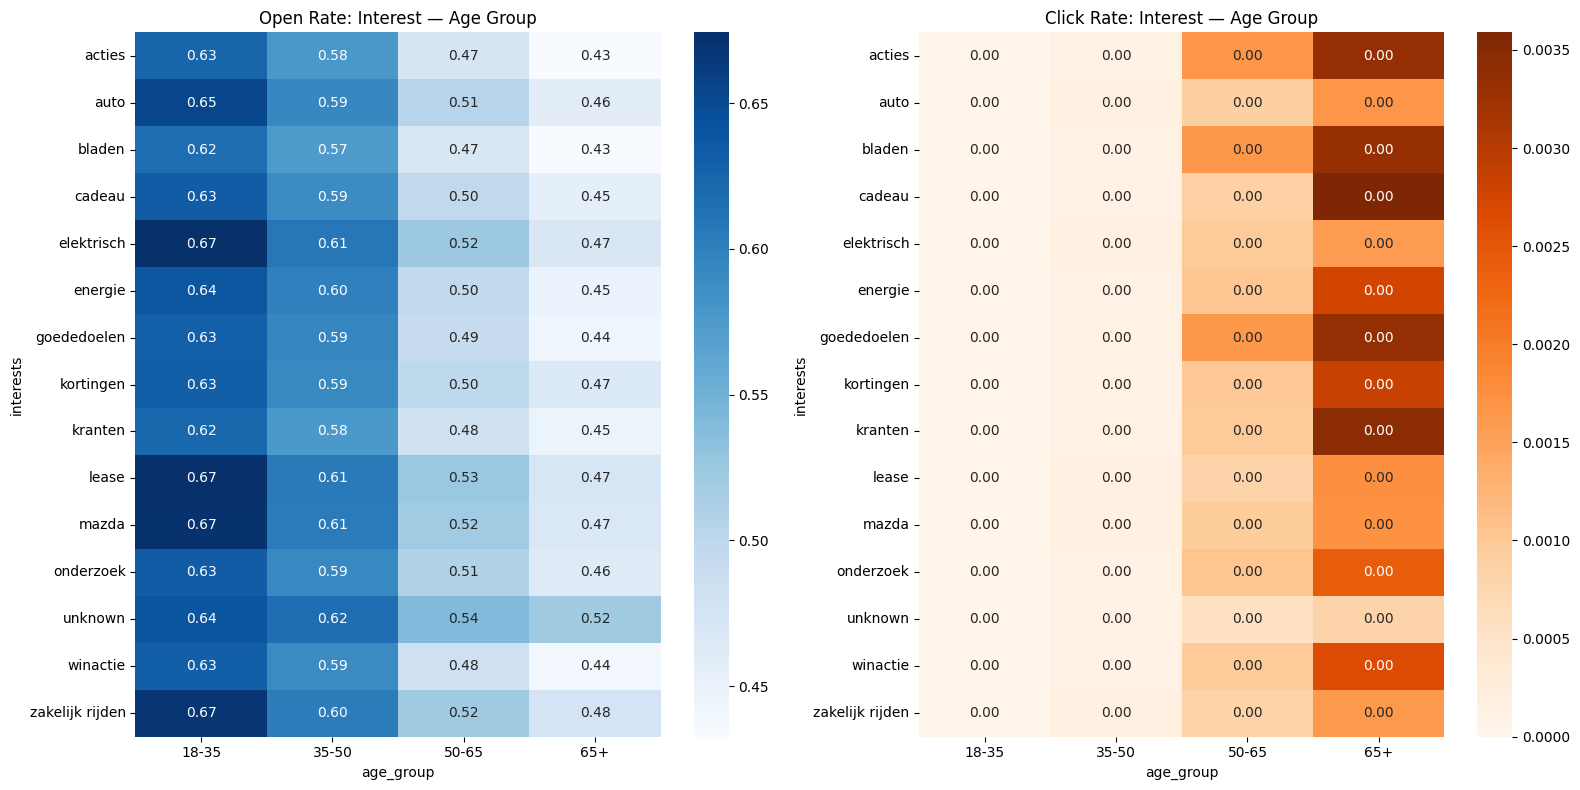

In [453]:
pivot_interest_age_open = df_interest_user.groupby(
    ['interests', 'age_group'],
    observed=True
)['open_rate'].mean().unstack('age_group')

pivot_interest_age_click = df_interest_user.groupby(
    ['interests', 'age_group'],
    observed=True
)['click_rate'].mean().unstack('age_group')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    pivot_interest_age_open, annot=True, fmt='.2f',
    cmap='Blues', ax=axes[0])
axes[0].set_title('Open Rate: Interest — Age Group')

sns.heatmap(
    pivot_interest_age_click, annot=True, fmt='.2f',
    cmap='Oranges', ax=axes[1])
axes[1].set_title('Click Rate: Interest — Age Group')

plt.tight_layout()
plt.show()

Open rate heatmap shows a clear age gradient across every single interest — open rates consistently decline from left to right: 18-35 opens the most, 65+ opens the least. For example elektrisch, lease, mazda, and zakelijk rijden all score 0.67 for 18-35 and drop to 0.47 for 65+.
Importantly, the pattern is the same regardless of interest — the columns shift uniformly. This means age drives open rate more than interest does, and the two effects are largely independent.

Click rate heatmap again shows near-zero values everywhere, but the color gradient is reversed — older age groups (50-65, 65+) are darker orange, confirming the earlier finding that clicking is concentrated among older users. Interests like bladen, cadeau, kranten, and kortingen show the darkest cells in the 65+ column, which makes intuitive sense — these are magazine, discount, and gift-related interests more typical of older audiences.

## Email Frequency Fatigue - Demographics Analysis

In [454]:
# Bin total emails received into frequency groups
df_user_clean['frequency_group'] = pd.cut(
    df_user_clean['total_emails'],
    bins=[0, 5, 10, 20, 50, 999],
    labels=['1-5', '6-10', '11-20', '21-50', '50+']
)

# Fatigue curve overall
fatigue_overall = df_user_clean.groupby(
    'frequency_group',
    observed=True
)[['open_rate', 'click_rate']].mean()

print("Fatigue effect overall:")
print(fatigue_overall)



Fatigue effect overall:
                 open_rate  click_rate
frequency_group                       
6-10              0.334583    0.000000
11-20             0.550368    0.000230
21-50             0.543064    0.002759
50+               0.542874    0.000902


Open rate is lowest at 6-10 emails (0.33), then jumps up at 11-20 (0.55) and stays relatively flat after that. This is the opposite of what email fatigue theory would predict, suggesting the 1-5 group (not shown here) and 6-10 group may contain less engaged or newer users rather than fatigued ones.

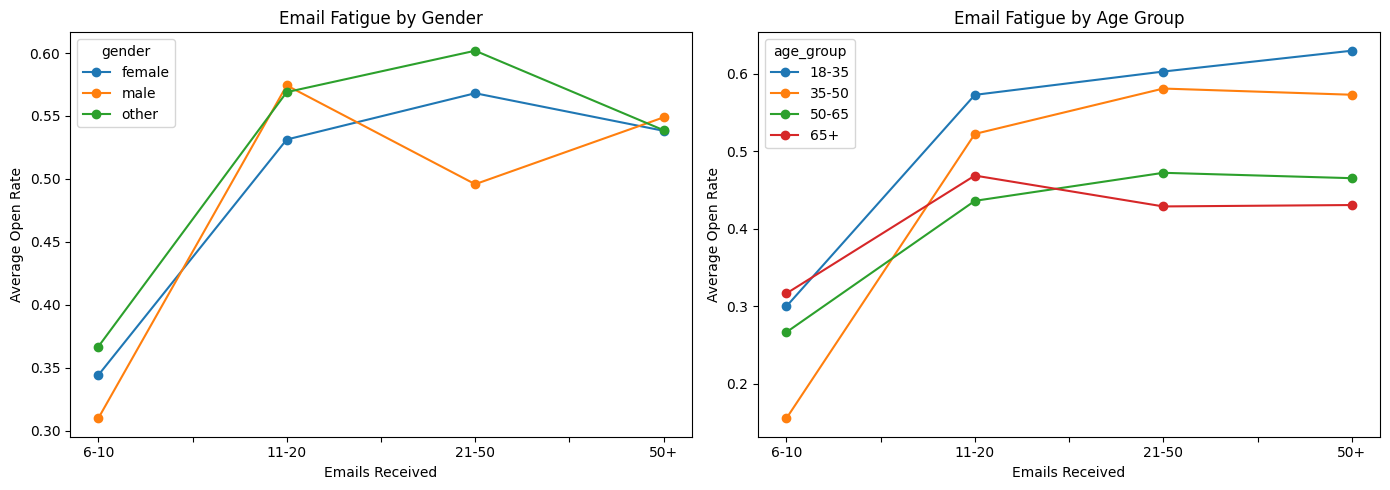

In [455]:
# Fatigue — gender
fatigue_gender = df_user_clean.groupby(
    ['frequency_group', 'gender'],
    observed=True
)[['open_rate', 'click_rate']].mean()

pivot_fatigue_gender = fatigue_gender['open_rate'].unstack('gender')

# Fatigue — age group
fatigue_age = df_user_clean.groupby(
    ['frequency_group', 'age_group'],
    observed=True
)[['open_rate', 'click_rate']].mean()

pivot_fatigue_age = fatigue_age['open_rate'].unstack('age_group')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_fatigue_gender.plot(ax=axes[0], marker='o')
axes[0].set_title('Email Fatigue by Gender')
axes[0].set_ylabel('Average Open Rate')
axes[0].set_xlabel('Emails Received')

pivot_fatigue_age.plot(ax=axes[1], marker='o')
axes[1].set_title('Email Fatigue by Age Group')
axes[1].set_ylabel('Average Open Rate')
axes[1].set_xlabel('Emails Received')

plt.tight_layout()
plt.show()

Gender chart shows all three groups following the same rise-then-plateau pattern, with no gender meaningfully more fatigue-prone than another. The "other" group is slightly more volatile, likely due to smaller sample size.

Age group chart is more revealing, 18-35 and 35-50 show a steady rise in open rate as email volume increases, reaching 0.60 at 50+. This suggests younger, more engaged users self-select into receiving more emails. 50-65 and 65+ plateau much earlier and at lower rates (~0.42-0.48), consistent with lower overall engagement seen throughout the analysis.

Overall, no clear fatigue effect — higher email volume is associated with equal or higher open rates, likely because users who engage more also receive more emails (selection bias rather than causation).

## Campaign Topic Analysis

### Data preparation: classification into campaigns 

In [456]:
# create campaign topic table
df_campaigns = df2.copy()
campaign_topics = df_campaigns[['mailing_id', 'mailing_info', 'subject_line', 'preheader']].copy()

# drop duplicates
campaign_topics = campaign_topics.drop_duplicates(subset = ['mailing_id'])

In [457]:
campaign_topics.head()

,mailing_id,mailing_info,subject_line,preheader
0,1422,2026/04/22 CENTRAAL BEHEER_RNC_2,Hoe lang kun jij zonder inkomen als je arbeids...,NaN
1,1420,2026/04/21 CENTRAAL BEHEER_RNC_1,Hoe lang kun jij zonder inkomen als je arbeids...,NaN
2,1419,2026/04/21 Direct Doen wk17 - Donald Duck Stra...,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...
3,1418,2026/04/21 CRS wk17 - Donald Duck Strandpakket,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...
4,1417,2026/04/21 CPX wk17 - Donald Duck Strandpakket,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...


In [458]:
campaign_topics.shape

(337, 4)

In [459]:
# add classification column
campaign_topics['main_topic'] = ''

In [460]:
# combine mailing info, subject line, preheader
campaign_topics['combined_info'] = (
    campaign_topics['mailing_info'].fillna('') + '' + 
    campaign_topics['subject_line'].fillna('') + '' + 
    campaign_topics['preheader'].fillna(''))

In [461]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Mazda|Audi|Hyundai|Toyota|mobiliteit', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
21,1367,2026/03/26 - HYUNDAIComfortabel rijden met een...
22,1365,2026/04/02 - Mazda CX 6e - RODe volledig nieuw...
26,1361,2026/03/24 - Mazda CX 6e - RNOEen nieuwe stand...
28,1355,260319 - NS - Duurzame mobiliteit in de zorg R...
29,1354,2026/03/19 - Mazda CX 6e - UITROLOntdek de rui...
...,...,...
304,735,250515 Mazda6e zakelijke - UITROLDe Mazda6e: e...
308,729,250508 Mazda6e zakelijke - S2Maak nu kennis me...
312,721,250508 Mazda6e zakelijke - S1De Mazda6e: elekt...
334,646,2025/03/25 MAZDA CX-60 JAPAN ROJouw proefrit i...


In [462]:
# classify automotive/mobility topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Mazda|Audi|Hyundai|Toyota|mobiliteit', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Automotive & Mobility'

In [463]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,
1,1420,
2,1419,
3,1418,
4,1417,
5,1411,
6,1408,
7,1403,
8,1402,
9,1400,


In [464]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'magazine|krant|film|media|De Telegraaf|Libelle|Donald|economie|VARAgids|politiek|landleven|wetenschap', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
2,1419,2026/04/21 Direct Doen wk17 - Donald Duck Stra...
3,1418,2026/04/21 CRS wk17 - Donald Duck Strandpakket...
4,1417,2026/04/21 CPX wk17 - Donald Duck Strandpakket...
10,1399,2026/04/14 CRS WK16 – MAX + HEMAMAX Magazine é...
11,1398,2026/04/14 CPX WK16 – MAX + HEMAMAX Magazine é...
...,...,...
309,728,2025/05/13 CPX - LANDLEVENLaatste kans: 6x Lan...
322,692,2025/05/29 DPG 4W1E4 weken jouw favoriete kran...
327,669,2025/04/24 - MM Vipmedia - Voorjaarsactie TWOL...
328,668,2025/04/24 CPX - MM MAX Magazine - 4 gratis nr...


In [465]:
# classify media/publishing topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'magazine|krant|film|media|De Telegraaf|Libelle|Donald|economie|VARAgids|politiek|landleven|wetenschap', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Media & Publishing'

In [466]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,
1,1420,
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,
6,1408,
7,1403,
8,1402,
9,1400,


In [467]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'inkomen|pensioen|Roadway|capital|invest|beleggen|AOV|Tikkie|autoverzekering', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
0,1422,2026/04/22 CENTRAAL BEHEER_RNC_2Hoe lang kun j...
1,1420,2026/04/21 CENTRAAL BEHEER_RNC_1Hoe lang kun j...
5,1411,2026/04/20 CENTRAAL BEHEER_Uitrol 2Weet jij ho...
6,1408,2026/04/16 CENTRAAL BEHEER_Uitrol 1Weet jij ho...
7,1403,2026/04/14 CENTRAAL BEHEER S2Nu 50% korting op...
8,1402,2026/04/14 CENTRAAL BEHEER S1Weet jij hoelang ...
255,838,250701 Roadway - RNO80% al verkocht! laatste k...
256,831,2025/06/26 ASR_Pensioen_HM DEFPensioen regelen...
257,828,2025/06/26 ASR_Pensioen_HMPensioen regelen voo...
263,819,250624 Roadway - RNCInvesteer nu met 12% vast ...


In [468]:
# classify finance/investment topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'inkomen|pensioen|Roadway|capital|invest|beleggen|AOV|Tikkie|autoverzekering', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Finance & Investment'

In [469]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [470]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Engie|zonne|powerbank|airco', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
183,995,2025/10/08 - CPX - ENGIEMaak de zin compleet e...
195,959,2025/09/23 - CPX - ENGIEMaak de zin compleet e...
209,935,2025/09/11 CPX - MM - ENGIEHeb jij het het ENG...
216,926,2025/09/02 TEST Joyce ENGIE DEF.{$voornaam|def...
217,925,2025/09/02 TEST Joyce ENGIE (Copy 20250908-13:...
218,924,"2025/09/02 TEST Joyce ENGIE{$voornaam}, downlo..."
223,914,2025/09/02 CPX - MM - ENGIEXX
239,883,2025/08/12 CPX - MM - ENGIE POWERBANKXX
254,846,2025/07/02 - CPX - MM ENGIE SimpSune Solar Pow...
289,761,2025/05/27 CPX - MM - ENGIESpeel mee met de EN...


In [471]:
# classify energy/sustainability topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Engie|zonne|powerbank|airco', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Energy & Sustainability'

In [472]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [473]:
campaign_topics['main_topic'].value_counts(dropna = False)

main_topic
                           148
Automotive & Mobility       78
Media & Publishing          77
Finance & Investment        22
Energy & Sustainability     12
Name: count, dtype: int64

In [474]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'goede doelen|hulp|Lepra|Oranje Fond|burendag', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
96,1198,Dec CRS stichting LepraEen wereld zonder lepra...
97,1197,Dec CRS Hulphond 2Ontdek hoe Hulphond Nederlan...
98,1196,Dec CRS Hulphond 1Meer weten over de impact va...
99,1195,Dec CRS Goede doelen 2Ontdek het goede doel da...
100,1194,Dec CRS Goede doelen 1Ontmoet 5 goede doelen d...
108,1146,251126 CPX stichting Lepra - WK48Een wereld zo...
111,1135,20 Nov CRS Goede doelen 2Ontdek het goede doel...
112,1134,20 Nov CRS Goede doelen 1Ontmoet 5 goede doele...
113,1133,20 Nov CRS Hulphond 2Ontdek hoe Hulphond Neder...
114,1132,20 Nov CRS Hulphond 1Meer weten over de impact...


In [475]:
# classify charity/social impact topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'goede doelen|hulp|Lepra|Oranje Fond|burendag', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Charity & Social Impact'

In [476]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [477]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'MKbasics|RANDSTAD|Regus|zaken|ziekteverzuim|groeien', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
65,1266,"2026/01/27 - RANDSTAD RNO deel 2Mis het niet, ..."
72,1257,"2026/01/27 - RANDSTAD RNC deel 2Mis het niet, ..."
73,1252,2026/01/22 - RANDSTAD Uitrol 2 - Restandupdate...
74,1251,"2026/01/20 - RANDSTAD Uitrol 2B{$voornaam}, jo..."
75,1248,2026/01/20 - RANDSTAD Uitrol 2Aupdate HR wet- ...
76,1246,"2026/01/19 - RANDSTAD RNO_1Mis het niet, {$voo..."
81,1239,"2026/01/14 - RANDSTAD REMMis het niet, {$voorn..."
87,1228,2026/01/05 - RANDSTAD{$voornaam|default=Beste}...
198,952,2025/09/19 RANDSTAD - RNO{$voornaam|default=Be...
200,947,2025/09/16 RANDSTAD - RNC{$voornaam|default=Be...


In [478]:
# classify business topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'MKbasics|RANDSTAD|Regus|zaken|ziekteverzuim|groeien', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Business'

In [479]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [480]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Nespresso|Uitgekookt', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
45,1312,26/02/19 Nespresso - Sell Fase - F7Nespresso z...
47,1303,26/02/12 Nespresso - Tell Fase - F5Een prettig...
54,1290,26/02/09 Nespresso - Tell Fase - F4Hoe creëer ...
60,1282,26/02/05 Nespresso - Touch Fase - F2 RNOIs kof...
69,1260,26/01/27 Nespresso - Sell FaseNespresso zonder...
70,1259,26/02/09 Nespresso - Tell Fase - F3Hoe creëer ...
71,1258,26/02/03 Nespresso - Touch FaseIs koffie het g...
147,1075,25/11/06 NESPRESSO HORECA RNOMaak van koffie e...
149,1065,25/11/04 NESPRESSO HORECA RNCBaristakwaliteit ...
161,1033,25/10/20 NESPRESSO HORECABarista-kwaliteit kof...


In [481]:
# classify food/beverages topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Nespresso|Uitgekookt', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Food & Beverages'

In [482]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [483]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Odido', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
148,1066,251104 - Odido - RNOFirefly laat zien hoe lich...
151,1055,251030- Odido - UitrolDeze slimme oplossing in...
171,1015,251028 - Odido - S1Deze slimme oplossing inspi...


In [484]:
# classify telecom/technology topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Odido', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Telecom & Technology'

In [485]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [486]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Belife|mentaal|Pearle', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
173,1012,2025/10/13 - BELIFE - RNOMentaal sterker in we...
185,988,2025/10/06 - BELIFE - RNCMentaal sterker worde...
190,966,2025/09/24 - BELIFEVergroot je mentale flexibi...
260,822,2025/06/24 PEARLE - Reminder non opens 40-60La...
261,821,2025/06/24 PEARLE - Reminder non opens 16-35La...
270,801,2025/06/03 PEARLE - Reminder non clicks 40-60L...
271,800,2025/06/03 PEARLE - Reminder non clicks 16-35L...
274,793,2025/06/03 PEARLE - Uitrol 40-60Probeer gratis...
275,792,2025/06/03 PEARLE - Uitrol 15-35Probeer gratis...
280,783,2025/06/03 PEARLE - S2Test nu gratis contactle...


In [487]:
# classify health/wellbeing topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Belife|mentaal|Pearle', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Health & Wellbeing'

In [488]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [489]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'loterij|Stempunt|prijzenrad|lifepoints|e-bike|geluk', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
14,1389,2026/04/07 CPX WK15 – BESPARENMaak kans op een...
17,1379,2026/03/31 Stempunt Loterij - CRSWat levert jo...
18,1378,2026/03/31 Stempunt Loterij - direct doenWat l...
33,1345,2026/03/13 Online Acties - Gemakkelijk Bespare...
41,1328,2026/03/03 Stempunt Loterij - direct doenWat v...
50,1297,2026/02/09 CPX wk8 - Stempunt LoterijWat vind ...
94,1200,Dec CRS Stempunt 2Vul enquêtes in wanneer jou ...
95,1199,"Dec CRS Stempunt 1Laat je mening horen, ontvan..."
153,1048,2025/10/28 STAATSLOTERIJ - RNOMis jouw kans op...
158,1040,2025/10/21 STAATSLOTERIJ - RNCLaat €1.000.000 ...


In [490]:
# classify lottery/games topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'loterij|Stempunt|prijzenrad|lifepoints|e-bike|geluk', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Lottery & Games'

In [491]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [492]:
campaign_topics['main_topic'].value_counts(dropna = False)

main_topic
Automotive & Mobility      78
Media & Publishing         77
Business                   38
Charity & Social Impact    32
Finance & Investment       22
                           22
Lottery & Games            21
Food & Beverages           20
Health & Wellbeing         12
Energy & Sustainability    12
Telecom & Technology        3
Name: count, dtype: int64

In [493]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'bespaartips|deals|Welke deal past bij jou deze week?', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
40,1329,2026/02/19 CPX VZMAIL wk10Welke deal past bij ...
42,1320,260223 Direct doen verzamelmailHeb je deze dea...
43,1314,2026/02/19 CPX VZMAILWelke deal past bij jou d...
55,1289,2026/02/05 - Direct Doen D (maandag)Direct-Doe...
57,1285,"2026/02/05 - Direct Doen DDirect-Doen, terug v..."
64,1267,"2026/01/29 - Direct Doen CDirect-Doen, terug v..."
80,1240,"2026/01/12 - Direct Doen CDirect-Doen, terug v..."
85,1234,2026/01/12 - Direct Doen AVoor het eerst hier?...
116,1129,20 Nov CRS Verzamelmail 1Maak kennis met de be...
126,1102,12 Nov CRS Verzamelmail 1Maak kennis met de be...


In [494]:
# classify retail/promotion topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'bespaartips|deals|Welke deal past bij jou deze week?', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Retail & Promotion'

In [495]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,


In [496]:
# classify unknown topics
campaign_topics.loc[
    campaign_topics['main_topic'].str.strip() == '',
    'main_topic'
] = 'Unknown'

In [497]:
campaign_topics[['mailing_id', 'main_topic']].head(22)

,mailing_id,main_topic
0,1422,Finance & Investment
1,1420,Finance & Investment
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,Finance & Investment
6,1408,Finance & Investment
7,1403,Finance & Investment
8,1402,Finance & Investment
9,1400,Unknown


In [498]:
campaign_topics['main_topic'].value_counts(dropna = False)

main_topic
Automotive & Mobility      78
Media & Publishing         77
Business                   38
Charity & Social Impact    32
Finance & Investment       22
Lottery & Games            21
Food & Beverages           20
Unknown                    12
Health & Wellbeing         12
Energy & Sustainability    12
Retail & Promotion         10
Telecom & Technology        3
Name: count, dtype: int64

### Campaign topics distribution

In [499]:
# topics distribution
topic_counts = campaign_topics['main_topic'].value_counts(dropna = False)
print(topic_counts)

main_topic
Automotive & Mobility      78
Media & Publishing         77
Business                   38
Charity & Social Impact    32
Finance & Investment       22
Lottery & Games            21
Food & Beverages           20
Unknown                    12
Health & Wellbeing         12
Energy & Sustainability    12
Retail & Promotion         10
Telecom & Technology        3
Name: count, dtype: int64


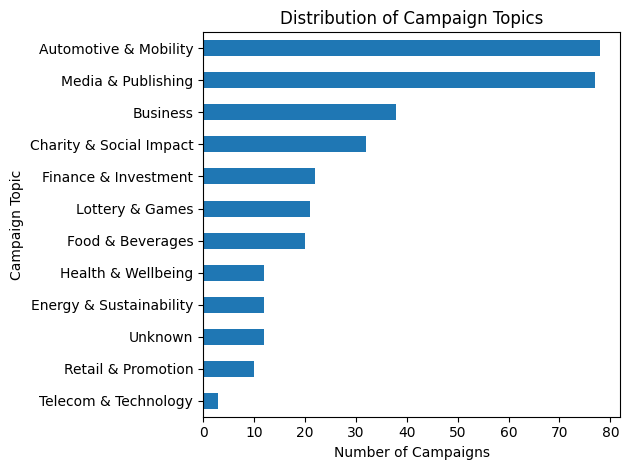

In [500]:
# plot

topic_counts = campaign_topics['main_topic'].value_counts().sort_values()

topic_counts.plot(kind='barh')
plt.title('Distribution of Campaign Topics')
plt.xlabel('Number of Campaigns')
plt.ylabel('Campaign Topic')
plt.tight_layout()
plt.show()

Insights: 

- Automotive & Mobility and Media & Publishing are dominant
- Business and Charity & Social Impact are moderately represented
- Telecom & Technology and Retail & Promotion are relatively rare, may provide limited analytical reliability due to low number of observations
- Campaign distribution is uneven across campaign topics

### Campaign topic - User distribution

In [501]:
campaign_topics.columns

Index(['mailing_id', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'combined_info'],
      dtype='str')

In [502]:
df_final.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='str')

In [503]:
# merge 2 datasets
df_final_topic = df_final.merge(
    campaign_topics[['mailing_id','main_topic']],
    on = 'mailing_id',
    how = 'left'
)

df_final_topic[['mailing_id', 'main_topic', 'open', 'click']].head()

,mailing_id,main_topic,open,click
0,668,Media & Publishing,0.0,0.0
1,692,Media & Publishing,0.0,0.0
2,714,Energy & Sustainability,0.0,0.0
3,733,Lottery & Games,0.0,0.0
4,761,Energy & Sustainability,0.0,0.0


In [504]:
df_final_topic['main_topic'].isna().sum()

np.int64(28850)

In [505]:
df_final_topic[df_final_topic['main_topic'].isna()][
    ['mailing_id', 'mailing_info', 'subject_line', 'preheader']
].drop_duplicates()

,mailing_id,mailing_info,subject_line,preheader
30,1084,NaN,NaN,NaN
108,1207,NaN,NaN,NaN
242,1083,NaN,NaN,NaN


Reveals that 28,850 rows have no topic — meaning those mailing_ids existed in the engagement data but not in campaign_topics. The follow-up investigation shows these come from just 3 mailing IDs (1084, 1207, 1083) that have completely NaN mailing_info, subject_line, and preheader — so there was nothing to classify them from.

Remark
- Some mailing ids appeared in engagement data (dataset 1) but not in campaign data (dataset 2) -> Relabel as missing topics
- Some mailing ids appeared in campaign data (dataset 2) but not in engagement data (dataset 1) -> Include in topic distribution, exclude from engagement performance

In [506]:
# relabel missing mailing id topis
df_final_topic['main_topic'] = df_final_topic['main_topic'].fillna('Missing')

In [507]:
# topic exposure stats
topic_size = (
    df_final_topic.groupby('main_topic').agg({
        'mailing_id': 'nunique',     # number of campaigns
        'user_id': 'count'           # total user exposures
    })
    .rename(columns = {
        'mailing_id': '#campaigns',
        'user_id': '#user_exposures'
    })
)

In [508]:
# average campaign size
topic_size['avg_campaign_size'] = (topic_size['#user_exposures'] / topic_size['#campaigns'])

# sort by average campaign size
topic_size.sort_values('avg_campaign_size', ascending = False)

,#campaigns,#user_exposures,avg_campaign_size
main_topic,,,
Energy & Sustainability,5,58188,11637.600000
Missing,3,28850,9616.666667
Media & Publishing,60,479712,7995.200000
Lottery & Games,19,128094,6741.789474
Charity & Social Impact,25,98333,3933.320000
Automotive & Mobility,66,257994,3909.000000
Retail & Promotion,9,25563,2840.333333
Health & Wellbeing,11,25822,2347.454545
Finance & Investment,17,15722,924.823529


Energy & Sustainability has only 5 campaigns but 58,188 exposures → avg 11,638 recipients per campaign — by far the largest reach
Media & Publishing has the most campaigns (60) with solid reach (~8,000 avg)
Business and Telecom & Technology have many or similar campaign counts but very low average reach (~555-570), suggesting they target small, specific audiences
Automotive & Mobility despite being the most frequent campaign type (66) has a modest avg size of ~3,909

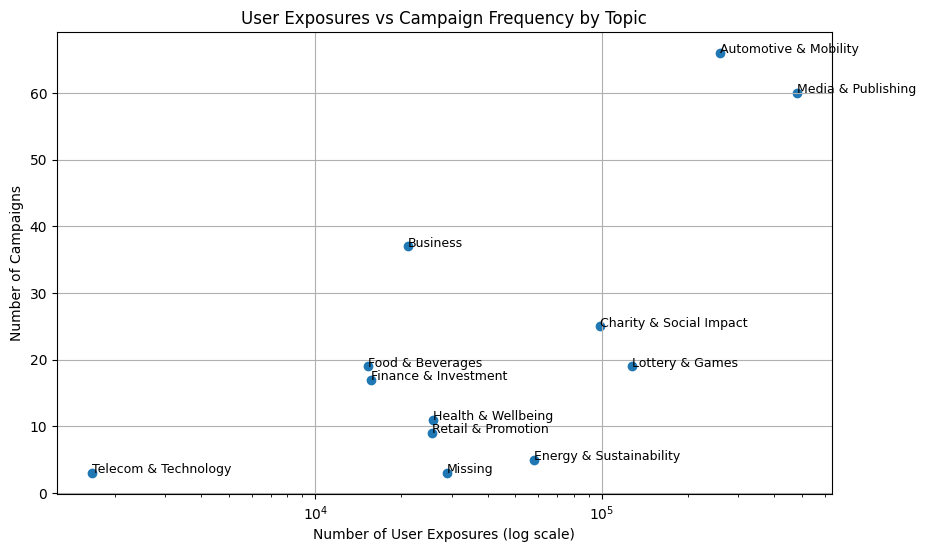

In [509]:
# scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    topic_size['#user_exposures'],
    topic_size['#campaigns'])

# labels
for topic, row in topic_size.iterrows():
    plt.text(
        row['#user_exposures'],
        row['#campaigns'],
        topic,
        fontsize=9)
    
# log scale for x axis
plt.xscale('log')

plt.title('User Exposures vs Campaign Frequency by Topic')
plt.xlabel('Number of User Exposures (log scale)')
plt.ylabel('Number of Campaigns')

plt.grid(True)

plt.show()

Insights
- Media & Publishing: dominates both campaign count and total user exposure -> core campaign topic in OMG
- Energy & Sustainability campaigns: relatively rare, largest average campaign size -> broad targeting strategy
- Business campaigns: high campaign frequency, small average campaign size -> niche/segmented targeting
- Automotive & Mobility: high campaign frequency, high total exposure 

## Topic x Engagement Analysis

#### Unweighted topic x engagement analysis (not account for number of user exposures)

In [510]:
print(df_final_topic['open'].value_counts(dropna = False))
print(df_final_topic['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [511]:
# campaign - open rate and click rate
campaign_performance = (
    df_final_topic.groupby(['mailing_id', 'main_topic']).agg({
        'open': 'mean',
        'click': 'mean'
    }).reset_index())

campaign_performance.head()

,mailing_id,main_topic,open,click
0,653,Finance & Investment,0.699396,0.000000
1,654,Finance & Investment,0.508661,0.001546
2,655,Finance & Investment,0.765385,0.000000
3,668,Media & Publishing,0.491019,0.000630
4,669,Media & Publishing,0.594220,0.000000


In [512]:
# topic - open and click rates
topic_performance = (
    campaign_performance.groupby('main_topic').agg({
        'open': ['mean', 'median'],
        'click': ['mean', 'median'],
        'mailing_id': 'count'
    }))

topic_performance

open               click           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Automotive & Mobility    0.570721  0.575073  0.001909  0.001177         66
Business                 0.486435  0.563460  0.000688  0.000000         37
Charity & Social Impact  0.596531  0.666667  0.028529  0.001010         25
Energy & Sustainability  0.485198  0.522585  0.000698  0.000684          5
Finance & Investment     0.398059  0.434109  0.001474  0.000569         17
Food & Beverages         0.475498  0.526646  0.000060  0.000000         19
Health & Wellbeing       0.502958  0.529412  0.000356  0.000000         11
Lottery & Games          0.560109  0.536790  0.014692  0.000458         19
Media & Publishing       0.546281  0.603324  0.005186  0.000340         60
Missing                  0.499877  0.680187  0.000340  0.000000          3
Retail & Promotion       0.507283  0.665373  0.000931  0.000557          9
Telecom & Technology     0.431894  0.527337  0.000000  0.000000          3

In [513]:
# topics with highest average open rate
topic_performance.sort_values(('open', 'mean'), ascending = False)

open               click           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Charity & Social Impact  0.596531  0.666667  0.028529  0.001010         25
Automotive & Mobility    0.570721  0.575073  0.001909  0.001177         66
Lottery & Games          0.560109  0.536790  0.014692  0.000458         19
Media & Publishing       0.546281  0.603324  0.005186  0.000340         60
Retail & Promotion       0.507283  0.665373  0.000931  0.000557          9
Health & Wellbeing       0.502958  0.529412  0.000356  0.000000         11
Missing                  0.499877  0.680187  0.000340  0.000000          3
Business                 0.486435  0.563460  0.000688  0.000000         37
Energy & Sustainability  0.485198  0.522585  0.000698  0.000684          5
Food & Beverages         0.475498  0.526646  0.000060  0.000000         19
Telecom & Technology     0.431894  0.527337  0.000000  0.000000          3
Finance & Investment     0.398059  0.434109  0.001474  0.000569         17

Insights
- Charity & Social Impact campaigns: highest average open rate (59.65%), highest median open rate (66.67%) -> consistenly attract user attention
- Automotive & Mobility campaigns: high average open rate across a large number of campaigns, mean ~ median (~57%) -> stable performance, consistently relevant to audience
- Media & Publishing campaigns: strong open rate, large number of campaigns -> increase reliability
- Finance & Investment campaigns: lowest average open rates (39.81%) -> low user interst or high informational complexity compared to others
- Topics with small campaign sizes (Telecom & Technology, Missing): unstable -> should not be generalised without additional data

In [514]:
# topics with highest average click rate
topic_performance[['click', 'open', 'mailing_id']].sort_values(('click', 'mean'), ascending = False)

click                open           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Charity & Social Impact  0.028529  0.001010  0.596531  0.666667         25
Lottery & Games          0.014692  0.000458  0.560109  0.536790         19
Media & Publishing       0.005186  0.000340  0.546281  0.603324         60
Automotive & Mobility    0.001909  0.001177  0.570721  0.575073         66
Finance & Investment     0.001474  0.000569  0.398059  0.434109         17
Retail & Promotion       0.000931  0.000557  0.507283  0.665373          9
Energy & Sustainability  0.000698  0.000684  0.485198  0.522585          5
Business                 0.000688  0.000000  0.486435  0.563460         37
Health & Wellbeing       0.000356  0.000000  0.502958  0.529412         11
Missing                  0.000340  0.000000  0.499877  0.680187          3
Food & Beverages         0.000060  0.000000  0.475498  0.526646         19
Telecom & Technology     0.000000  0.000000  0.431894  0.527337          3

Insights
- Charity & Social Impact campaigns: highest average click rate (2.85%) -> good at getting attention (highest open rate) and pushing users to interact
- Lottery & Games campaigns: usually have rewards/interactive hook -> perform well for clicks
- Media & Publishing campaigns: decent click performance, a large number of campaigns -> more reliable results
- Automotive & Mobility campaigns: strong open rates, much lower click rates -> users are curious to open but not motivated further
- Finance & Investment campaigns: lowest open rate, click rate is not lowest -> few people open, but who do open still have some interest
- Topics with small campaign sizes (Telecom & Technology, Missing): unstable -> should not be generalised without additional data

#### Weighted topic x engagement analysis (account for number of user exposures)

In [515]:
# topic - open and click rates (weighted)
weighted_topic_performance = (
    df_final_topic.groupby('main_topic').agg({
        'open': 'mean',
        'click': 'mean',
        'user_id': 'count'})
        .rename(columns = {
            'user_id': "#user_exposures",
            'open': 'open_weighted',
            'click': 'click_weighted'}))

weighted_topic_performance

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Automotive & Mobility,0.597493,0.001675,257994
Business,0.560181,0.001023,21087
Charity & Social Impact,0.489127,0.002620,98333
Energy & Sustainability,0.499381,0.000685,58188
Finance & Investment,0.344169,0.001322,15722
Food & Beverages,0.546255,0.000070,15275
Health & Wellbeing,0.516609,0.000438,25822
Lottery & Games,0.531768,0.000901,128094
Media & Publishing,0.536876,0.000665,479712


In [516]:
# topics with highest average open rate (weighted)
weighted_topic_performance.sort_values('open_weighted', ascending = False)

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Automotive & Mobility,0.597493,0.001675,257994
Business,0.560181,0.001023,21087
Food & Beverages,0.546255,0.000070,15275
Media & Publishing,0.536876,0.000665,479712
Lottery & Games,0.531768,0.000901,128094
Health & Wellbeing,0.516609,0.000438,25822
Energy & Sustainability,0.499381,0.000685,58188
Charity & Social Impact,0.489127,0.002620,98333
Telecom & Technology,0.470963,0.000000,1664


Insights (weighted analysis)
- Automotive & Mobility: top performing campaigns -> strong opens even at large audience scale
- Charity & Social Impact: drop noticeably (despite first ranking in unweighted) -> unweighted performance may come from smaller campaigns
- Business: perform better -> larger business-related campaigns achieve stronger open rates
- Media & Publishing: consistenly strong opens, largest number of users -> stable open behaviour at scale
- Finance & Investment: weakest -> consistenly low open engagement across campaigns and user exposures


In [517]:
# topics with highest average click rate (weighted)
weighted_topic_performance.sort_values('click_weighted', ascending = False)

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Charity & Social Impact,0.489127,0.002620,98333
Automotive & Mobility,0.597493,0.001675,257994
Finance & Investment,0.344169,0.001322,15722
Business,0.560181,0.001023,21087
Lottery & Games,0.531768,0.000901,128094
Retail & Promotion,0.461394,0.000772,25563
Energy & Sustainability,0.499381,0.000685,58188
Media & Publishing,0.536876,0.000665,479712
Missing,0.367773,0.000544,28850


Insights (weighted analysis)
- Finance & Investment: higher click ranking -> larger finance-related campaigns generate strong clicks
- Charity & Social Impact: still highest clicks -> scale relatively well across larger audience exposures
- Media & Publishing: drops noticeably, extremely large exposure -> broad audience not necessarily translate into strong clicks
- Automotive & Mobility: remains strong -> stable performance at scale
- Food & Beverages: weak clicks, moderate opens -> no further action after opening

## Topic x User Analysis (Engagement segmentation Analysis)

In [518]:
# merge topic dataset and user dataset
df_final_topic = df_final_topic.merge(
    df_user_clean[['user_id', 'open_segment', 'click_segment']],
    on = 'user_id',
    how = 'left')

df_final_topic[['user_id', 'main_topic', 'open_segment', 'click_segment']].head()

,user_id,main_topic,open_segment,click_segment
0,5cb9a38136dd1336b9c528d1,Media & Publishing,low_open,no_click
1,5cb9a38136dd1336b9c528d1,Media & Publishing,low_open,no_click
2,5cb9a38136dd1336b9c528d1,Energy & Sustainability,low_open,no_click
3,5cb9a38136dd1336b9c528d1,Lottery & Games,low_open,no_click
4,5cb9a38136dd1336b9c528d1,Energy & Sustainability,low_open,no_click


In [519]:
# topic distribution by opens
topic_open_segment = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['open_segment'],
    normalize = 'columns')

# difference between high and low open column
topic_open_segment['open_difference'] = (topic_open_segment['high_open'] - topic_open_segment['low_open'])

# sort by difference
topic_open_segment.reindex(topic_open_segment['open_difference'].abs().sort_values(ascending = False).index)

open_segment,high_open,low_open,open_difference
main_topic,,,
Automotive & Mobility,0.248714,0.216269,0.032445
Charity & Social Impact,0.076541,0.090652,-0.014111
Energy & Sustainability,0.043613,0.053972,-0.010358
Lottery & Games,0.102460,0.112816,-0.010356
Media & Publishing,0.417995,0.408146,0.009849
Finance & Investment,0.009477,0.016245,-0.006768
Missing,0.025784,0.024811,0.000973
Telecom & Technology,0.000861,0.001596,-0.000735
Business,0.017368,0.018042,-0.000674


Insights
- Automotive & Mobility: largest positive difference (3.24%) -> appear relatively more among high-open users
- Media & Publishing: small positive difference -> associciate slightly stronger with high-open users
- Charity & Social Impact, Energy & Sustainability, Lottery & Games: appear relatively more among low-open users (differences not large though)
- Differences across topics are relatively modest -> user open behaviour may depend more on other factors

In [520]:
# topic distribution by clicks
topic_click_segment = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['click_segment'],
    normalize = 'columns')

# difference between high and low open column
topic_click_segment['click_difference'] = (topic_click_segment['click'] - topic_click_segment['no_click'])

# sort by strongest difference
topic_click_segment.reindex(topic_click_segment['click_difference'].abs().sort_values(ascending = False).index)

click_segment,click,no_click,click_difference
main_topic,,,
Media & Publishing,0.377422,0.413457,-0.036035
Automotive & Mobility,0.258391,0.232107,0.026284
Lottery & Games,0.093945,0.107823,-0.013879
Charity & Social Impact,0.096021,0.083489,0.012531
Finance & Investment,0.024913,0.012740,0.012174
Business,0.025433,0.017617,0.007815
Health & Wellbeing,0.015052,0.022600,-0.007548
Retail & Promotion,0.017993,0.021903,-0.003910
Food & Beverages,0.015138,0.012923,0.002216


Insights
- Media & Publishing: strongly represent low-click users (-3.6%) -> achieve good opens, but may not convert into deeper engagement
- Automotive & Mobility: strong positive difference (2.6%) -> users more likely to click after opening
- Charity & Social Impact and Finance & Investment: positive click differencess -> drive more clicking
- Lottery & Games: decent open behaviour but worse in click behaviour -> curiosity-driven opens but weaker post-open engagement
- Compared to open bahaviour, topic differences are more pronounced for click behaviour -> campaign topic may have stronger influence on clicks

## Topic x Gender Analysis

### Topic distribution by gender

In [521]:
# topic distribution by gender
topic_gender = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['gender'],
    normalize = 'columns')

In [522]:
# male vs female difference
topic_gender['distribution_difference'] = (topic_gender['female'] - topic_gender['male'])

# sort by strongest difference
topic_gender = topic_gender.reindex(topic_gender['distribution_difference'].abs().sort_values(ascending = False).index)

topic_gender

gender,female,male,other,distribution_difference
main_topic,,,,
Automotive & Mobility,0.209713,0.242640,0.172489,-0.032927
Lottery & Games,0.115163,0.104400,0.127229,0.010763
Health & Wellbeing,0.026217,0.017452,0.019469,0.008765
Media & Publishing,0.417920,0.409508,0.446961,0.008412
Food & Beverages,0.014051,0.011999,0.016103,0.002052
Energy & Sustainability,0.050971,0.049344,0.053539,0.001627
Charity & Social Impact,0.085431,0.084349,0.089292,0.001082
Business,0.017889,0.018842,0.014693,-0.000954
Finance & Investment,0.013879,0.013389,0.010098,0.000490


Insights
- Automotive & Mobility: strongest gender distribution imbalance, male users receieve more than female
- Lottery & Games, Health & Wellbeing, Media & Publishing: slightly more represented among female
- Most remaining topics: relatively balanced gender distribution

### Topic x Gender Engagement Analysis

In [523]:
df_final_topic['gender'].value_counts(dropna = False)

gender
female    638677
male      495643
other      21984
Name: count, dtype: int64

In [524]:
# engagement rates by topic and gender
topic_gender_engagement = (df_final_topic.groupby(['main_topic', 'gender']).agg({
    'open': 'mean',
    'click': 'mean'}).reset_index())

topic_gender_engagement.head(6)

,main_topic,gender,open,click
0,Automotive & Mobility,female,0.591518,0.001125
1,Automotive & Mobility,male,0.604095,0.002325
2,Automotive & Mobility,other,0.598853,0.000836
3,Business,female,0.571058,0.000752
4,Business,male,0.547780,0.001394
5,Business,other,0.536667,0.000000


In [525]:
# pivot open rate
topic_gender_open = topic_gender_engagement.pivot(
    index = 'main_topic',
    columns = 'gender',
    values = 'open')

topic_gender_open

gender,female,male,other
main_topic,,,
Automotive & Mobility,0.591518,0.604095,0.598853
Business,0.571058,0.547780,0.536667
Charity & Social Impact,0.494977,0.480299,0.512577
Energy & Sustainability,0.506719,0.488758,0.515123
Finance & Investment,0.353089,0.332782,0.333333
Food & Beverages,0.560779,0.519143,0.633136
Health & Wellbeing,0.524900,0.498516,0.553525
Lottery & Games,0.538711,0.520468,0.554183
Media & Publishing,0.538215,0.534073,0.557865


In [526]:
# female vs male difference
topic_gender_open['open_difference'] = (topic_gender_open['female'] - topic_gender_open['male'])

# sort by strongest difference
topic_gender_open = topic_gender_open.reindex(topic_gender_open['open_difference'].abs().sort_values(ascending = False).index)

topic_gender_open

gender,female,male,other,open_difference
main_topic,,,,
Telecom & Technology,0.509918,0.414634,0.318182,0.095284
Food & Beverages,0.560779,0.519143,0.633136,0.041636
Health & Wellbeing,0.524900,0.498516,0.553525,0.026384
Business,0.571058,0.547780,0.536667,0.023278
Finance & Investment,0.353089,0.332782,0.333333,0.020307
Lottery & Games,0.538711,0.520468,0.554183,0.018243
Energy & Sustainability,0.506719,0.488758,0.515123,0.017960
Charity & Social Impact,0.494977,0.480299,0.512577,0.014678
Automotive & Mobility,0.591518,0.604095,0.598853,-0.012577


Insights
- Female users shows slightly higher open rates across most topics
- Largest gender gap in Telecom & Technology (female > male), but a small number of user exposures -> should be interpreted cautiously
- Food & Beverages and Health & Wellbeing: moderately stronger open rates among female
- Automotive & Mobility: one of the few where male outperform female
- Most gaps remain small -> open behaviour is broadly similar across genders

In [527]:
# pivot click rate
topic_gender_click = topic_gender_engagement.pivot(
    index = 'main_topic',
    columns = 'gender',
    values = 'click')

topic_gender_click

gender,female,male,other
main_topic,,,
Automotive & Mobility,0.001125,0.002325,0.000836
Business,0.000752,0.001394,0.000000
Charity & Social Impact,0.002584,0.002794,0.000000
Energy & Sustainability,0.000319,0.001213,0.000000
Finance & Investment,0.000737,0.002157,0.000000
Food & Beverages,0.000119,0.000000,0.000000
Health & Wellbeing,0.000000,0.001312,0.000000
Lottery & Games,0.000927,0.000914,0.000000
Media & Publishing,0.000485,0.000937,0.000000


In [528]:
# female vs male difference
topic_gender_click['click_difference'] = (topic_gender_click['female'] - topic_gender_click['male'])

# sort by strongest difference
topic_gender_click = topic_gender_click.reindex(topic_gender_click['click_difference'].abs().sort_values(ascending = False).index)

topic_gender_click

gender,female,male,other,click_difference
main_topic,,,,
Finance & Investment,0.000737,0.002157,0.000000,-0.001420
Health & Wellbeing,0.000000,0.001312,0.000000,-0.001312
Automotive & Mobility,0.001125,0.002325,0.000836,-0.001200
Retail & Promotion,0.000291,0.001445,0.000000,-0.001155
Energy & Sustainability,0.000319,0.001213,0.000000,-0.000894
Missing,0.000196,0.001025,0.000000,-0.000830
Business,0.000752,0.001394,0.000000,-0.000641
Media & Publishing,0.000485,0.000937,0.000000,-0.000452
Charity & Social Impact,0.002584,0.002794,0.000000,-0.000210


Insights
- Male users show higher click rates across most topics, despite female users often show higher open rates
- Finance & Investment, Health & Wellbeing, Automotive & Mobility: strong male click advantages
- Male users may be more likely to click after opening for certain topics
- Food & Beverages shows higher click rate among female (though difference is small)
- Low click rates across all topics -> Modest gender differences in click behaviour

## Topic x Age Analysis

In [529]:
# keep realistic ages only (18-90)
df_age = df_final_topic[
    (df_final_topic['age'] >= 18) &
    (df_final_topic['age'] <= 90)].copy()

# create age groups
df_age['age_group'] = pd.cut(
    df_age['age'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

In [530]:
# remove missing age
df_age = df_age.dropna(subset = ['age'])

In [531]:
df_age['age_group'].value_counts(normalize = True)

age_group
35-50    0.313810
50-65    0.309111
65+      0.242390
18-35    0.134690
Name: proportion, dtype: float64

Insight
- Dataset is skewed toward older users
- Users aged 35-65 make up ~62% of population
- Users aged 18-35 account for ~ 13%

### Topic distribution by age group

In [532]:
# topic distribution by age group
topic_age = pd.crosstab(
    df_age['main_topic'],
    df_age['age_group'],
    normalize = 'columns')

topic_age

age_group,18-35,35-50,50-65,65+
main_topic,,,,
Automotive & Mobility,0.173763,0.208585,0.235611,0.255292
Business,0.020487,0.021951,0.018792,0.017772
Charity & Social Impact,0.070527,0.081589,0.090425,0.093090
Energy & Sustainability,0.048312,0.050953,0.055973,0.056377
Finance & Investment,0.011621,0.014179,0.016882,0.019999
Food & Beverages,0.014651,0.014985,0.012976,0.014014
Health & Wellbeing,0.067647,0.035237,0.022808,0.004746
Lottery & Games,0.117361,0.114741,0.110374,0.108121
Media & Publishing,0.424840,0.411579,0.391154,0.385332


Insights
- Automotive & Mobility, Finance & Investment: more represented in older age groups -> targeted more heavily toward older users
- Media & Publishing, Health & Wellbeing: decling representation with age -> stronger exposure among younger users
- Most other topics: stable distributions acros age groups

### Topic x Age Engagement Analysis

In [533]:
# engagement rates by topic, age groups
topic_age_engagement = (
    df_age.groupby(['main_topic', 'age_group']).agg({
        'open': 'mean',
        'click': 'mean'}).reset_index())

topic_age_engagement.head(8)

,main_topic,age_group,open,click
0,Automotive & Mobility,18-35,0.723407,0.000000
1,Automotive & Mobility,35-50,0.637627,0.000315
2,Automotive & Mobility,50-65,0.528101,0.001749
3,Automotive & Mobility,65+,0.476526,0.003154
4,Business,18-35,0.692994,0.000000
5,Business,35-50,0.574074,0.000000
6,Business,50-65,0.465179,0.000000
7,Business,65+,0.454294,0.000000


In [534]:
# pivot open rate
topic_age_open = topic_age_engagement.pivot(
    index = 'main_topic',
    columns = 'age_group',
    values = 'open')

In [535]:
# youngest vs oldest open rate difference
topic_age_open['open_difference'] = (topic_age_open['18-35'] - topic_age_open['65+'])

# sort by strongest difference
topic_age_open = topic_age_open.reindex(topic_age_open['open_difference'].abs().sort_values(ascending = False).index)

topic_age_open

age_group,18-35,35-50,50-65,65+,open_difference
main_topic,,,,,
Telecom & Technology,0.833333,0.505263,0.435897,0.348993,0.484340
Food & Beverages,0.680070,0.560720,0.507605,0.404332,0.275738
Automotive & Mobility,0.723407,0.637627,0.528101,0.476526,0.246881
Business,0.692994,0.574074,0.465179,0.454294,0.238700
Media & Publishing,0.614279,0.560039,0.456307,0.416060,0.198219
Energy & Sustainability,0.609323,0.571157,0.415458,0.412907,0.196416
Lottery & Games,0.618385,0.572320,0.453154,0.423135,0.195250
Charity & Social Impact,0.588676,0.549281,0.416816,0.403581,0.185096
Health & Wellbeing,0.614632,0.517607,0.361466,0.450000,0.164632


Insights
- Open rates generally decline with age across most topics
- Telecom & Technology: strongest age difference (~48%)
- Food & Beverages, Automotive & Mobility, Business: substantial age differences (>20%)
- Retail & Promotion: stable across age groups
- Certain campaign topics may resonate more strongly with younger audiences (technology-related, consumer-focused)
- However, some topics (eg. Telecom & Technology) contained few campaigns and user exposures -> interpreted cautiously

In [536]:
# pivot click rate
topic_age_click = topic_age_engagement.pivot(
    index = 'main_topic',
    columns = 'age_group',
    values = 'click')

In [537]:
# youngest vs oldest click rate difference
topic_age_click['click_difference'] = (topic_age_click['18-35'] - topic_age_click['65+'])

# sort by strongest difference
topic_age_click = topic_age_click.reindex(topic_age_click['click_difference'].abs().sort_values(ascending = False).index)

topic_age_click

age_group,18-35,35-50,50-65,65+,click_difference
main_topic,,,,,
Finance & Investment,0.0,0.000000,0.000000,0.010187,-0.010187
Charity & Social Impact,0.0,0.000000,0.004825,0.009637,-0.009637
Automotive & Mobility,0.0,0.000315,0.001749,0.003154,-0.003154
Lottery & Games,0.0,0.000000,0.001235,0.003132,-0.003132
Energy & Sustainability,0.0,0.000000,0.000816,0.001943,-0.001943
Media & Publishing,0.0,0.000000,0.001338,0.001372,-0.001372
Missing,0.0,0.000000,0.000452,0.001198,-0.001198
Retail & Promotion,0.0,0.000000,0.003213,0.000957,-0.000957
Business,0.0,0.000000,0.000000,0.000000,0.000000


Insights
- Click behaviour increases with age (unlike open)
- 18-35 group generated no recorded clicks
- Click rates rise progressively across older age groups
- Click activity is extremely sparse overall -> click-based age patterns should be interpreted cautiously

In [538]:
print(df_age.groupby('age_group')['click'].sum())
print('\n', df_age.groupby('age_group')['click'].mean())

age_group
18-35      0.0
35-50     12.0
50-65    142.0
65+      186.0
Name: click, dtype: float64

 age_group
18-35    0.000000
35-50    0.000132
50-65    0.001621
65+      0.002924
Name: click, dtype: float64


## Interest relevance analysis

In [539]:
df_final_topic.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment'],
      dtype='str')

In [540]:
df_final_topic.head()

,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader,main_topic,open_segment,click_segment
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen.",Media & Publishing,low_open,no_click
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v...",Media & Publishing,low_open,no_click
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.,Energy & Sustainability,low_open,no_click
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...,Lottery & Games,low_open,no_click
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95.",Energy & Sustainability,low_open,no_click


In [541]:
# interests dictionary
interest_topic_map = {
    # automotive
    'auto': 'Automotive & Mobility',
    'cx80': 'Automotive & Mobility',
    'auto inruilen': 'Automotive & Mobility',
    'mazda': 'Automotive & Mobility',
    'elektrisch': 'Automotive & Mobility',
    'audi': 'Automotive & Mobility',
    'mazda6e': 'Automotive & Mobility',
    'dacia': 'Automotive & Mobility',
    'hybrid': 'Automotive & Mobility',
    'mercedes': 'Automotive & Mobility',
    'toyota': 'Automotive & Mobility',
    'lease': 'Automotive & Mobility',
    'cx60': 'Automotive & Mobility',
    'cx5': 'Automotive & Mobility',
    'mx30': 'Automotive & Mobility',
    'cx30': 'Automotive & Mobility',
    'hyundai': 'Automotive & Mobility',
    'bedrijfswagen': 'Automotive & Mobility',
    'porsche': 'Automotive & Mobility',


    # business
    'mkb': 'Business',
    'ondernemers': 'Business',
    'zakelijk rijden': 'Business',
    'hr': 'Business',
    'bedrijven': 'Business',
    'zzp': 'Business',

    # charity
    'goededoelen': 'Charity & Social Impact',

    # energy
    'energie': 'Energy & Sustainability',

    # finance
    'verzekering': 'Finance & Investment',
    'bank': 'Finance & Investment',
    'beleggen': 'Finance & Investment',
    'finance': 'Finance & Investment',
    'hypotheek': 'Finance & Investment',
    'centraal beheer': 'Finance & Investment',
    'belastingdienst': 'Finance & Investment',

    # food
    'bezorgmaaltijden': 'Food & Beverages',
    'horeca': 'Food & Beverages',

    # health
    'zorg': 'Health & Wellbeing',

    # lottery
    'kansspelen': 'Lottery & Games',
    'loterij': 'Lottery & Games',
    'winactie': 'Lottery & Games',

    # media
    'bladen': 'Media & Publishing',
    'kranten': 'Media & Publishing',
    'entertainment': 'Media & Publishing',
    'onderzoek': 'Media & Publishing',

    # retail
    'cadeau': 'Retail & Promotion',
    'acties': 'Retail & Promotion',
    'kortingen': 'Retail & Promotion',

    # tech
    'windows': 'Telecom & Technology',
    'it': 'Telecom & Technology',
    'telcom': 'Telecom & Technology',
    'ios': 'Telecom & Technology',
    'android': 'Telecom & Technology',
    'linux': 'Telecom & Technology',
    'chrome os': 'Telecom & Technology',
    'mac os': 'Telecom & Technology',
    'os x': 'Telecom & Technology',


    #other
    'bigevent': 'Other',
    'wetgeving': 'Other',
    'overheid': 'Other',

    #unknown
    'unknown': 'Unknown'
}

In [542]:
# function to map interest
def map_interest(x):

    # missing values
    if pd.isna(x):
        return 'Missing'
    
    # mapped interest
    return interest_topic_map.get(x, 'Other')


In [543]:
# apply mapping to interests dataset
df_interests['mapped_interest_topic'] = df_interests['interests'].apply(map_interest)

df_interests[[ 'interests', 'mapped_interest_topic']].head()

,interests,mapped_interest_topic
0,auto,Automotive & Mobility
0,loterij,Lottery & Games
0,kranten,Media & Publishing
0,entertainment,Media & Publishing
0,winactie,Lottery & Games


In [544]:
df_interests['mapped_interest_topic'].value_counts(normalize = True)

mapped_interest_topic
Automotive & Mobility      0.312437
Media & Publishing         0.151085
Retail & Promotion         0.132866
Lottery & Games            0.086696
Finance & Investment       0.084470
Business                   0.075345
Energy & Sustainability    0.042083
Charity & Social Impact    0.038892
Unknown                    0.030886
Other                      0.023634
Telecom & Technology       0.015039
Food & Beverages           0.005387
Health & Wellbeing         0.001117
Missing                    0.000062
Name: proportion, dtype: float64

In [545]:
# groupby user id, each user with a list of mapped topics
user_interest_topics = (df_interests.groupby('user_id')['mapped_interest_topic'].apply(list).reset_index())

# merge mapped user interests into final topic dataset
df_final_topic = df_final_topic.merge(
    user_interest_topics,
    on = 'user_id',
    how = 'left')

In [546]:
df_final_topic['mapped_interest_topic'].head()

0    [Energy & Sustainability, Lottery & Games, Med...
1    [Energy & Sustainability, Lottery & Games, Med...
2    [Energy & Sustainability, Lottery & Games, Med...
3    [Energy & Sustainability, Lottery & Games, Med...
4    [Energy & Sustainability, Lottery & Games, Med...
Name: mapped_interest_topic, dtype: object

In [547]:
# match campaigns with interests function, 1 if campaign topic in user interests, 0 otherwise
def check_interest_match(row):
    interests = row['mapped_interest_topic']

    if not isinstance(interests, list):
        return 0
    
    return 1 if row['main_topic'] in interests else 0

df_final_topic['interest_topic_match'] = df_final_topic.apply(check_interest_match, axis = 1)

In [548]:
df_final_topic['interest_topic_match'].value_counts(normalize=True)

interest_topic_match
1    0.806709
0    0.193291
Name: proportion, dtype: float64

80.7% of interactions are matches, meaning most campaigns are sent to users who have a declared interest in that topic. Only 19.3% are mismatches.

In [549]:
# engagement rate on interest match
df_final_topic.groupby('interest_topic_match')[['open', 'click']].mean()

,open,click
interest_topic_match,,
0,0.351875,0.001073
1,0.560827,0.001084


Insights
- Campaigns whose topics aligned with user interests achieved substantially higher open rates -> topic alignment strongly influences whether users open email
- Click rates remained almost identical (~0.11%) -> interest alignment may encourage users to open emails, but not translate click behaviour

## Subject line & Preheader Analysis

### Subject line Analysis

In [550]:
df_content = df_final_topic.copy()

In [551]:
df_content.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment', 'mapped_interest_topic',
       'interest_topic_match'],
      dtype='str')

#### Length

In [552]:
df_subject = df_content.copy()

# remove missing subject lines
df_subject = df_subject[df_subject['subject_line'].notna()]

# remove empty strings
df_subject = df_subject[df_subject['subject_line'].str.strip() != '']

In [553]:
# length of subject lines
df_subject['subject_length'] = (df_subject['subject_line'].str.len())

In [554]:
df_subject['subject_length'].describe()

count    1.127454e+06
mean     4.512420e+01
std      8.856277e+00
min      2.300000e+01
25%      3.900000e+01
50%      4.400000e+01
75%      4.900000e+01
max      9.300000e+01
Name: subject_length, dtype: float64

Insights
- No suspiciously short subject lines (min = 23)
- Campaigns centered around medium-length subjects (median = 44)
- Most subjects under 50 characters (75th quantile = 49)
- Some long subjects but not absurb (max = 93)

In [555]:
# create length buckets
df_subject['subject_length_group'] = pd.cut(
    df_subject['subject_length'],
    bins = [0, 35, 45, 55, 100],
    labels = ['short', 'medium', 'long', 'very_long'])

In [556]:
# engagement rates based on length
df_subject.groupby('subject_length_group')[['open', 'click']].mean()

,open,click
subject_length_group,,
short,0.360696,0.001234
medium,0.573273,0.001194
long,0.541186,0.000805
very_long,0.574964,0.001387


In [557]:
df_subject['subject_length_group'].value_counts(normalize = True)

subject_length_group
medium       0.445663
long         0.323267
very_long    0.121018
short        0.110051
Name: proportion, dtype: float64

Insights
- Short subject lines (< 35 characters) achieved low open rate (~36%)
- Medium, long, very long subject lones all performed better (~54-57% open rate)
-> Short subject lines may provide insufficient info or value to encourage users to open email
- Click rates show smaller differences across different length groups (compared to open rates)
- Very long subject lines achieved highest click rate
-> Subject line length influence open behaviour more strongly than click behaviour

#### Contain numbers?

Remark

Numerical elements does not distinguish between promotional numbers (eg. discounts) and product/model identifiers (eg. Mazda CX80) -> observed effect may reflect multiple underlying mechanisms

In [558]:
# check if contain numbers
df_subject['subject_contains_number'] = (df_subject['subject_line'].str.contains(r'\d', regex = True))

In [559]:
# engagement rate
df_subject.groupby('subject_contains_number')[['open', 'click']].mean()

,open,click
subject_contains_number,,
False,0.534092,0.001160
True,0.546353,0.001039


In [560]:
df_subject['subject_contains_number'].value_counts(normalize = True)

subject_contains_number
True     0.525961
False    0.474039
Name: proportion, dtype: float64

Insights
- Campaigns contain numbers in subject lines achieved slight higher open rate, but lower open rate -> numeric info may help attract user attention, but not necessarily translate into stronger engagement
- Campaigns contain numbers represented a slight majority of dataset -> numeric elements are common in subject lines

#### Contain exclamation marks?

In [561]:
# check if contain exclamation marks
df_subject['subject_contains_exclamation'] = (df_subject['subject_line'].str.contains('!', regex = False))

In [562]:
# engagement rate
df_subject.groupby('subject_contains_exclamation')[['open', 'click']].mean()

,open,click
subject_contains_exclamation,,
False,0.536614,0.001182
True,0.561049,0.000656


In [563]:
df_subject['subject_contains_exclamation'].value_counts(normalize = True)

subject_contains_exclamation
False    0.837923
True     0.162077
Name: proportion, dtype: float64

Insights
- Campaigns contain exclamation marks achieved slightly higher open rate -> exclamation marks may help increase visibility or attract user attention
- Campaigns contain exclamation marks showed a substantially lower click rate -> exclamation marks may not effectively translate into click behaviour
- Only around 16.2% campaigns contained exclamation marks -> used selective rather than as a dominant strategy

#### Contain promotional words?

Remark

Promotion feature was constructed using a predefined keyword list and may not capture all forms of promotional content

In [564]:
promotion_words = [
    'korting',
    'gratis',
    'cadeau',
    'aanbieding',
    'deal',
    'voordeel',
    'win',
    'actie',
    'bonus',
    'besparen'
]

In [565]:
# check if contain promotion words
promotion_pattern = '|'.join(promotion_words)

df_subject['subject_contains_promotion'] = (df_subject['subject_line'].str.lower().str.contains(promotion_pattern, regex = True))

In [566]:
# engagement rate
df_subject.groupby('subject_contains_promotion')[['open', 'click']].mean()

,open,click
subject_contains_promotion,,
False,0.538188,0.001100
True,0.557954,0.001065


In [567]:
df_subject['subject_contains_promotion'].value_counts(normalize = True)

subject_contains_promotion
False    0.879899
True     0.120101
Name: proportion, dtype: float64

Insights
- Campaign contain promotional languages achieved a slightly higher open rate -> promotional wording may help attract initial user attention
- Campaign contain promotional languages showed lower click rate -> promotional wording may not translate into stronger clicks
- 12% campaigns contained promotional keywords -> used selectively

### Preheader Analysis

In [568]:
df_preheader = df_final_topic.copy()

# remove missing values
df_preheader = df_preheader[df_preheader['preheader'].notna()]

# remove empty string
df_preheader = df_preheader[df_preheader['preheader'].str.strip() != '']

#### Length

In [569]:
# length of preheader
df_preheader['preheader_length'] = (df_preheader['preheader'].str.len())

In [570]:
df_preheader['preheader_length'].describe()

count    1.121945e+06
mean     5.746832e+01
std      1.139753e+01
min      2.900000e+01
25%      5.000000e+01
50%      5.700000e+01
75%      6.400000e+01
max      9.300000e+01
Name: preheader_length, dtype: float64

In [571]:
# create length buckets
df_preheader['preheader_length_group'] = pd.cut(
    df_preheader['preheader_length'],
    bins =[0, 45, 55, 65, 100],
    labels = ['short', 'medium', 'long', 'very_long'])

In [572]:
# engagement rate based on length
df_preheader.groupby('preheader_length_group')[['open', 'click']].mean()

,open,click
preheader_length_group,,
short,0.566241,0.001140
medium,0.538179,0.000876
long,0.527130,0.001234
very_long,0.556577,0.001118


In [573]:
df_preheader['preheader_length_group'].value_counts(normalize = True)

preheader_length_group
long         0.361977
medium       0.302961
very_long    0.177919
short        0.157143
Name: proportion, dtype: float64

Insights
- Preheader length showed relatively limited variation in engagement rates (compared to subject line length)
- Open rates across all length groups remained similar (~52-57%)
-> Preheader length alone may not strongly influence user engagement behaviour -> preheaders support contextual text rather than drive attention
- Click rates show small differences across length groups

#### Contain numbers?

In [574]:
# check if contain numbers
df_preheader['preheader_contains_number'] = (df_subject['preheader'].str.contains(r'\d', regex = True))

In [575]:
# engagement rate
df_preheader.groupby('preheader_contains_number')[['open', 'click']].mean()

,open,click
preheader_contains_number,,
False,0.510882,0.001023
True,0.574823,0.001161


In [576]:
df_preheader['preheader_contains_number'].value_counts(normalize = True)

preheader_contains_number
False    0.515063
True     0.484937
Name: proportion, dtype: float64

Insights
- Campaigns contain numbers in preheader achieved higher engagement across both metrics -> positive relationship with opens and clicks
- Numeric info may help reinforce the perceived value of email content after users view inbox preview
- Preheader with numeric info are common but not dominant

#### Contain exclamation marks?

In [577]:
# check if contain exclamation marks
df_preheader['preheader_contains_exclamation'] = (df_preheader['preheader'].str.contains('!', regex = False))

In [578]:
# engagement rate
df_preheader.groupby('preheader_contains_exclamation')[['open', 'click']].mean()

,open,click
preheader_contains_exclamation,,
False,0.539214,0.001065
True,0.616961,0.001790


In [579]:
df_preheader['preheader_contains_exclamation'].value_counts(normalize = True)

preheader_contains_exclamation
False    0.9652
True     0.0348
Name: proportion, dtype: float64

Insights
- Campaigns contain exclamation marks achieved substantially higher engagement across both metrics -> exclamation marks may be more effective when used within preheader
- Only around 3.5% campaigns contained exclamation marks -> observed relationship should be interpreted cautiously

#### Contain promotional words?

In [580]:
# check if contain promotion words
df_preheader['preheader_contains_promotion'] = (df_preheader['preheader'].str.lower().str.contains(promotion_pattern, regex = True))

In [581]:
# engagement rate
df_preheader.groupby('preheader_contains_promotion')[['open', 'click']].mean()

,open,click
preheader_contains_promotion,,
False,0.538347,0.001049
True,0.553689,0.001223


In [582]:
df_preheader['preheader_contains_promotion'].value_counts(normalize = True)

preheader_contains_promotion
False    0.763013
True     0.236987
Name: proportion, dtype: float64

Insights
- Campaigns contain promotional language achieved higher engagement across both metrics -> positive relationship with opens and clicks
- ~24% campaigns contained promotional wording -> relatively common

## Historical engagement

In [583]:
# sort mailing id by timeline (proxy)
df_history = df_final_topic.sort_values(['user_id', 'mailing_id']).copy()

In [584]:
# past cummulative opens (how many opens before this email?)
df_history['past_opens'] = (df_history.groupby('user_id')['open'].cumsum() - df_history['open'])

# past cummulative clicks (how many clicks before this email?)
df_history['past_clicks'] = (df_history.groupby('user_id')['click'].cumsum() - df_history['click'])

# cummulative email received before current email
df_history['emails_before'] = (df_history.groupby('user_id').cumcount())

In [585]:
# past open rate (average open rate for all email received before current one)
df_history['past_open_rate'] = (df_history['past_opens']/df_history['emails_before'])

# past click rate (average click rate for all email received before current one)
df_history['past_click_rate'] = (df_history['past_clicks']/df_history['emails_before'])

In [586]:
df_history[['user_id', 'emails_before', 'past_opens', 'past_clicks', 'past_open_rate', 'past_click_rate']].head()

,user_id,emails_before,past_opens,past_clicks,past_open_rate,past_click_rate
349935,5c6bebde5798a794283224c9,0,0.0,0.0,NaN,NaN
349936,5c6bebde5798a794283224c9,1,0.0,0.0,0.0,0.0
349937,5c6bebde5798a794283224c9,2,0.0,0.0,0.0,0.0
349938,5c6bebde5798a794283224c9,3,0.0,0.0,0.0,0.0
349939,5c6bebde5798a794283224c9,4,0.0,0.0,0.0,0.0


In [587]:
df_history['past_open_rate'].describe()

count    1.039581e+06
mean     5.558329e-01
std      3.447998e-01
min      0.000000e+00
25%      2.352941e-01
50%      6.000000e-01
75%      8.888889e-01
max      1.000000e+00
Name: past_open_rate, dtype: float64

In [588]:
print(df_history['past_click_rate'].describe())
print('\n', df_history['past_click_rate'].quantile([0.9, 0.95, 0.99, 0.999]))

count    1.085029e+06
mean     1.438988e-03
std      2.447888e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: past_click_rate, dtype: float64

 0.900    0.000000
0.950    0.000000
0.990    0.000000
0.999    0.384615
Name: past_click_rate, dtype: float64


Remark

Historical engagement estimates are less stable for users with limited piror exposure

### Historical opens

In [589]:
# create buckets for past open rate
df_history['past_open_bucket'] = pd.cut(
    df_history['past_open_rate'],
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1],
    labels = [
        'very_low',
        'low',
        'medium',
        'high',
        'very_high'], include_lowest = True)

In [590]:
df_history['past_open_bucket'].value_counts(normalize = True)

past_open_bucket
very_high    0.340795
very_low     0.228470
high         0.156007
low          0.141542
medium       0.133186
Name: proportion, dtype: float64

In [591]:
# compare past open rates with current engagement rates
df_history.groupby('past_open_bucket')[['open', 'click']].mean()

,open,click
past_open_bucket,,
very_low,0.153234,0.001370
low,0.344941,0.001132
medium,0.499314,0.000809
high,0.635255,0.000887
very_high,0.841122,0.000997


In [592]:
# emails received before by each bucket
df_history.groupby('past_open_bucket')['emails_before'].mean()

past_open_bucket
very_low     28.828691
low          36.857351
medium       36.894076
high         36.818679
very_high    31.540812
Name: emails_before, dtype: float64

Insights
- Users with strong historical opens are substantially more likely to open future campaigns (this relationship is almost perfectly monotonic)
- Email open behaviour is persistent over time
- very_high users open more than 5 times as often as very_low users
- Historial open behaviour strongly influence future opens, but not necessarily influence future clicks
- Open buckets are not purely driven by exposure volume

### Historical clicks

In [593]:
# create binary groups for past click rates
df_history['clicked_before'] = (df_history['past_click_rate'] > 0)

In [594]:
df_history['clicked_before'].value_counts(normalize = True)

clicked_before
False    0.992415
True     0.007585
Name: proportion, dtype: float64

In [595]:
# compare past click rates with current engagement rates
df_history.groupby('clicked_before')[['open', 'click']].mean()

,open,click
clicked_before,,
False,0.537601,0.000177
True,0.355515,0.114126


In [596]:
# emails received before by each bucket
df_history.groupby('clicked_before')['emails_before'].mean()

clicked_before
False    32.185501
True     40.143085
Name: emails_before, dtype: float64

Insights
- Only 0.76% observations belong to users who had clicked before
- Users with any prior click history show substantially higher future clicks trend
- Prior clickers showed lower overall open rates -> more selective but action-oriented user segment
- Clickers tend to be more exposed to email campaigns but the difference is not huge so click effect is unlikely to be explained solely by exposure count

### Historical exposure

In [597]:
print(df_history['emails_before'].describe())
print('\n',df_history['emails_before'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    1.156304e+06
mean     3.224586e+01
std      2.142746e+01
min      0.000000e+00
25%      1.400000e+01
50%      3.000000e+01
75%      4.800000e+01
max      1.190000e+02
Name: emails_before, dtype: float64

 0.10     5.0
0.25    14.0
0.50    30.0
0.75    48.0
0.90    62.0
0.95    70.0
0.99    85.0
Name: emails_before, dtype: float64


In [598]:
# create exposure buckets for number of emails received before 
df_history['exposure_bucket'] = pd.cut(
    df_history['emails_before'],
    bins = [0, 5, 15, 30, 50, 120],
    labels = [
        'very_little',
        'little',
        'moderate',
        'heavy',
        'very_heavy'], include_lowest = True)

In [599]:
df_history['exposure_bucket'].value_counts(normalize = True)

exposure_bucket
heavy          0.281815
moderate       0.230601
very_heavy     0.214039
little         0.169766
very_little    0.103779
Name: proportion, dtype: float64

In [600]:
# engagement rate
df_history.groupby('exposure_bucket')[['open', 'click']].mean()

,open,click
exposure_bucket,,
very_little,0.536223,0.002273
little,0.536522,0.001480
moderate,0.602338,0.000955
heavy,0.555333,0.000802
very_heavy,0.443650,0.000687


Engagement rates by bucket reveal an inverted-U for opens (peaking at moderate exposure) and a monotonic decline for clicks, consistent with an email fatigue effect where heavy exposure reduces both open and click propensity, clicks declining faster than opens.

Insights
- Users with moderate prior exposure (15-30 previously received emails) showed highest open rates
- Very heavily exposed users showed lowest open rate -> email fatigue effect (inbox fatigue), repeated campaign exposure may reduce user response over time
- Click behaviour showed a stronger decline across exposure levels -> deeper email fatigue effect

### Historical opens x Historical exposure

In [601]:
df_history.groupby(['past_open_bucket', 'exposure_bucket'])[['open', 'click']].mean()

open     click
past_open_bucket exposure_bucket                    
very_low         very_little      0.156630  0.001121
                 little           0.124665  0.001380
                 moderate         0.201020  0.001253
                 heavy            0.160574  0.001638
                 very_heavy       0.107828  0.001353
low              very_little      0.385640  0.001357
                 little           0.346964  0.001783
                 moderate         0.423039  0.001291
                 heavy            0.369988  0.000670
                 very_heavy       0.240016  0.001145
medium           very_little      0.543620  0.003197
                 little           0.526742  0.001035
                 moderate         0.572150  0.000662
                 heavy            0.527139  0.000484
                 very_heavy       0.389597  0.000681
high             very_little      0.668643  0.003053
                 little           0.672864  0.001508
                 moderate         0.734665  0.000959
                 heavy            0.638846  0.000887
                 very_heavy       0.526360  0.000092
very_high        very_little      0.861024  0.003173
                 little           0.891092  0.001602
                 moderate         0.908792  0.000685
                 heavy            0.827836  0.000472
                 very_heavy       0.727193  0.000498

In [602]:
# pivot open rates
open_heatmap = df_history.pivot_table(
    values = 'open',
    index = 'past_open_bucket',
    columns = 'exposure_bucket',
    aggfunc = 'mean')

open_heatmap


exposure_bucket,very_little,little,moderate,heavy,very_heavy
past_open_bucket,,,,,
very_low,0.156630,0.124665,0.201020,0.160574,0.107828
low,0.385640,0.346964,0.423039,0.369988,0.240016
medium,0.543620,0.526742,0.572150,0.527139,0.389597
high,0.668643,0.672864,0.734665,0.638846,0.526360
very_high,0.861024,0.891092,0.908792,0.827836,0.727193


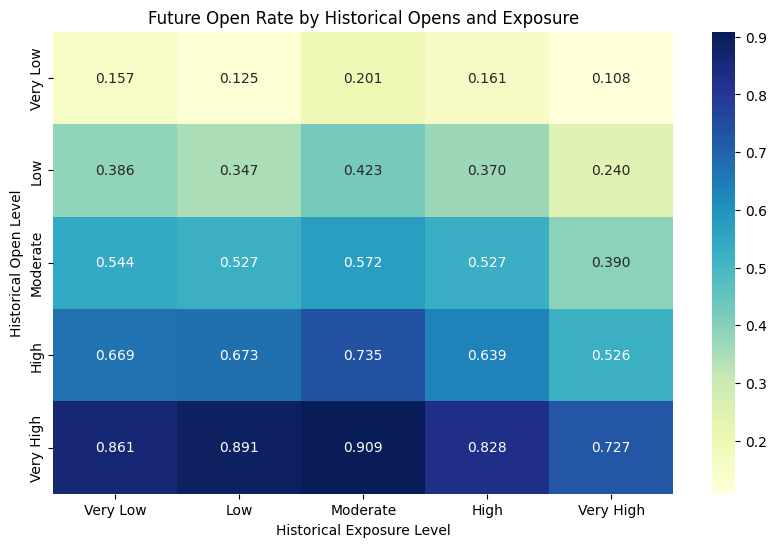

In [603]:
# heat map

#relabel rows and columns
open_heatmap = open_heatmap.rename(
    index = {
        'very_low': 'Very Low',
        'low': 'Low',
        'medium': 'Moderate',
        'high': 'High',
        'very_high': 'Very High'},

    columns = {
        'very_little': 'Very Low',
        'little': 'Low',
        'moderate': 'Moderate',
        'heavy': 'High',
        'very_heavy': 'Very High'})

# plot
plt.figure(figsize = (10,6))

sns.heatmap(
    open_heatmap,
    annot = True,
    fmt = ".3f",
    cmap = "YlGnBu"
)

plt.title('Future Open Rate by Historical Opens and Exposure')
plt.ylabel('Historical Open Level')
plt.xlabel('Historical Exposure Level')

plt.show()

Moving down a row (higher past open rate) always produces a much larger jump in future open rate than moving across a column (more exposure). Past behaviour is the stronger signal.

Fatigue effect is visible within every row — within each past open level, the very_heavy exposure column consistently shows the lowest open rate. Even among Very High historical openers, very heavy exposure drops the rate from ~0.909 (moderate exposure) to 0.727. Fatigue exists but is muted for engaged users.

Very High openers with Moderate exposure achieve the highest open rate in the entire matrix: 0.909

Insights
- Past open behaviour is a very strong predictor of future opens (just like in earlier finding)
- Moderate exposure may reinforce engagement rather than immediately causing fatigue (just like in earlier finding)
- Extreme frequent exposure is associated with declining engagement, even among historically active users
- Highly historically engaged users appear more resistant to exposure fatigue

### Historical clicks x Historical exposure

In [604]:
df_history.groupby(['exposure_bucket', 'clicked_before'])[['open', 'click']].mean()

open     click
exposure_bucket clicked_before                    
very_little     False           0.535939  0.000765
                True            0.646209  0.559486
little          False           0.537155  0.000187
                True            0.419558  0.234390
moderate        False           0.604427  0.000095
                True            0.333512  0.110110
heavy           False           0.556988  0.000097
                True            0.346335  0.087859
very_heavy      False           0.445065  0.000074
                True            0.327556  0.049023

In [605]:
# pivot click rates
click_pivot = df_history.pivot_table(
    values = 'click',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

click_pivot

clicked_before,False,True
exposure_bucket,,
very_little,0.000765,0.559486
little,0.000187,0.234390
moderate,0.000095,0.110110
heavy,0.000097,0.087859
very_heavy,0.000074,0.049023


In [606]:
interaction_plot_click = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['click']].mean().reset_index())

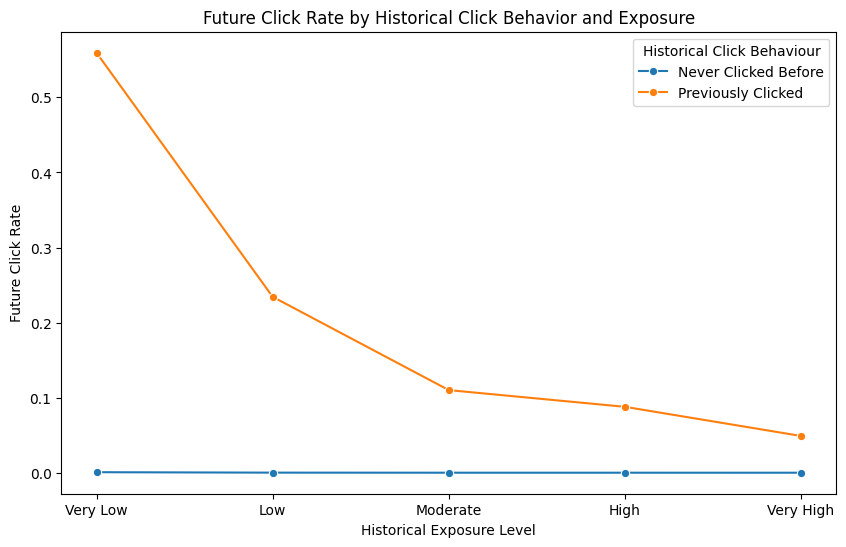

In [607]:
# line plot

# relabel x axis
""" 
interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].replace({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

"""

# relabel x axis
interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].cat.rename_categories({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_click['clicked_before'] = interaction_plot_click['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_click,
    x='exposure_bucket',
    y='click',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Click Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Click Rate')

plt.legend(title = 'Historical Click Behaviour')

plt.show()

Orange line (Previously Clicked): starts at 0.559 and drops steeply — nearly a 10x decline from very_little to very_heavy exposure. The sharpest drop is in the first two steps (very_little → moderate)
Blue line (Never Clicked): hugs zero across the entire x-axis — effectively flat at ~0.0001–0.0008

Insights
- Exposure barely changes anything for users who never clicked before
- Historically engaged clickers are highly sensitive to exposure volume
- Exposure redically compress click behaviour among prior clickers

In [608]:
# pivot open rates
open_pivot = df_history.pivot_table(
    values = 'open',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

open_pivot

clicked_before,False,True
exposure_bucket,,
very_little,0.535939,0.646209
little,0.537155,0.419558
moderate,0.604427,0.333512
heavy,0.556988,0.346335
very_heavy,0.445065,0.327556


In [609]:
interaction_plot_open = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['open']].mean().reset_index())

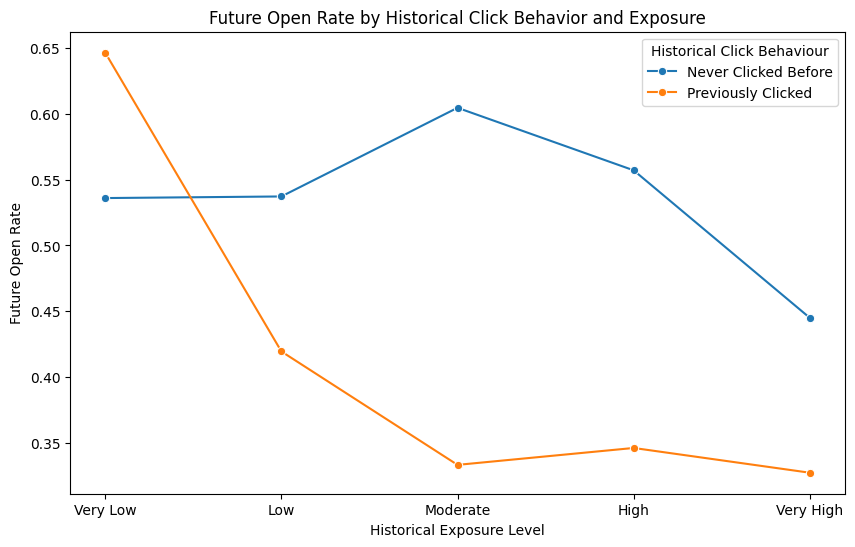

In [610]:
# line plot

# relabel x axis
interaction_plot_open['exposure_bucket'] = interaction_plot_open['exposure_bucket'].cat.rename_categories({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_open['clicked_before'] = interaction_plot_open['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_open,
    x='exposure_bucket',
    y='open',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Open Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Open Rate')

plt.legend(title = 'Historical Click Behaviour')


plt.show()

Blue (Never Clicked): open rate follows the familiar inverted-U from earlier, peaks at moderate exposure (0.605) then falls to 0.445 at very_heavy
Orange (Previously Clicked): starts high (0.646) at very_little but drops sharply and crosses below the non-clickers line by moderate exposure, ending at 0.328 at very_heavy

The crossover between the two lines: prior clickers start as the more engaged group but become the lower-opening group under high exposure, confirming they are a qualitatively different and more fatigue-sensitive segment.

Insights
- Similar but weaker pattern was observed for future opens
- Exposure affects prior clickers much more strongly than historically passive users
- Prior clickers showed substantially lower open rates under heavier exposure levels

### Historical opens x Historical clicks

In [611]:
df_history.groupby(['past_open_bucket', 'clicked_before'])[['open', 'click']].mean()

open     click
past_open_bucket clicked_before                    
very_low         False           0.153576  0.000331
                 True            0.120295  0.093699
low              False           0.346328  0.000066
                 True            0.234521  0.081096
medium           False           0.500872  0.000098
                 True            0.351145  0.065926
high             False           0.636007  0.000083
                 True            0.525408  0.115245
very_high        False           0.841359  0.000125
                 True            0.783032  0.208623

In [612]:
# create binary open groups (high/low past opens)
df_history['open_behaviour'] = np.where(
    df_history['past_open_rate'] >= df_history['past_open_rate'].median(),      # median as threshold
    'High Historical Opens',
    'Low Historical Opens')

In [613]:
df_history['open_behaviour'].value_counts(normalize = True)

open_behaviour
Low Historical Opens     0.547731
High Historical Opens    0.452269
Name: proportion, dtype: float64

In [614]:
# create behavioural groups based on open groups and click groups
conditions = [
    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == True),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == True)]

# group names
choices = [
    'Habitual Openers',         # high past opens, never clicked
    'Highly Engaged Users',     # high past opens, clicked before
    'Disengaged Users',         # low past opens, never clicked
    'Selective Users']          # low past opens, clicked before

df_history['engagement_group'] = np.select(conditions, choices, default = 'Other')

In [615]:
df_history.groupby('engagement_group')[['open', 'click']].mean().sort_values('click', ascending = False)

,open,click
engagement_group,,
Highly Engaged Users,0.665898,0.167243
Selective Users,0.212604,0.091734
Disengaged Users,0.304201,0.000232
Habitual Openers,0.774846,0.000113


In [616]:
df_history['engagement_group'].value_counts(normalize = True)

engagement_group
Disengaged Users        0.542395
Habitual Openers        0.450020
Selective Users         0.005336
Highly Engaged Users    0.002249
Name: proportion, dtype: float64

Disengaged Users: 54% — the majority of interactions come from the lowest-value segment

Habitual Openers: 45% — high open rates but almost zero click value

Selective Users: 0.53% — tiny but punching far above their weight in clicks

Highly Engaged Users: 0.22% — the rarest and most valuable segment

The two highest-click segments together represent less than 1% of all interactions, yet they are the primary drivers of click revenue.

## Click-given-open Analysis

In [617]:
# keep only emails that were open
df_opened = df_history[df_history['open'] == 1].copy()

#click rate a mong opened emails
overall_click_given_open = df_opened['click'].mean()

overall_click_given_open

np.float64(0.001574200601257174)

In [618]:
df_opened.shape

(567034, 31)

Insights

Open rate ~50-60%, but post-open conversion is extremely low -> attention does not necessarily translate into deeper engagement

### Click-given-open by topic

In [619]:
# click|open by topic
#ranks topics by their post-open conversion rate
df_opened.groupby('main_topic')['click'].mean().sort_values(ascending = False)

main_topic
Charity & Social Impact    0.004264
Finance & Investment       0.002640
Automotive & Mobility      0.002490
Retail & Promotion         0.001462
Business                   0.001461
Lottery & Games            0.001419
Missing                    0.000843
Media & Publishing         0.000786
Energy & Sustainability    0.000643
Health & Wellbeing         0.000169
Food & Beverages           0.000137
Telecom & Technology       0.000000
Name: click, dtype: float64

In [620]:
#opened emails per topic
df_opened['main_topic'].value_counts()

main_topic
Media & Publishing         233359
Automotive & Mobility      147846
Lottery & Games             60136
Charity & Social Impact     43435
Energy & Sustainability     25817
Health & Wellbeing          12053
Business                    10793
Retail & Promotion          10571
Missing                      9828
Food & Beverages             7629
Finance & Investment         4902
Telecom & Technology          665
Name: count, dtype: int64

In [621]:
df_opened['main_topic'].value_counts(normalize = True)

main_topic
Media & Publishing         0.411543
Automotive & Mobility      0.260736
Lottery & Games            0.106054
Charity & Social Impact    0.076600
Energy & Sustainability    0.045530
Health & Wellbeing         0.021256
Business                   0.019034
Retail & Promotion         0.018643
Missing                    0.017332
Food & Beverages           0.013454
Finance & Investment       0.008645
Telecom & Technology       0.001173
Name: proportion, dtype: float64

Insights
- Charity & Social, Finance & Investment , Automotive & Mobility: highest post-open conversion rates -> these topics generate stronger action-oriented engagement
- Charity & Social, Finance & Investment: strong post-open behaviour despite low exposure volume
- Health & Wellbeing, Food & Beverages: weak post-open conversion 
- Topic distributions are highly imbalanced (Media & Publishing and Automotive & Mobility account for the majority of opened emails)
- Engagement rates for dominant topics are more stable, smaller topics (eg. Telecom & Technology) should be interpreted more cautiously

### Click-given-open by historical engagement

In [622]:
# click|open by historical engagement
df_opened.groupby('past_open_bucket')['click'].mean()

past_open_bucket
very_low     0.005118
low          0.002486
medium       0.001478
high         0.001137
very_high    0.001133
Name: click, dtype: float64

The more a user has opened historically, the less likely they are to click after opening.

In [623]:
df_opened['past_open_bucket'].value_counts(normalize = True)

past_open_bucket
very_high    0.534706
high         0.184865
medium       0.124050
low          0.091074
very_low     0.065305
Name: proportion, dtype: float64

Insights
- Historically frequent openers are LESS likely to click after opening (open frequently, low click intent) -> high opens does not necessarily imply high clicks
- Low historical open users are MORE likely to click (open rarely, higher click intent)
- Strongest click-given-open users are a minority segment (users with very low past open rates)
- Past open negatively relates to post-open clicking, past open strongly related to future opens (earlier findings) -> opens and clicks represent different dimensions of engagement

### Click-given-open by exposure bucket

In [624]:
# click|open by exposure bucket
df_opened.groupby('exposure_bucket')['click'].mean()

exposure_bucket
very_little    0.003278
little         0.002029
moderate       0.001189
heavy          0.001170
very_heavy     0.001387
Name: click, dtype: float64

In [625]:
df_opened['exposure_bucket'].value_counts(normalize = True)

exposure_bucket
heavy          0.290810
moderate       0.256457
very_heavy     0.183696
little         0.167115
very_little    0.101922
Name: proportion, dtype: float64

Insights
- Post-open conversion behaviour generally declines as historical email exposure increases, with a slight increase among the heaviest exposured users (may suggest content fatigue)
- Users with lower historical exposure are more likely to click after opening
- Heavily exposed users show weaker post-open engagement -> repeated campaign exposre may reduce not only initial attention (earlier finding) but also deeper engagement

### Click-given-open by interest match

In [626]:
df_opened.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment', 'mapped_interest_topic',
       'interest_topic_match', 'past_opens', 'past_clicks', 'emails_before',
       'past_open_rate', 'past_click_rate', 'past_open_bucket',
       'clicked_before', 'exposure_bucket', 'open_behaviour',
       'engagement_group'],
      dtype='str')

In [627]:
# click|open by interest match
df_opened.groupby('interest_topic_match')['click'].mean()

interest_topic_match
0    0.001828
1    0.001562
Name: click, dtype: float64

In [628]:
df_opened['interest_topic_match'].value_counts(normalize = True)

interest_topic_match
1    0.92259
0    0.07741
Name: proportion, dtype: float64

Insights
- Most opened emails were classified as matching user interests (~92%), however, matched emails did not achieve higher click-given-open rates
-> Interest matching mainly influenes opens rather than post-open (click) engagement

# Analysis Part 3


## Data device, browsers, emailclient

This is not user-level data. It's a pre-aggregated summary table provided by OMG. We cannot join it to df_final because there's no user_id or mailing_id column.

In [629]:
df_device = pd.read_excel('data/Data device, browsers, emailclient.xlsx')

In [630]:
print(df_device.shape)
print(df_device.columns.tolist())


(40, 2)
['Unnamed: 0', 'Unnamed: 1']


In [631]:
print(df_device.head(5))
print(df_device.dtypes)

  Unnamed: 0  Unnamed: 1
0        NaN         NaN
1        NaN         NaN
2        NaN         NaN
3        NaN         NaN
4        NaN         NaN
Unnamed: 0        str
Unnamed: 1    float64
dtype: object


In [632]:
#different header rows
for i in range(10):
    df_test = pd.read_excel('data/Data device, browsers, emailclient.xlsx', header=i)
    if not df_test.columns.str.contains('Unnamed').all():
        print(f"Header row: {i}")
        print(df_test.columns.tolist())
        print(df_test.head(3))
        break

#checking all sheets
xl = pd.ExcelFile('data/Data device, browsers, emailclient.xlsx')
print(f"\nSheet names: {xl.sheet_names}")


Sheet names: ['Blad1']


In [633]:
#first 20 rows
df_raw = pd.read_excel('data/Data device, browsers, emailclient.xlsx', 
                        sheet_name='Blad1',
                        header=None)

print(df_raw.shape)
print(df_raw.to_string()) 

(41, 2)
                   0      1
0                NaN    NaN
1                NaN    NaN
2                NaN    NaN
3                NaN    NaN
4                NaN    NaN
5                NaN    NaN
6                NaN    NaN
7                NaN    NaN
8                NaN    NaN
9                NaN    NaN
10               NaN    NaN
11               NaN    NaN
12               NaN    NaN
13               NaN    NaN
14               NaN    NaN
15               NaN    NaN
16               NaN    NaN
17               NaN    NaN
18               NaN    NaN
19               NaN    NaN
20               NaN    NaN
21           Device     NaN
22                PC  0.100
23        Smartphone  0.070
24            tablet  0.010
25            overig  0.820
26               NaN    NaN
27               NaN    NaN
28      Emailcliente    NaN
29             Gmail  0.350
30         Applemail  0.180
31           outlook  0.090
32   windowslivemail  0.020
33            overig  0.360
34          

In [634]:
#rows
for idx, row in df_raw.iterrows():
    if not (pd.isna(row[0]) and pd.isna(row[1])):
        print(f"Row {idx}: {row[0]} | {row[1]}")

Row 21: Device  | nan
Row 22: PC | 0.1
Row 23: Smartphone | 0.07
Row 24: tablet | 0.01
Row 25: overig | 0.82
Row 28: Emailcliente | nan
Row 29: Gmail | 0.35
Row 30: Applemail | 0.18
Row 31: outlook | 0.09
Row 32: windowslivemail | 0.02
Row 33: overig | 0.36
Row 35: Browers | nan
Row 36: Chrome | 0.72
Row 37: microsoft egde | 0.23
Row 38: firefox | 0.02
Row 39: internet explore | 0.02
Row 40: overige | 0.005


In [635]:
#parsing into three clean dataframes
device_df = pd.DataFrame({
    'category': ['PC', 'Smartphone', 'Tablet', 'Other'],
    'proportion': [0.10, 0.07, 0.01, 0.82]
})

email_client_df = pd.DataFrame({
    'category': ['Gmail', 'Apple Mail', 'Outlook', 'Windows Live Mail', 'Other'],
    'proportion': [0.35, 0.18, 0.09, 0.02, 0.36]
})

browser_df = pd.DataFrame({
    'category': ['Chrome', 'Microsoft Edge', 'Firefox', 'Internet Explorer', 'Other'],
    'proportion': [0.72, 0.23, 0.02, 0.02, 0.005]
})

print(device_df)
print('\n', email_client_df)
print('\n', browser_df)

     category  proportion
0          PC        0.10
1  Smartphone        0.07
2      Tablet        0.01
3       Other        0.82

             category  proportion
0              Gmail        0.35
1         Apple Mail        0.18
2            Outlook        0.09
3  Windows Live Mail        0.02
4              Other        0.36

             category  proportion
0             Chrome       0.720
1     Microsoft Edge       0.230
2            Firefox       0.020
3  Internet Explorer       0.020
4              Other       0.005


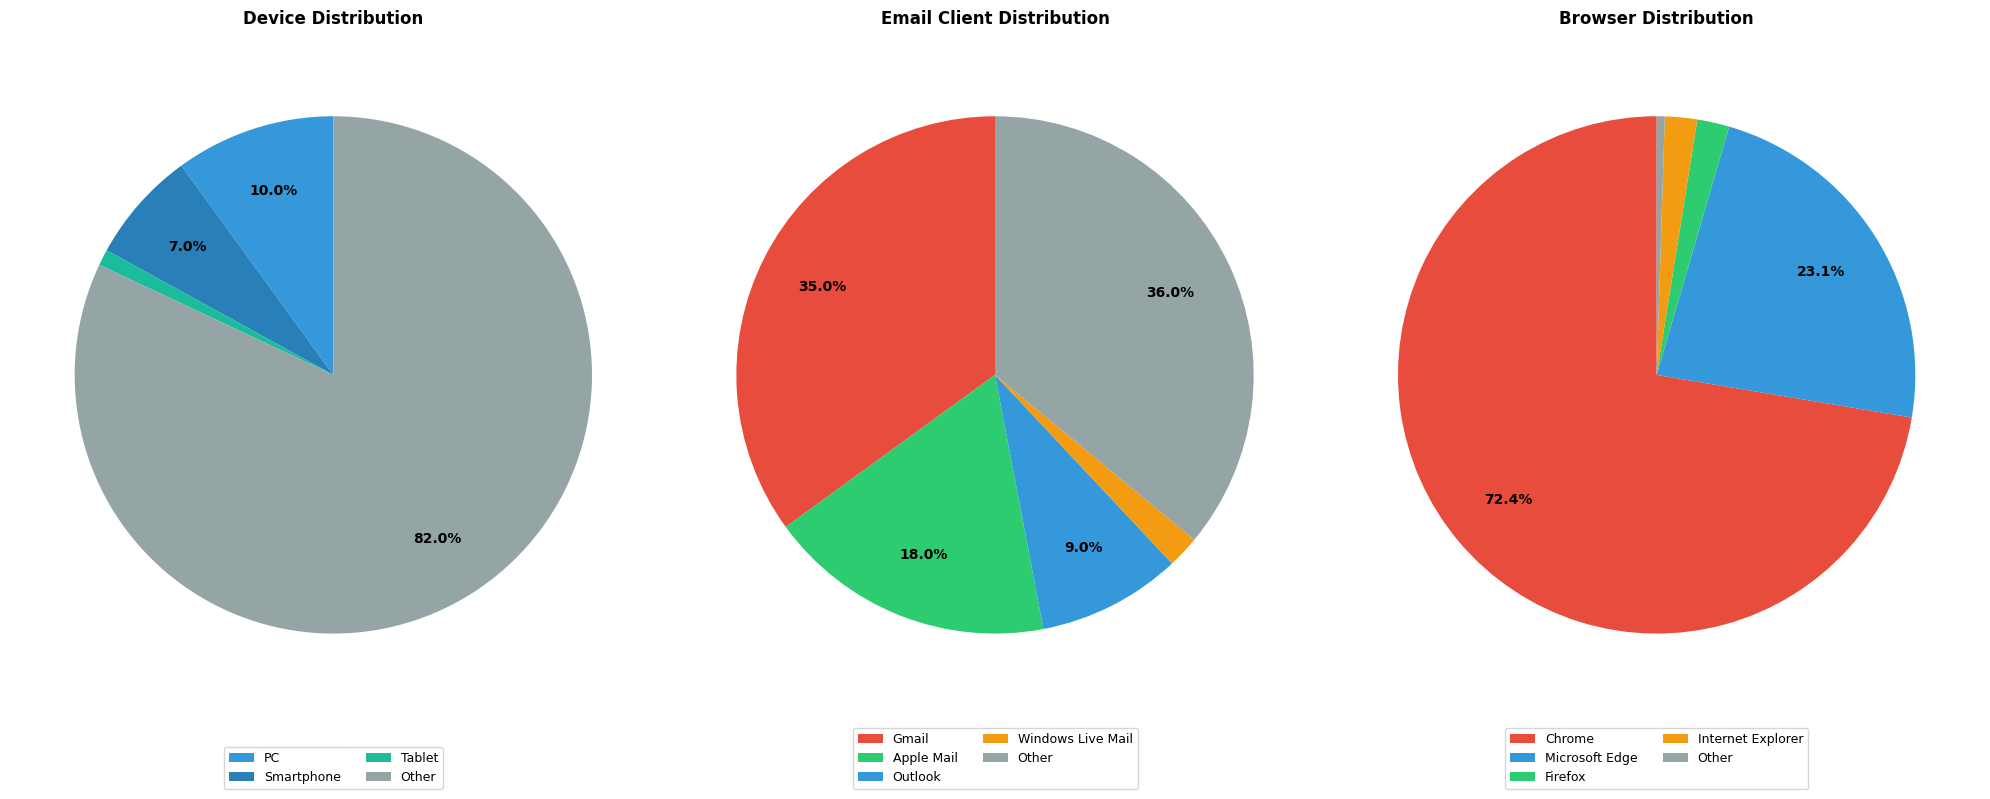

In [636]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

data = [
    (device_df, 'Device Distribution'),
    (email_client_df, 'Email Client Distribution'),
    (browser_df, 'Browser Distribution')
]

colors_list = [
    ['#3498db', '#2980b9', '#1abc9c', '#95a5a6'],
    ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#95a5a6'],
    ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#95a5a6']
]

for ax, (df, title), colors in zip(axes, data, colors_list):
    wedges, texts, autotexts = ax.pie(
        df['proportion'],
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        colors=colors,
        startangle=90,
        pctdistance=0.75,
    )
    
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

    # Use legend instead of labels
    ax.legend(
        wedges,
        df['category'],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        fontsize=9
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Dataset with time

 ### Dataset

In [637]:
#check what columns exist
df_final.columns.tolist()

['user_id',
 'gender',
 'birth_date',
 'postcode',
 'city',
 'interests',
 'age',
 'n_interests',
 'open_type',
 'click_type',
 'mailing_id',
 'open',
 'click',
 'mailing_info',
 'subject_line',
 'preheader']

In [638]:
df_time = pd.read_excel('data/UVA Robin .xlsx') 

In [639]:
print(df_time.shape)
print(df_time.columns.tolist())

(1400, 11)
['Unnamed: 0', 'Subjectline', 'Mail ID ', 'Dag', 'Datum', 'Klant / bureau', 'Campagnenaam', 'Time stamp ', 'openInterst / clickInterest ', 'Mail content ', 'Unnamed: 10']


In [640]:
print(df_time.head(5))

  Unnamed: 0                       Subjectline Mail ID         Dag  \
0       ntvx                               NaN     1417  Donderdag   
1        NaN  Wat zit er in Donalds strandtas?     1419        NaN   
2        NaN                               NaN      NaN        NaN   
3        NaN                               NaN      NaN        NaN   
4       ntvx                               NaN     1418  Donderdag   

                 Datum Klant / bureau                Campagnenaam  \
0  2026-04-23 00:00:00            CPX  Donald Duck + Strandpakket   
1                  NaN            NaN                         NaN   
2                  NaN            NaN                         NaN   
3                  NaN            NaN                         NaN   
4  2026-04-23 00:00:00            CRS  Donald Duck + Strandpakket   

                                         Time stamp   \
0                                           -Akkoord   
1      Subjectline: Wat zit er in Donalds strandtas?

In [641]:
df_time.columns = ['client', 'subject_line', 'mailing_id', 'day_of_week',
    'send_date', 'client_bureau', 'campaign_name',
    'log_field', 'target_interests', 'mail_content', 'extra']
df_time.head(5)

,client,subject_line,mailing_id,day_of_week,send_date,client_bureau,campaign_name,log_field,target_interests,mail_content,extra
0,ntvx,NaN,1417,Donderdag,2026-04-23 00:00:00,CPX,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",NaN,NaN
1,NaN,Wat zit er in Donalds strandtas?,1419,NaN,NaN,NaN,NaN,Subjectline: Wat zit er in Donalds strandtas?,NaN,https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pre-header: Ontdek het pakket en lees de leuks...,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260422 - CPX - CPX Donald Duck + Strandpakket ...,NaN,NaN,NaN
4,ntvx,NaN,1418,Donderdag,2026-04-23 00:00:00,CRS,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN


In [642]:
#for each mailing_id, find the row containing 'adressen' and extract from there
def extract_from_log(df_raw, mailing_col='mailing_id'):
    results = []
    df_raw['mailing_id_filled'] = df_raw['mailing_id'].ffill()
    
    for mid, group in df_raw.groupby('mailing_id_filled'):
        log_rows = group[group['log_field'].str.contains('adressen', na=False, case=False)]
        send_hour = None
        audience_size = None
        
        for _, row in log_rows.iterrows():
            log = str(row['log_field'])
            hour_m = re.search(r'\b(\d{1,2})u(?:ur)?\b', log)
            size_m = re.search(r'([\d\.]+)\s+adressen', log, re.IGNORECASE)
            if hour_m:
                send_hour = int(hour_m.group(1))
            if size_m:
                try:
                    audience_size = int(size_m.group(1).replace('.', ''))
                except ValueError:
                    pass
        
        results.append({'mailing_id': mid, 'send_hour': send_hour, 'audience_size': audience_size})
    
    return pd.DataFrame(results)

df_log_info = extract_from_log(df_raw=df_time)

In [643]:
df_log_info

,mailing_id,send_hour,audience_size
0,641,19.0,18243.0
1,646,19.0,17343.0
2,647,19.0,65000.0
3,653,16.0,26922.0
4,654,16.0,45000.0
...,...,...,...
186,1419,19.0,247426.0
187,Na het inplannen van elke verzending moet je p...,NaN,NaN
188,X,16.0,8000.0
189,x,16.0,20000.0


Assuming that every sub-row belongs to the campaign block directly above it, so it shares the same date and day of week.

In [644]:
# Forward fill day_of_week and send_date to fill gaps
df_time_filled = df_time.copy()
df_time_filled['day_of_week'] = df_time_filled['day_of_week'].ffill()
df_time_filled['send_date'] = df_time_filled['send_date'].ffill()

#keep only rows with valid numeric mailing_id
df_time_filled = df_time_filled[
    df_time_filled['mailing_id'].astype(str).str.match(r'^\d+$')
].copy()
df_time_filled['mailing_id'] = df_time_filled['mailing_id'].astype(int)

# Keep one row per mailing_id (first occurrence)
df_time_clean = df_time_filled.drop_duplicates(subset='mailing_id', keep='first').copy()

# translate Dutch day names to English
day_map = {
    'Maandag': 'Monday', 'Dinsdag': 'Tuesday', 'Woensdag': 'Wednesday',
    'Donderdag': 'Thursday', 'Vrijdag': 'Friday',
    'Zaterdag': 'Saturday', 'Zondag': 'Sunday'
}
df_time_clean['day_of_week'] = df_time_clean['day_of_week'].map(day_map).fillna(df_time_clean['day_of_week'])

print(f"Shape: {df_time_clean.shape}")

Shape: (186, 12)


In [645]:
print(f"Unique mailing IDs: {df_time_clean['mailing_id'].nunique()}")
print('\n', df_time_clean['day_of_week'].value_counts(dropna=False))
print('\n', df_time_clean[['mailing_id', 'day_of_week', 'send_date']].head(10))

Unique mailing IDs: 186

 day_of_week
Thursday     84
Tuesday      51
Wednesday    35
Friday        9
Monday        3
Sunday        2
Saturday      2
Name: count, dtype: int64

     mailing_id day_of_week            send_date
0         1417    Thursday  2026-04-23 00:00:00
1         1419    Thursday  2026-04-23 00:00:00
4         1418    Thursday  2026-04-23 00:00:00
12        1411     Tuesday  2026-04-21 00:00:00
16        1408    Thursday  2026-04-16 00:00:00
19        1398    Thursday  2026-04-16 00:00:00
20        1399    Thursday  2026-04-16 00:00:00
29        1403     Tuesday  2026-04-14 00:00:00
33        1365     Tuesday  2026-04-07 00:00:00
37        1390   Wednesday  2026-04-08 00:00:00


#### Merge

In [646]:
#clean df_log_info and df_time_clean
df_log_info_clean = df_log_info[
    df_log_info['mailing_id'].astype(str).str.match(r'^\d+$')].copy()

df_log_info_clean['mailing_id'] = df_log_info_clean['mailing_id'].astype(int)

In [647]:
#merge
df_time_clean = df_time_clean.merge(df_log_info_clean, on='mailing_id', how='left')

print(f"send_hour NaNs: {df_time_clean['send_hour'].isna().sum()} out of {len(df_time_clean)}")
print(df_time_clean[['mailing_id', 'day_of_week', 'send_date', 'send_hour', 'audience_size']].head(10))

send_hour NaNs: 37 out of 186
   mailing_id day_of_week            send_date  send_hour  audience_size
0        1417    Thursday  2026-04-23 00:00:00        NaN            NaN
1        1419    Thursday  2026-04-23 00:00:00       19.0       247426.0
2        1418    Thursday  2026-04-23 00:00:00        NaN            NaN
3        1411     Tuesday  2026-04-21 00:00:00       16.0        25500.0
4        1408    Thursday  2026-04-16 00:00:00        NaN            NaN
5        1398    Thursday  2026-04-16 00:00:00        NaN            NaN
6        1399    Thursday  2026-04-16 00:00:00       19.0        83815.0
7        1403     Tuesday  2026-04-14 00:00:00       16.0         2000.0
8        1365     Tuesday  2026-04-07 00:00:00       16.0        23567.0
9        1390   Wednesday  2026-04-08 00:00:00        NaN       169385.0


In [648]:
#merge into df_final
df_final_time = df_final.merge(
    df_time_clean[['mailing_id', 'day_of_week', 'send_date', 'send_hour', 'audience_size']],
    on='mailing_id',
    how='left'
)

df_final_time = df_final_time.merge(
    df_time_clean[['mailing_id', 'client_bureau', 'campaign_name']],
    on='mailing_id', how='left'
)
print(f"Shape: {df_final_time.shape}")

Shape: (1156304, 22)


In [649]:
print(f"day_of_week NaNs: {df_final_time['day_of_week'].isna().sum()}")
print(f"send_hour NaNs: {df_final_time['send_hour'].isna().sum()}")
print(f"Rows WITH day_of_week: {df_final_time['day_of_week'].notna().sum()}")

day_of_week NaNs: 339593
send_hour NaNs: 578454
Rows WITH day_of_week: 816711


In [650]:
print(df_final_time['day_of_week'].value_counts(dropna=False))

day_of_week
Thursday     368358
NaN          339593
Wednesday    267562
Tuesday      117932
Friday        36521
Sunday        13322
Saturday      11418
Monday         1598
Name: count, dtype: int64


In [651]:
#Coverage
timed_rows = df_final_time['day_of_week'].notna().mean() * 100
n_timed_mail = df_final_time[df_final_time['day_of_week'].notna()]['mailing_id'].nunique()

print(f"df_final unique mailings    : {df_final['mailing_id'].nunique()}")
print(f"df_time_clean unique mailings: {df_time_clean['mailing_id'].nunique()}")
print(f"Mailings matched            : {n_timed_mail}")
print(f"Row coverage (open/click)   : {timed_rows:.1f}%")

df_final_time[['user_id', 'mailing_id', 'open', 'click',
               'day_of_week', 'send_hour', 'audience_size']].head(10)

df_final unique mailings    : 274
df_time_clean unique mailings: 186
Mailings matched            : 168
Row coverage (open/click)   : 70.6%


,user_id,mailing_id,open,click,day_of_week,send_hour,audience_size
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,Friday,NaN,186527.0
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,Wednesday,19.0,243103.0
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Wednesday,19.0,150575.0
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Wednesday,19.0,139736.0
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Wednesday,19.0,158657.0
5,5cb9a38136dd1336b9c528d1,785,0.0,0.0,Wednesday,19.0,205235.0
6,5cb9a38136dd1336b9c528d1,804,0.0,0.0,Wednesday,NaN,NaN
7,5cb9a38136dd1336b9c528d1,825,0.0,0.0,Friday,7.0,132123.0
8,5cb9a38136dd1336b9c528d1,846,0.0,0.0,Wednesday,19.0,99664.0
9,5cb9a38136dd1336b9c528d1,859,0.0,0.0,NaN,NaN,NaN


In [652]:
total = len(df_final_time)
dow_coverage = df_final_time['day_of_week'].notna().sum()
hour_coverage = df_final_time['send_hour'].notna().sum()
date_coverage = df_final_time['send_date'].notna().sum()

print(f"Total rows          : {total:,}")
print(f"day_of_week coverage: {dow_coverage:,} ({dow_coverage/total*100:.1f}%)")
print(f"send_hour coverage  : {hour_coverage:,} ({hour_coverage/total*100:.1f}%)")
print(f"send_date coverage  : {date_coverage:,} ({date_coverage/total*100:.1f}%)")

Total rows          : 1,156,304
day_of_week coverage: 816,711 (70.6%)
send_hour coverage  : 577,850 (50.0%)
send_date coverage  : 816,711 (70.6%)


Temporal data was available for 186 out of 274 unique campaigns, covering 70% of user-mailing interactions. Analysis is conducted on this subset. Older campaigns (mailing IDs < 1334) lack temporal metadata and are excluded from this section. Findings should be interpreted as indicative rather than exhaustive.

In [653]:
print(df_final_time[['open', 'click']].isna().sum())

open     98760
click    52062
dtype: int64


### Send Timing Analysis

#### Day of Week

In [654]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = (
    df_final_time.dropna(subset=['day_of_week', 'open', 'click'])
    .groupby('day_of_week')
    .agg(open_rate=('open', 'mean'),
         click_rate=('click', 'mean'),
         n_records=('open', 'count'))
    .reindex([d for d in day_order if d in df_final_time['day_of_week'].dropna().unique()])
    .reset_index()
)

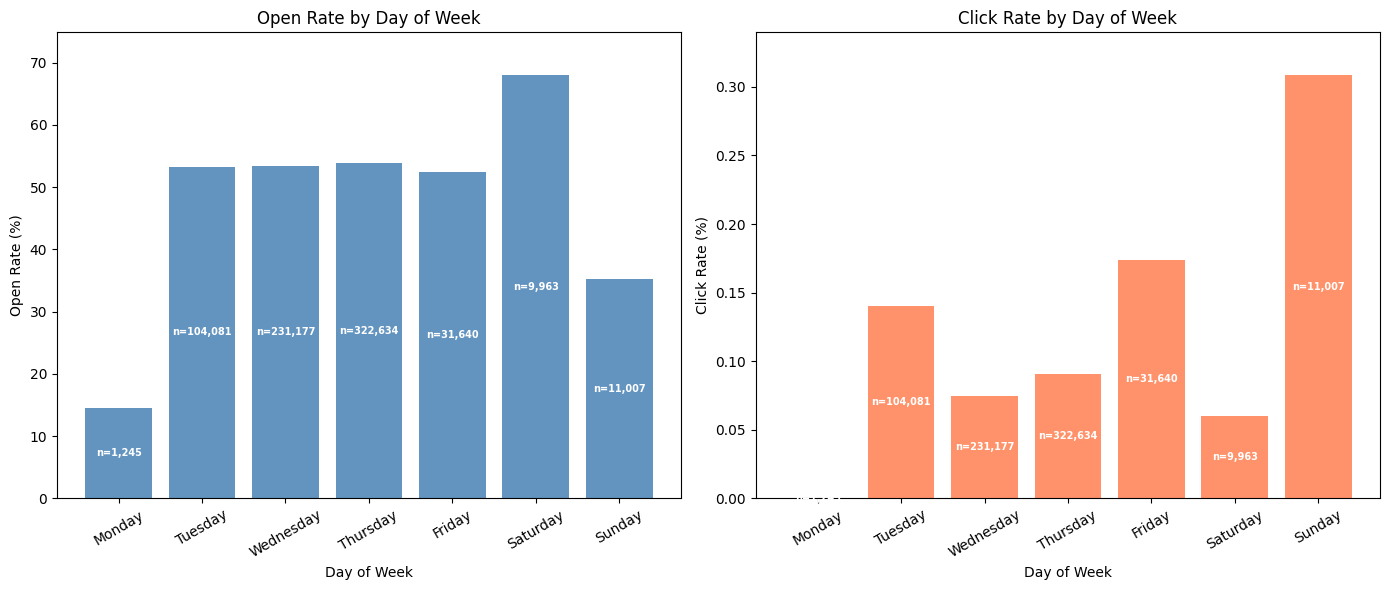

day_of_week  open_rate  click_rate  n_records
     Monday   0.145382    0.000000       1245
    Tuesday   0.533075    0.001403     104081
  Wednesday   0.534686    0.000744     231177
   Thursday   0.539032    0.000908     322634
     Friday   0.523767    0.001738      31640
   Saturday   0.680819    0.000602       9963
     Sunday   0.352230    0.003089      11007


In [655]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    ax.bar(day_stats['day_of_week'], day_stats[metric] * 100, color=color, alpha=0.85)
    ax.set_title(f'{label} by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel(f'{label} (%)')
    ax.tick_params(axis='x', rotation=30)
    
    # Put n= labels INSIDE the bars
    for i, (_, row) in enumerate(day_stats.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,  # halfway up the bar
                f"n={row['n_records']:,}", 
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')
    
    # Add 10% headroom above tallest bar
    ax.set_ylim(0, day_stats[metric].max() * 100 * 1.1)

plt.tight_layout()
plt.show()

print(day_stats[['day_of_week', 'open_rate', 'click_rate', 'n_records']].to_string(index=False))

Open Rate insights:

Saturday has the highest open rate (68%) — but only 9,963 rows, so treat cautiously. Could reflect a selection effect — fewer emails sent on Saturdays, so those that are sent may be more targeted

Tuesday, Wednesday, Thursday are very similar (~53-54%) — these are the core weekday send days with the highest volume and most reliable estimates

Monday is the lowest (14.5%) — but only 1,245 rows, making it statistically unreliable

Sunday is notably lower (35%) than Saturday despite similar volume — suggests weekend engagement is inconsistent

Click Rate insights:

Sunday has the highest click rate (0.31%) — interesting contrast with its lower open rate, suggesting users who open on Sunday are more action-oriented

Friday also performs well for clicks (0.17%) — despite moderate open rates

Wednesday has the lowest click rate (0.07%) — despite being the second most common send day

Thursday dominates volume (322k rows) but has mediocre click performance (0.09%)

#### Send Hour

In [656]:
hour_stats = (
    df_final_time.dropna(subset=['send_hour', 'open', 'click'])
    .groupby('send_hour')
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
    .sort_values('send_hour')
)
hour_stats['send_hour'] = hour_stats['send_hour'].astype(int)

In [657]:
# Remove impossible hours
hour_stats_clean = hour_stats[hour_stats['send_hour'] <= 23].copy()
print(hour_stats_clean[['send_hour', 'open_rate', 'click_rate', 'n_mailings', 'n_records']])

   send_hour  open_rate  click_rate  n_mailings  n_records
0          7   0.560646    0.000816           7      37983
1          8   0.757726    0.000242           1       8251
2          9   0.617867    0.001302           5      33805
3         10   0.257630    0.001419           3       1409
4         11   0.554545    0.000000           5        330
5         14   0.533391    0.000000           2       1153
6         15   0.296678    0.000503           2       3974
7         16   0.531759    0.001236          63     146382
8         17   0.664153    0.000534           2      14986
9         19   0.563267    0.001107          41     244873


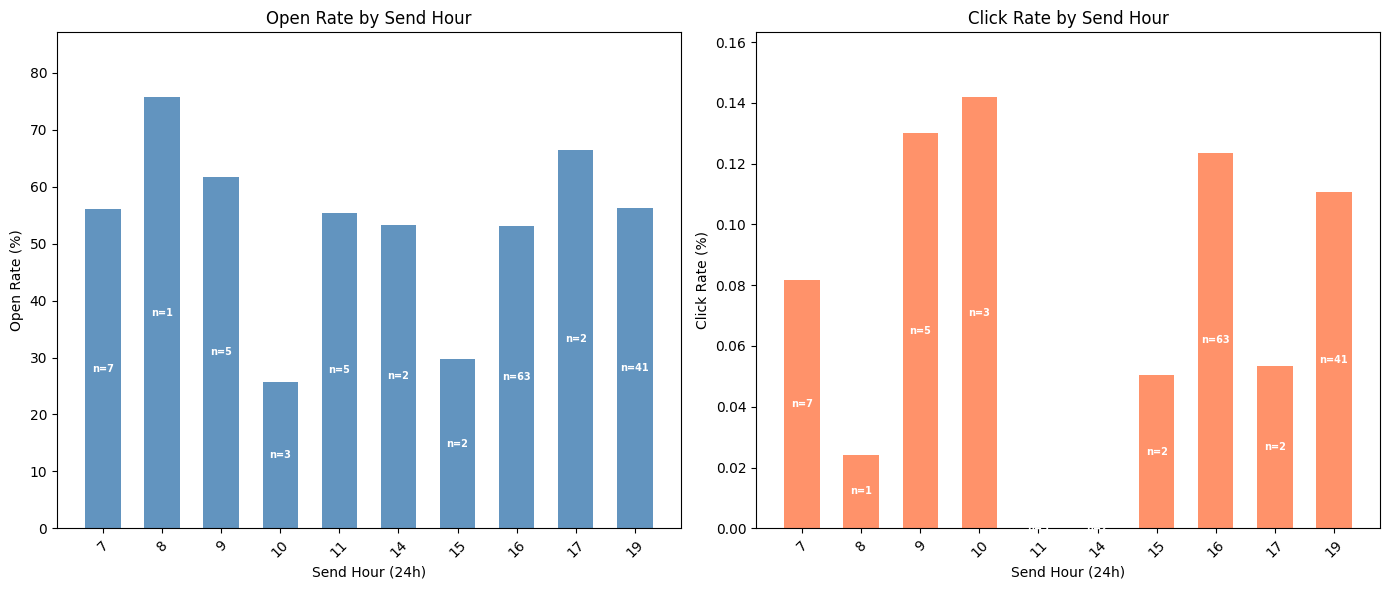

 send_hour  open_rate  click_rate  n_mailings  n_records
         7   0.560646    0.000816           7      37983
         8   0.757726    0.000242           1       8251
         9   0.617867    0.001302           5      33805
        10   0.257630    0.001419           3       1409
        11   0.554545    0.000000           5        330
        14   0.533391    0.000000           2       1153
        15   0.296678    0.000503           2       3974
        16   0.531759    0.001236          63     146382
        17   0.664153    0.000534           2      14986
        19   0.563267    0.001107          41     244873


In [658]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    x = range(len(hour_stats_clean))  # use index positions instead of raw hours
    ax.bar(x, hour_stats_clean[metric] * 100, color=color, alpha=0.85, width=0.6)
    ax.set_title(f'{label} by Send Hour')
    ax.set_xlabel('Send Hour (24h)')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(hour_stats_clean['send_hour'].astype(int), rotation=45)
    ax.set_ylim(0, hour_stats_clean[metric].max() * 100 * 1.15)
    
    # n labels inside bars
    for i, (_, row) in enumerate(hour_stats_clean.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,
                f"n={int(row['n_mailings'])}",
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.show()
print(hour_stats_clean[['send_hour', 'open_rate', 'click_rate', 'n_mailings', 'n_records']].to_string(index=False))

Send hour analysis is limited to hours with sufficient campaign volume.
Only hours 16 and 19 are statistically reliable (n=63 and n=41 campaigns). Other hours have too few campaigns for meaningful conclusions.

Full send-time optimisation requires broader experimentation across hours. (OMG almost exclusively sends at 16:00 and 19:00, making it impossible to properly evaluate other time slots)

#### Month Analysis

In [659]:
# Extract month and year from send_date
df_final_time['send_date'] = pd.to_datetime(df_final_time['send_date'])
df_final_time['month'] = df_final_time['send_date'].dt.month
df_final_time['year'] = df_final_time['send_date'].dt.year
df_final_time['month_year'] = df_final_time['send_date'].dt.to_period('M')

# Monthly engagement
monthly_stats = (
    df_final_time.dropna(subset=['month_year', 'open', 'click'])
    .groupby('month_year')
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
    .sort_values('month_year')
)

print(monthly_stats.to_string(index=False))

month_year  open_rate  click_rate  n_mailings  n_records
   2025-04   0.491925    0.000858           9      33810
   2025-05   0.517760    0.001176          16      43385
   2025-06   0.524579    0.001270          27      85827
   2025-07   0.568484    0.000572           9      62978
   2025-08   0.603613    0.000324           6      43233
   2025-09   0.606278    0.001472          17      69986
   2025-10   0.638764    0.001617          24      57497
   2025-11   0.614867    0.001767          14      57710
   2025-12   0.675263    0.001650           6      29701
   2026-01   0.606045    0.000285           2      14027
   2026-02   0.536750    0.001847           9      37891
   2026-03   0.430988    0.000260          15      92237
   2026-04   0.372695    0.000264          14      83465


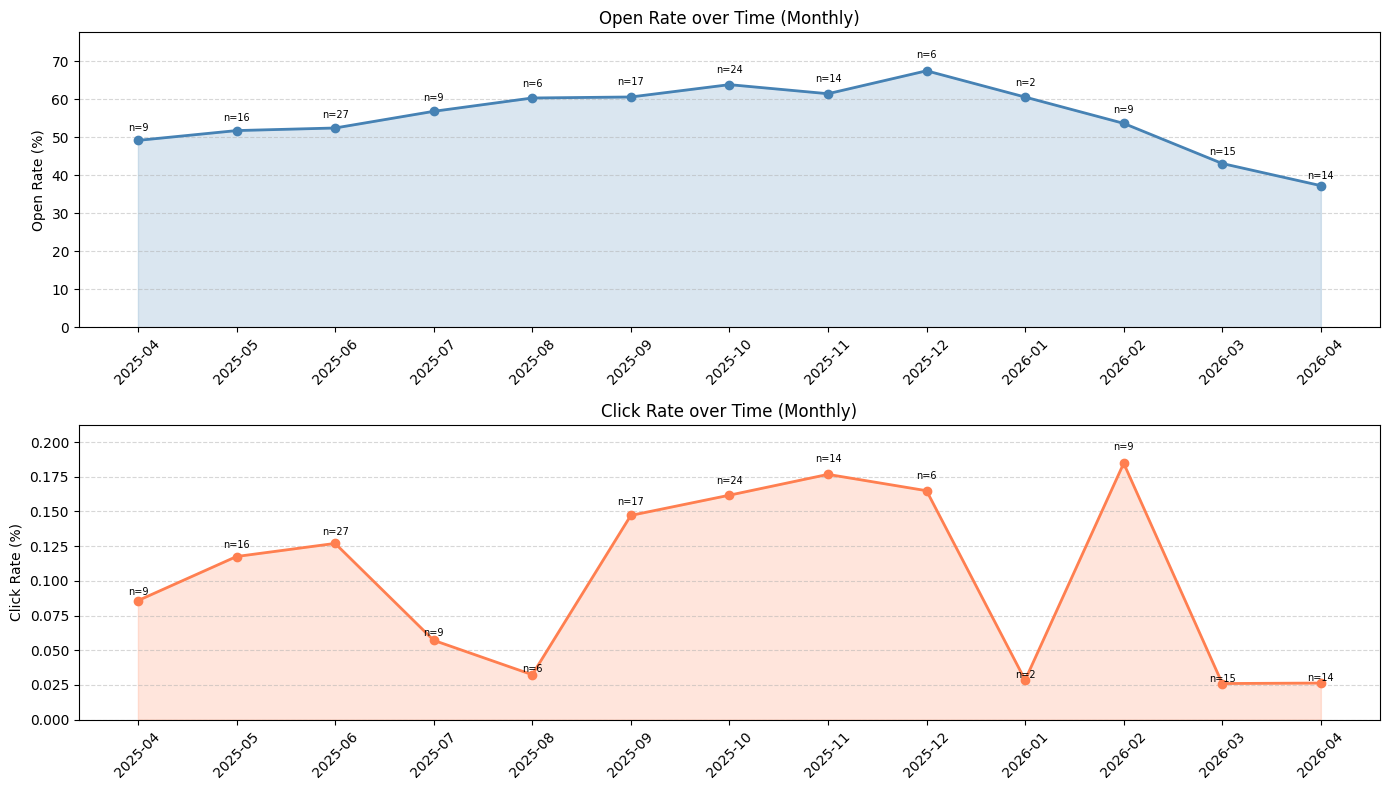

In [660]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

x = range(len(monthly_stats))
x_labels = monthly_stats['month_year'].astype(str)

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    ax.plot(x, monthly_stats[metric] * 100, color=color, marker='o', linewidth=2)
    ax.fill_between(x, monthly_stats[metric] * 100, alpha=0.2, color=color)
    ax.set_title(f'{label} over Time (Monthly)')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylim(0, monthly_stats[metric].max() * 100 * 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add n= labels
    for i, (_, row) in enumerate(monthly_stats.iterrows()):
        ax.text(i, row[metric] * 100 + row[metric] * 100 * 0.05,
                f"n={int(row['n_mailings'])}",
                ha='center', fontsize=7)

plt.tight_layout()
plt.show()

Monthly engagement trends show a clear seasonal pattern for opens — peaking in December 2025 and declining sharply in early 2026.

Click rates are more volatile, peaking in Oct-Nov 2025 and Feb 2026.

The decline in both metrics in 2026 warrants further investigation.

Note: months with fewer than 6 campaigns should be interpreted cautiously.

### Audience Size vs Engagement

In [661]:
#Groups campaigns into 5 meaningful audience size buckets
size_bins = [0, 10_000, 50_000, 100_000, 300_000, float('inf')]
size_labels = ['<10k', '10k–50k', '50k–100k', '100k–300k', '>300k']
pd.cut(df_final_time['audience_size'], bins=size_bins, labels=size_labels)

0          100k–300k
1          100k–300k
2          100k–300k
3          100k–300k
4          100k–300k
             ...    
1156299     50k–100k
1156300    100k–300k
1156301          NaN
1156302          NaN
1156303          NaN
Name: audience_size, Length: 1156304, dtype: category
Categories (5, str): ['<10k' < '10k–50k' < '50k–100k' < '100k–300k' < '>300k']

In [662]:
df_final_time['audience_bucket'] = pd.cut(
    df_final_time['audience_size'],
    bins=[0, 10_000, 50_000, 100_000, 300_000, float('inf')],
    labels=['<10k', '10k-50k', '50k-100k', '100k-300k', '>300k']
)

size_stats = (
    df_final_time.dropna(subset=['audience_bucket', 'open', 'click'])
    .groupby('audience_bucket', observed=True)
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
)

print(size_stats)

  audience_bucket  open_rate  click_rate  n_mailings  n_records
0            <10k   0.594055    0.002180          23      51374
1         10k-50k   0.542804    0.001288          62     120338
2        50k-100k   0.568742    0.001918          22      70925
3       100k-300k   0.544710    0.000530          39     328118


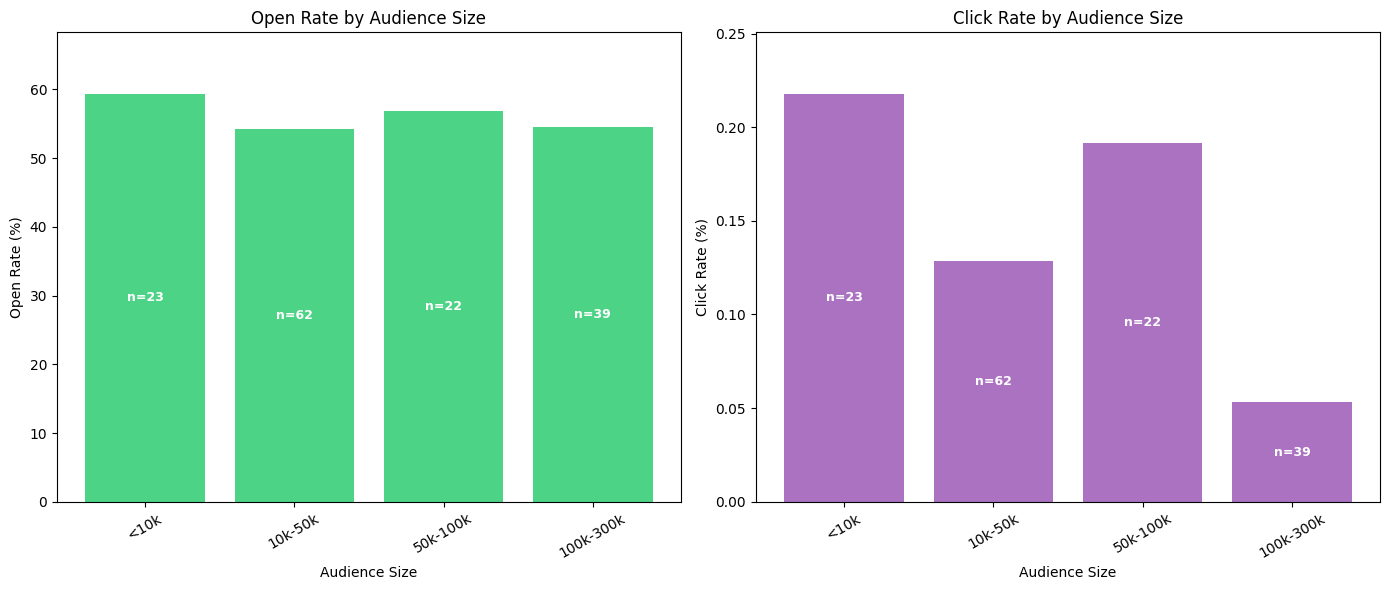

In [663]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#9b59b6'] 

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    colors,
):
    x = range(len(size_stats))
    ax.bar(x, size_stats[metric] * 100, color=color, alpha=0.85)
    ax.set_title(f'{label} by Audience Size')
    ax.set_xlabel('Audience Size')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(size_stats['audience_bucket'].astype(str), rotation=30)
    ax.set_ylim(0, size_stats[metric].max() * 100 * 1.15)
    
    # Labels inside bars
    for i, (_, row) in enumerate(size_stats.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,
                f"n={int(row['n_mailings'])}",
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Audience size has negligible effect on open rates but shows meaningful variation in click rates. Very large campaigns (100k-300k recipients) achieve the lowest click rates, suggesting that broader targeting reduces content-audience fit and post-open conversion.

The non-monotonic pattern may reflect confounding with campaign type; small campaigns tend to be more targeted by design.

### Cross Analysis

#### Open x Topic x Day of the week

In [664]:
#check what columns exist
df_final_time.columns.tolist()

['user_id',
 'gender',
 'birth_date',
 'postcode',
 'city',
 'interests',
 'age',
 'n_interests',
 'open_type',
 'click_type',
 'mailing_id',
 'open',
 'click',
 'mailing_info',
 'subject_line',
 'preheader',
 'day_of_week',
 'send_date',
 'send_hour',
 'audience_size',
 'client_bureau',
 'campaign_name',
 'month',
 'year',
 'month_year',
 'audience_bucket']

In [665]:
#main_topic
df_final_time = df_final_time.merge(
    df_final_topic[['mailing_id', 'main_topic']].drop_duplicates(subset='mailing_id'),
    on='mailing_id',
    how='left')

print(df_final_time['main_topic'].value_counts(dropna=False))

main_topic
Media & Publishing         479712
Automotive & Mobility      257994
Lottery & Games            128094
Charity & Social Impact     98333
Energy & Sustainability     58188
Missing                     28850
Health & Wellbeing          25822
Retail & Promotion          25563
Business                    21087
Finance & Investment        15722
Food & Beverages            15275
Telecom & Technology         1664
Name: count, dtype: int64


In [666]:
#rows with day_of_week and main_topic
df_topic_time = df_final_time.dropna(subset=['day_of_week', 'main_topic']).copy()
df_topic_time = df_topic_time[df_topic_time['main_topic'] != 'Missing']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#Open rate by day x topic
topic_day_open = (
    df_topic_time.groupby(['main_topic', 'day_of_week'])['open']
    .mean()
    .unstack('day_of_week')
    .reindex(columns=[d for d in day_order if d in df_topic_time['day_of_week'].unique()]))

print(topic_day_open.round(3))

day_of_week              Monday  Tuesday  Wednesday  Thursday  Friday  \
main_topic                                                              
Automotive & Mobility       NaN    0.530        NaN     0.644     NaN   
Business                  0.135    0.478      0.492     0.562   0.566   
Charity & Social Impact     NaN      NaN      0.430     0.659   0.000   
Energy & Sustainability     NaN      NaN      0.494     0.516     NaN   
Finance & Investment        NaN    0.385      0.289     0.343     NaN   
Food & Beverages          0.171    0.648        NaN     0.351     NaN   
Health & Wellbeing          NaN    0.481        NaN     0.435     NaN   
Lottery & Games             NaN    0.573      0.555     0.528   0.746   
Media & Publishing          NaN    0.556      0.554     0.467   0.524   
Retail & Promotion          NaN      NaN        NaN     0.665     NaN   
Telecom & Technology        NaN    0.241        NaN     0.527     NaN   

day_of_week              Saturday  Sunday  
main_t

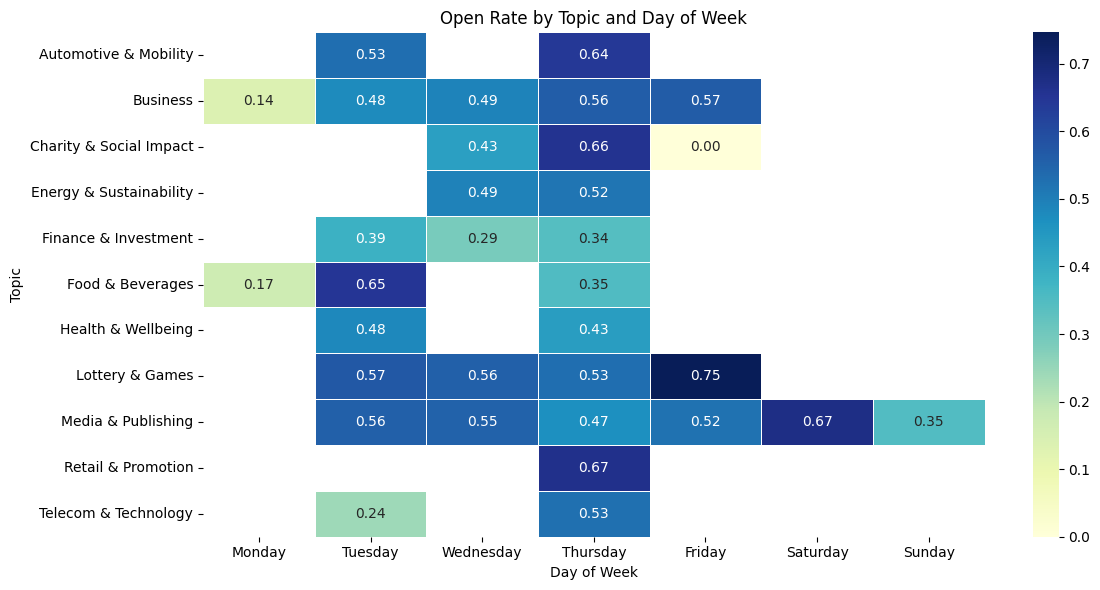

In [667]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    topic_day_open,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5)

plt.title('Open Rate by Topic and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

Topic and send day interact meaningfully — the optimal send day differs by topic. This directly supports the case for personalised send-time recommendations rather than one-size-fits-all scheduling.

Lottery & Games peaks on Friday (0.75), Media & Publishing on Friday/Saturday, while Business content is day-insensitive.

Note: many cells have limited campaign coverage — findings are indicative and require more data to confirm.

#### Click x Topic x Day of the week

In [668]:
# Click rate by day x topic
topic_day_click = (
    df_topic_time.groupby(['main_topic', 'day_of_week'])['click']
    .mean()
    .unstack('day_of_week')
    .reindex(columns=[d for d in day_order if d in df_topic_time['day_of_week'].unique()])
)

print(topic_day_click.round(4))

day_of_week              Monday  Tuesday  Wednesday  Thursday  Friday  \
main_topic                                                              
Automotive & Mobility       NaN   0.0015        NaN    0.0017     NaN   
Business                    0.0   0.0012     0.0012    0.0008  0.0000   
Charity & Social Impact     NaN      NaN     0.0028    0.0046  0.0000   
Energy & Sustainability     NaN      NaN     0.0007    0.0007     NaN   
Finance & Investment        NaN   0.0011     0.0007    0.0024     NaN   
Food & Beverages            0.0   0.0007        NaN    0.0000     NaN   
Health & Wellbeing          NaN   0.0000        NaN    0.0002     NaN   
Lottery & Games             NaN   0.0007     0.0004    0.0002  0.1360   
Media & Publishing          NaN   0.0000     0.0006    0.0004  0.0008   
Retail & Promotion          NaN      NaN        NaN    0.0006     NaN   
Telecom & Technology        NaN   0.0000        NaN    0.0000     NaN   

day_of_week              Saturday  Sunday  
main_t

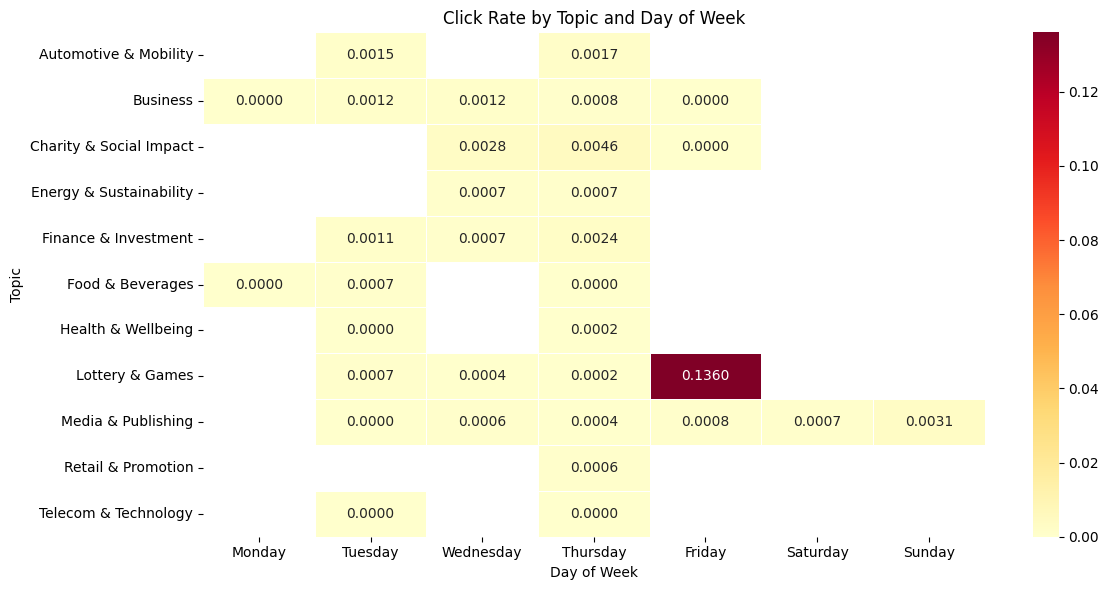

In [669]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    topic_day_click,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    mask=topic_day_click.isna()
)
plt.title('Click Rate by Topic and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

In [670]:
#campaigns behind Lottery & Games Friday
df_topic_time[
    (df_topic_time['main_topic'] == 'Lottery & Games') & 
    (df_topic_time['day_of_week'] == 'Friday')
]['mailing_id'].nunique()

1

Lottery & Games Friday click rate (0.1360) is based on a single campaign and should not be interpreted as a meaningful pattern. It is a statistical artefact of extremely low sample size.

The click rate heatmap overall has very limited reliability due to:
1. Rarity of click events across all topic-day combinations
2. Most cells backed by only 1-3 campaigns
3. Charity & Social Impact (Thursday) and Finance & Investment (Thursday) show the most consistent click performance but still require more data to confirm.

# DF_FINAL_TIME is the dataset with the time

# Baseline model

In [671]:
from sklearn.metrics import mean_absolute_error, roc_auc_score

df_baseline = df_final.copy()

# Clean
df_baseline.columns = df_baseline.columns.str.strip()

df_baseline["open"] = (
    df_baseline["open"]
    .fillna(0)
    .astype(int)
)

# Split by mailing_id
unique_mailings = (
    df_baseline["mailing_id"]
    .drop_duplicates()
    .to_numpy()
)

n = len(unique_mailings)

train_end = int(n * 0.80)

train_mailings = unique_mailings[:train_end]
test_mailings = unique_mailings[train_end:]

train_df_baseline = df_baseline[
    df_baseline["mailing_id"].isin(train_mailings)
]

test_df_baseline = df_baseline[
    df_baseline["mailing_id"].isin(test_mailings)
]

In [672]:
user_open_rate_baseline = (
    train_df_baseline
    .groupby("user_id")["open"]
    .mean()
)

global_open_rate_baseline = (
    train_df_baseline["open"]
    .mean()
)

test_df_baseline["pred_open_prob_baseline"] = (
    test_df_baseline["user_id"]
    .map(user_open_rate_baseline)
    .fillna(global_open_rate_baseline)
)

mae_baseline = mean_absolute_error(
    test_df_baseline["open"],
    test_df_baseline["pred_open_prob_baseline"]
)

auc_baseline = roc_auc_score(
    test_df_baseline["open"],
    test_df_baseline["pred_open_prob_baseline"]
)

print("Baseline MAE:", mae_baseline)
print("Baseline AUC:", auc_baseline)

Baseline MAE: 0.28569634140274935
Baseline AUC: 0.8773528587231172


# Logistic regression model

## Analysis

In [673]:
history_cols = set(df_history.columns.tolist())
history_cols

{'age',
 'birth_date',
 'city',
 'click',
 'click_segment',
 'click_type',
 'clicked_before',
 'emails_before',
 'engagement_group',
 'exposure_bucket',
 'gender',
 'interest_topic_match',
 'interests',
 'mailing_id',
 'mailing_info',
 'main_topic',
 'mapped_interest_topic',
 'n_interests',
 'open',
 'open_behaviour',
 'open_segment',
 'open_type',
 'past_click_rate',
 'past_clicks',
 'past_open_bucket',
 'past_open_rate',
 'past_opens',
 'postcode',
 'preheader',
 'subject_line',
 'user_id'}

In [674]:
final_time_cols = set(df_final_time.columns.tolist())
final_time_cols

{'age',
 'audience_bucket',
 'audience_size',
 'birth_date',
 'campaign_name',
 'city',
 'click',
 'click_type',
 'client_bureau',
 'day_of_week',
 'gender',
 'interests',
 'mailing_id',
 'mailing_info',
 'main_topic',
 'month',
 'month_year',
 'n_interests',
 'open',
 'open_type',
 'postcode',
 'preheader',
 'send_date',
 'send_hour',
 'subject_line',
 'user_id',
 'year'}

In [675]:
#columns
history_cols = set(df_history.columns.tolist())
final_time_cols = set(df_final_time.columns.tolist())

print("In df_history but NOT in df_final_time:")
print(history_cols - final_time_cols)

print("\nIn df_final_time but NOT in df_history:")
print(final_time_cols - history_cols)

In df_history but NOT in df_final_time:
{'mapped_interest_topic', 'past_open_rate', 'click_segment', 'interest_topic_match', 'clicked_before', 'exposure_bucket', 'emails_before', 'open_segment', 'past_click_rate', 'past_open_bucket', 'past_clicks', 'past_opens', 'open_behaviour', 'engagement_group'}

In df_final_time but NOT in df_history:
{'audience_size', 'send_date', 'year', 'send_hour', 'month_year', 'month', 'day_of_week', 'campaign_name', 'client_bureau', 'audience_bucket'}


In [676]:
#from df_history that are missing from df_final_time
history_extra_cols = ['user_id', 'mailing_id', 'engagement_group', 'open_segment', 
                      'past_open_bucket', 'clicked_before', 'click_segment', 
                      'open_behaviour', 'interest_topic_match', 'emails_before', 
                      'past_click_rate', 'past_clicks', 'past_open_rate', 
                      'exposure_bucket', 'past_opens', 'mapped_interest_topic']

#merge into df_final_time
df_master = df_final_time.merge(
    df_history[history_extra_cols],
    on=['user_id', 'mailing_id'],
    how='left'
)

print(f"Shape: {df_master.shape}")
print(f"Columns: {len(df_master.columns)}")
print(df_master.columns.tolist())

Shape: (1156304, 41)
Columns: 41
['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests', 'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open', 'click', 'mailing_info', 'subject_line', 'preheader', 'day_of_week', 'send_date', 'send_hour', 'audience_size', 'client_bureau', 'campaign_name', 'month', 'year', 'month_year', 'audience_bucket', 'main_topic', 'engagement_group', 'open_segment', 'past_open_bucket', 'clicked_before', 'click_segment', 'open_behaviour', 'interest_topic_match', 'emails_before', 'past_click_rate', 'past_clicks', 'past_open_rate', 'exposure_bucket', 'past_opens', 'mapped_interest_topic']


In [677]:
missing = df_master.isna().sum()
missing_pct = (missing / len(df_master) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))

                       missing_count  missing_pct
city                         1063396         92.0
client_bureau                1015257         87.8
campaign_name                1015257         87.8
birth_date                    859141         74.3
age                           859141         74.3
send_hour                     578454         50.0
audience_size                 500827         43.3
audience_bucket               500827         43.3
postcode                      436989         37.8
day_of_week                   339593         29.4
send_date                     339593         29.4
year                          339593         29.4
month                         339593         29.4
month_year                    339593         29.4
open_segment                  145107         12.5
mapped_interest_topic         145107         12.5
click_segment                 145107         12.5
past_open_rate                116723         10.1
past_open_bucket              116723         10.1


In [678]:
print(df_master.dtypes)

user_id                             str
gender                              str
birth_date               datetime64[us]
postcode                            str
city                                str
interests                        object
age                             float64
n_interests                       int64
open_type                           str
click_type                          str
mailing_id                       object
open                            float64
click                           float64
mailing_info                        str
subject_line                        str
preheader                           str
day_of_week                         str
send_date                datetime64[us]
send_hour                       float64
audience_size                   float64
client_bureau                       str
campaign_name                       str
month                           float64
year                            float64
month_year                    period[M]


Critical missing values: 

- city (92%): almost entirely missing, unusable

- client_bureau (87.8%): confirms the timing dataset only covers recent campaigns

- campaign_name (87.8%): same reason

- birth_date/age (74.3%): majority of users have no age data

-  send_hour (50%): as expected from timing dataset

- audience_size/bucket (43.3%): as expected

Moderate missing values:

- postcode (37.8%): significant but partial

- day_of_week/send_date (29.4%): temporal coverage limitation

- open_segment/click_segment (12.5%): from segmentation analysis

- past_open_rate (10.1%): users with no history

In [679]:
#all numeric columns in df_master
numeric_cols = df_master.select_dtypes(include='number').columns.tolist()
print(numeric_cols)

['age', 'n_interests', 'open', 'click', 'send_hour', 'audience_size', 'month', 'year', 'interest_topic_match', 'emails_before', 'past_click_rate', 'past_clicks', 'past_open_rate', 'past_opens']


In [680]:
feature_cols = [
    # User profile features
    'age', 
    'n_interests',
    # Historical behaviour features
    'past_open_rate',
    'past_click_rate', 
    'past_opens',
    'past_clicks',
    'emails_before',
    # Interest matching
    'interest_topic_match',
    # Temporal features
    'send_hour',
    'month',
    # Campaign features
    'audience_size',]

corr_df = df_master[feature_cols + ['open', 'click']].corr()[['open', 'click']].drop(['open', 'click'])

print(corr_df.sort_values('open', ascending=False).round(4))

                        open   click
past_open_rate        0.5489 -0.0042
n_interests           0.2534 -0.0148
past_opens            0.2534 -0.0145
month                 0.1363  0.0106
interest_topic_match  0.1352  0.0001
send_hour             0.0168  0.0012
audience_size        -0.0083 -0.0147
past_click_rate      -0.0168  0.4488
past_clicks          -0.0297  0.2796
emails_before        -0.0858 -0.0121
age                  -0.1419  0.0313


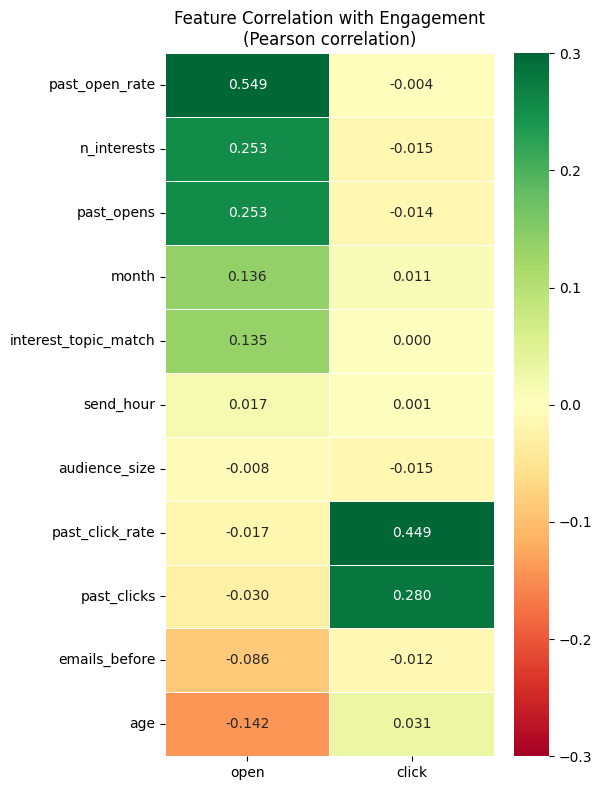

In [681]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    corr_df.sort_values('open', ascending=False),
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.3,
    vmax=0.3,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation with Engagement\n(Pearson correlation)')
plt.tight_layout()
plt.show()

Correlation between features and engagement outcomes (open & click)

Key findings:
  - past_open_rate is the strongest predictor of opens (r=0.549)
   - past_click_rate is the strongest predictor of clicks (r=0.449)
   - Behavioral history dominates; demographic/timing features have weaker effects
   - Open and click predictors differ substantially, suggesting separate models may be warranted

## Dropping unusable columns

In [682]:
df_model = df_master.copy()

In [683]:
#Drop columns with >40% missing except for age and send_hour
cols_to_drop = ['city', 'client_bureau', 'campaign_name', 'birth_date', 'audience_size', 'audience_bucket']
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

In [684]:
#Drop columns with not usable features
cols_to_drop_1= [ 'month_year', 'send_date', 'age', 'send_hour']
df_model = df_model.drop(columns=cols_to_drop_1, errors='ignore')

city                         1063396         92.0

client_bureau                1015257         87.8

campaign_name                1015257         87.8

birth_date                    859141         74.3

- age                           859141         74.3

- send_hour                     578454         50.0

audience_size                 500827         43.3

audience_bucket               500827         43.3

In [685]:
#Impute past_open_rate and past_click_rate with 0 (no history = no opens/clicks)
df_model['past_open_rate'] = df_model['past_open_rate'].fillna(0)
df_model['past_click_rate'] = df_model['past_click_rate'].fillna(0)
df_model['past_opens'] = df_model['past_opens'].fillna(0)
df_model['past_clicks'] = df_model['past_clicks'].fillna(0)

In [686]:
print(df_model.isnull().sum())
print(df_model.shape)

user_id                       0
gender                        0
postcode                 436989
interests                     0
n_interests                   0
open_type                     0
click_type                    0
mailing_id                    0
open                      98760
click                     52062
mailing_info              28850
subject_line              28850
preheader                 34359
day_of_week              339593
month                    339593
year                     339593
main_topic                    0
engagement_group              0
open_segment             145107
past_open_bucket         116723
clicked_before                0
click_segment            145107
open_behaviour                0
interest_topic_match          0
emails_before                 0
past_click_rate               0
past_clicks                   0
past_open_rate                0
exposure_bucket               0
past_opens                    0
mapped_interest_topic    145107
dtype: i

postcode??? aggregate into broader regions

In [687]:
#Drop other unusable columns
extra_drop = [ 'mailing_info', 'subject_line', 'preheader', 'past_open_bucket', 'year','postcode', 'engagement_group', 'clicked_before']  
df_model = df_model.drop(columns=extra_drop, errors='ignore')

In [688]:
#drop day_of_week 
df_model = df_model.drop(columns=['day_of_week'])

#Filling month via distribution sampling
month_dist = df_model['month'].dropna()
df_model['month'] = df_model['month'].fillna(
    pd.Series(
        month_dist.sample(df_model['month'].isna().sum(), 
                         replace=True, 
                         random_state=42).values,
        index=df_model[df_model['month'].isna()].index
    )
)

In [689]:
print(df_model.isnull().sum())
print(df_model.shape)

user_id                       0
gender                        0
interests                     0
n_interests                   0
open_type                     0
click_type                    0
mailing_id                    0
open                      98760
click                     52062
month                         0
main_topic                    0
open_segment             145107
click_segment            145107
open_behaviour                0
interest_topic_match          0
emails_before                 0
past_click_rate               0
past_clicks                   0
past_open_rate                0
exposure_bucket               0
past_opens                    0
mapped_interest_topic    145107
dtype: int64
(1156304, 22)


In [690]:
last_drop = [
    'mapped_interest_topic',  # lists - unusable
    'open_segment',           # redundant with past_open_rate
    'click_segment',          # redundant with past_click_rate + clicked_before
    'exposure_bucket',        # redundant with emails_before
    'open_behaviour',         # redundant with past_open_rate
    'interests',              # raw lists - already encoded
]

df_model = df_model.drop(columns=last_drop, errors='ignore')


In [691]:
print(df_model.shape)
print(df_model.columns.tolist())

(1156304, 16)
['user_id', 'gender', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open', 'click', 'month', 'main_topic', 'interest_topic_match', 'emails_before', 'past_click_rate', 'past_clicks', 'past_open_rate', 'past_opens']


In [692]:
print(df_model['open_type'].value_counts())
print('\n', df_model['click_type'].value_counts())

open_type
id_format        1052169
non_id_format      98760
missing             5375
Name: count, dtype: int64

 click_type
missing          1092065
non_id_format      52062
id_format          12177
Name: count, dtype: int64


In [693]:
df_model = df_model.drop(columns=['open_type', 'click_type'])
print(df_model.shape)
print(df_model.columns.tolist())

(1156304, 14)
['user_id', 'gender', 'n_interests', 'mailing_id', 'open', 'click', 'month', 'main_topic', 'interest_topic_match', 'emails_before', 'past_click_rate', 'past_clicks', 'past_open_rate', 'past_opens']


## Summary before modeling

In [694]:
feature_reliability = pd.DataFrame({
    'feature': [
        'past_open_rate', 'past_click_rate', 'past_opens', 'past_clicks',
        'emails_before', 'interest_topic_match', 'n_interests',
        'month', 'gender', 'main_topic'
    ],
    'missing_pct': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'imputation': [
        '0 (no history = no engagement)',
        '0 (no history = no engagement)',
        '0 (no history = no engagement)',
        '0 (no history = no engagement)',
        '0 (no history = no engagement)',
        'None required',
        'None required',
        'Distribution sampling (preserves seasonal pattern)',
        'None required',
        'None required'
    ],
    'reliability': [
        'High — strongest predictor of opens (r=0.549)',
        'High — strongest predictor of clicks (r=0.449)',
        'High — supports past_open_rate',
        'High — supports past_click_rate',
        'High — captures cumulative exposure history',
        'High — binary flag, directly derived from topic mapping',
        'High — fully observed user profile feature',
        'Medium — imputed for 29.4% of rows via distribution sampling',
        'High — fully observed after cleaning',
        'High — fully observed, 10 categories'
    ]
})

print(feature_reliability.to_string(index=False))

             feature  missing_pct                                         imputation                                                  reliability
      past_open_rate          0.0                     0 (no history = no engagement)                High — strongest predictor of opens (r=0.549)
     past_click_rate          0.0                     0 (no history = no engagement)               High — strongest predictor of clicks (r=0.449)
          past_opens          0.0                     0 (no history = no engagement)                               High — supports past_open_rate
         past_clicks          0.0                     0 (no history = no engagement)                              High — supports past_click_rate
       emails_before          0.0                     0 (no history = no engagement)                  High — captures cumulative exposure history
interest_topic_match          0.0                                      None required      High — binary flag, directly deriv

In [695]:
master_cols = set(df_master.columns.tolist())
model_cols = set(df_model.columns.tolist())

dropped = master_cols - model_cols

print(f"Columns in df_master but NOT in df_model ({len(dropped)} total):")
for col in sorted(dropped):
    print(f"  {col}")

Columns in df_master but NOT in df_model (27 total):
  age
  audience_bucket
  audience_size
  birth_date
  campaign_name
  city
  click_segment
  click_type
  clicked_before
  client_bureau
  day_of_week
  engagement_group
  exposure_bucket
  interests
  mailing_info
  mapped_interest_topic
  month_year
  open_behaviour
  open_segment
  open_type
  past_open_bucket
  postcode
  preheader
  send_date
  send_hour
  subject_line
  year


In [696]:
print("\nExcluded features:")
excluded = {
    # High missingness — unreliable as model inputs
    'city':                  '92.0% missing — unusable',
    'client_bureau':         '87.8% missing — only covers recent campaigns',
    'campaign_name':         '87.8% missing — only covers recent campaigns',
    'birth_date':            '74.3% missing — age derived from this and also excluded',
    'age':                   '74.3% missing — imputing majority of users with median unreliable',
    'send_hour':             '50.0% missing — only 2 send hours observed, insufficient coverage',
    'audience_size':         '43.3% missing — also collinear with main_topic',
    'audience_bucket':       '43.3% missing — derived from audience_size',
    'postcode':              '37.8% missing + high cardinality — encoding not feasible',
    'day_of_week':           '29.4% missing — send-time optimisation handled separately by teammate',

    # Redundant temporal columns
    'send_date':             'Redundant — month extracted and kept separately',
    'month_year':            'Redundant — month extracted and kept separately',
    'year':                  'No meaningful variation across dataset',

    # Text columns — not usable in logistic regression
    'mailing_info':          'Free text — not usable in logistic regression',
    'subject_line':          'Free text — not usable in logistic regression',
    'preheader':             'Free text — not usable in logistic regression',

    # Derived segmentation columns — redundant with source features
    'past_open_bucket':      'Derived from past_open_rate — redundant',
    'open_segment':          'Derived from past_open_rate — redundant',
    'open_behaviour':        'Derived from past_open_rate — redundant',
    'click_segment':         'Derived from past_click_rate — redundant',
    'clicked_before':        'Derived from past_click_rate — redundant',
    'exposure_bucket':       'Derived from emails_before — redundant',
    'engagement_group':      'Derived from past_open_rate + past_click_rate — redundant',

    # Intermediate processing columns
    'open_type':             'Intermediate parsing column — not a feature',
    'click_type':            'Intermediate parsing column — not a feature',

    # List-format columns — captured via derived features
    'interests':             'List format — captured via n_interests',
    'mapped_interest_topic': 'List format — topic alignment captured via interest_topic_match',
}

for feature, reason in excluded.items():
    print(f"  {feature:<25}: {reason}")


Excluded features:
  city                     : 92.0% missing — unusable
  client_bureau            : 87.8% missing — only covers recent campaigns
  campaign_name            : 87.8% missing — only covers recent campaigns
  birth_date               : 74.3% missing — age derived from this and also excluded
  age                      : 74.3% missing — imputing majority of users with median unreliable
  send_hour                : 50.0% missing — only 2 send hours observed, insufficient coverage
  audience_size            : 43.3% missing — also collinear with main_topic
  audience_bucket          : 43.3% missing — derived from audience_size
  postcode                 : 37.8% missing + high cardinality — encoding not feasible
  day_of_week              : 29.4% missing — send-time optimisation handled separately by teammate
  send_date                : Redundant — month extracted and kept separately
  month_year               : Redundant — month extracted and kept separately
  year          

In [697]:
print(df_model[['open', 'click']].isna().sum())
print(f"Total rows: {len(df_model)}")

open     98760
click    52062
dtype: int64
Total rows: 1156304


In [698]:
print(df_model.isna().sum())

user_id                     0
gender                      0
n_interests                 0
mailing_id                  0
open                    98760
click                   52062
month                       0
main_topic                  0
interest_topic_match        0
emails_before               0
past_click_rate             0
past_clicks                 0
past_open_rate              0
past_opens                  0
dtype: int64


In [699]:
print('open' in df_exploded.columns)
print('open' in df2.columns)

True
False


## Prep

In [700]:
df_model.dtypes

user_id                     str
gender                      str
n_interests               int64
mailing_id               object
open                    float64
click                   float64
month                   float64
main_topic                  str
interest_topic_match      int64
emails_before             int64
past_click_rate         float64
past_clicks             float64
past_open_rate          float64
past_opens              float64
dtype: object

In [701]:
#encoding categorical variables using one-hot encoding
df_model = pd.get_dummies(df_model, 
                           columns=['gender', 'main_topic'],
                           drop_first=True)

print(df_model.shape)
print(df_model.columns.tolist())

(1156304, 25)
['user_id', 'n_interests', 'mailing_id', 'open', 'click', 'month', 'interest_topic_match', 'emails_before', 'past_click_rate', 'past_clicks', 'past_open_rate', 'past_opens', 'gender_male', 'gender_other', 'main_topic_Business', 'main_topic_Charity & Social Impact', 'main_topic_Energy & Sustainability', 'main_topic_Finance & Investment', 'main_topic_Food & Beverages', 'main_topic_Health & Wellbeing', 'main_topic_Lottery & Games', 'main_topic_Media & Publishing', 'main_topic_Missing', 'main_topic_Retail & Promotion', 'main_topic_Telecom & Technology']


In [702]:
df_model = df_model.dropna(subset=['open', 'click'])
print(f"Rows remaining: {len(df_model)}")

Rows remaining: 1011197


In [703]:
#drop ID columns
df_model = df_model.drop(columns=['user_id', 'mailing_id'])

In [704]:
#features and targets
X = df_model.drop(columns=['open', 'click'])
y_open = df_model['open']
y_click = df_model['click']

print(f"Features: {X.shape}")
print(f"\nOpen target distribution:")
print(y_open.value_counts(normalize=True).round(3))
print(f"\nClick target distribution:")
print(y_click.value_counts(normalize=True).round(3))

Features: (1011197, 21)

Open target distribution:
open
1.0    0.543
0.0    0.457
Name: proportion, dtype: float64

Click target distribution:
click
0.0    0.999
1.0    0.001
Name: proportion, dtype: float64


Open model: no special handling needed.

Click model: handle the imbalance, otherwise the model will just predict 0 for everyone

In [705]:
print(y_open.dtype)
print(y_open.unique())
print(y_click.unique())

float64
[0. 1.]
[0. 1.]


In [706]:
from sklearn.linear_model import LogisticRegression

#open model: no class weight needed
lr_open = LogisticRegression(penalty='l2', C=1.0, class_weight=None, random_state=42, max_iter=1000)

#click model: balanced class weight
lr_click = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', random_state=42, max_iter=1000)

In [707]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_open_train, y_open_test, y_click_train, y_click_test = train_test_split(
    X, y_open, y_click,
    test_size=0.2,
    random_state=42,
    stratify=y_open)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (808957, 21)
Test set: (202240, 21)


In [708]:
print(f"\nOpen train distribution:\n{y_open_train.value_counts(normalize=True).round(3)}")
print(f"\nOpen test distribution:\n{y_open_test.value_counts(normalize=True).round(3)}")
print(f"\nClick train distribution:\n{y_click_train.value_counts(normalize=True).round(3)}")
print(f"\nClick test distribution:\n{y_click_test.value_counts(normalize=True).round(3)}")


Open train distribution:
open
1.0    0.543
0.0    0.457
Name: proportion, dtype: float64

Open test distribution:
open
1.0    0.543
0.0    0.457
Name: proportion, dtype: float64

Click train distribution:
click
0.0    0.999
1.0    0.001
Name: proportion, dtype: float64

Click test distribution:
click
0.0    0.999
1.0    0.001
Name: proportion, dtype: float64


In [709]:
#Scale features  
scaler = StandardScaler()

#fit on training set and then transform both training and test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [710]:
#logistic regression models
lr_open.fit(X_train_scaled, y_open_train)

c:\Users\giada\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [711]:
lr_click.fit(X_train_scaled, y_click_train)

c:\Users\giada\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [712]:
from sklearn.metrics import classification_report, roc_auc_score

#open model evaluation
y_open_pred = lr_open.predict(X_test_scaled)
y_open_prob = lr_open.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_open_test, y_open_pred))
print(f"AUC-ROC: {roc_auc_score(y_open_test, y_open_prob):.4f}")

              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72     92470
         1.0       0.76      0.79      0.77    109770

    accuracy                           0.75    202240
   macro avg       0.75      0.74      0.75    202240
weighted avg       0.75      0.75      0.75    202240

AUC-ROC: 0.8259


Open model

AUC-ROC: 0.8259 (strong performance, the model genuinely discriminates between openers and non-openers)

Accuracy: 75%

Precision/Recall balanced  (0.74/0.70 for non-openers, 0.76/0.79 for openers)

In [713]:
#click model evaluation
y_click_pred = lr_click.predict(X_test_scaled)
y_click_prob = lr_click.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_click_test, y_click_pred))
print(f"AUC-ROC: {roc_auc_score(y_click_test, y_click_prob):.4f}")

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98    202023
         1.0       0.03      0.83      0.05       217

    accuracy                           0.97    202240
   macro avg       0.51      0.90      0.52    202240
weighted avg       1.00      0.97      0.98    202240

AUC-ROC: 0.9459


Click model

AUC-ROC: 0.9463 (careful interpretation)

Accuracy: 97% mostly from predicting "no click" correctly

Class 1 (clicks) precision: 0.03 (when it predicts a click, it's wrong 97% of the time)

Class 1 (clicks) recall: 0.83 (it catches 83% of actual clicks though)

The class_weight='balanced' is prioritizing recall over precision for the rare click class



Note: The click model trades precision for recall, it flags many false positives but catches most real clicks, which is actually the right tradeoff for a marketing use case (better to send to someone who won't click than to miss someone who would).

In [716]:
mae_open = mean_absolute_error(y_open_test, y_open_prob)
mae_click = mean_absolute_error(y_click_test, y_click_prob)

print(f"Open model MAE: {mae_open:.4f}")
print(f"Click model MAE: {mae_click:.4f}")

Open model MAE: 0.3387
Click model MAE: 0.1292


In [717]:
# Get feature names from X
feature_names = X.columns.tolist()

# Get coefficients from the open model
coefficients = lr_open.coef_[0]

# Create a dataframe sorted by absolute importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print(importance_df)

                               feature  coefficient  abs_coefficient
6                       past_open_rate     1.221122         1.221122
2                 interest_topic_match     0.499860         0.499860
3                        emails_before    -0.444236         0.444236
0                          n_interests     0.269160         0.269160
15       main_topic_Health & Wellbeing     0.182783         0.182783
14         main_topic_Food & Beverages     0.180214         0.180214
1                                month     0.144087         0.144087
18                  main_topic_Missing     0.120758         0.120758
11  main_topic_Charity & Social Impact    -0.111870         0.111870
12  main_topic_Energy & Sustainability    -0.090365         0.090365
13     main_topic_Finance & Investment    -0.066906         0.066906
5                          past_clicks    -0.026963         0.026963
10                 main_topic_Business     0.025213         0.025213
19       main_topic_Retail & Promo

In [718]:
# Get feature names from X
feature_names = X.columns.tolist()

# Get coefficients from the click model
coefficients = lr_click.coef_[0]

# Create a dataframe sorted by absolute importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print(importance_df)

                               feature  coefficient  abs_coefficient
14         main_topic_Food & Beverages    -3.537672         3.537672
20     main_topic_Telecom & Technology    -1.600964         1.600964
5                          past_clicks     1.342963         1.342963
2                 interest_topic_match     0.946165         0.946165
17       main_topic_Media & Publishing    -0.908811         0.908811
19       main_topic_Retail & Promotion    -0.636265         0.636265
16          main_topic_Lottery & Games    -0.623982         0.623982
3                        emails_before    -0.600845         0.600845
6                       past_open_rate    -0.483324         0.483324
8                          gender_male     0.425673         0.425673
15       main_topic_Health & Wellbeing     0.386040         0.386040
4                      past_click_rate     0.290077         0.290077
0                          n_interests    -0.279538         0.279538
1                                m